# 📊 Análise de Tendências - Últimos 3 Meses

Análise detalhada dos padrões de sorteio dos últimos 3 meses da Lotofácil.

**Conteúdo:**
1. Timeline cronológica de cada número
2. Frequência de sorteios
3. Recência dos números
4. Gap médio entre sorteios
5. Tendência de crescimento/decrescimento
6. Score combinado de expectativa

## 1️⃣ Importar Bibliotecas e Carregar Dados

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("tab20")
plt.rcParams['figure.figsize'] = (16, 8)
pd.set_option('display.max_columns', None)

# Carregar dados
df = pd.read_csv('data/lotofacil_sorteios.csv')
df['Data Sorteio'] = pd.to_datetime(df['Data Sorteio'], format='%d/%m/%Y')

# Filtrar últimos 3 meses
data_limite = datetime.now() - timedelta(days=90)
df_3meses = df[df['Data Sorteio'] >= data_limite].copy()

print(f"✅ Dados carregados!")
print(f"📅 Período de análise: {df_3meses['Data Sorteio'].min().strftime('%d/%m/%Y')} até {df_3meses['Data Sorteio'].max().strftime('%d/%m/%Y')}")
print(f"📊 Total de sorteios nos últimos 3 meses: {len(df_3meses)}")
print(f"🎯 Números analisados: 1 a 25")

✅ Dados carregados!
📅 Período de análise: 10/10/2025 até 06/01/2026
📊 Total de sorteios nos últimos 3 meses: 72
🎯 Números analisados: 1 a 25


## 2️⃣ Timeline Cronológica de Sorteios

Visualização temporal de quando cada número foi sorteado nos últimos 3 meses.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\2477063066.py:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


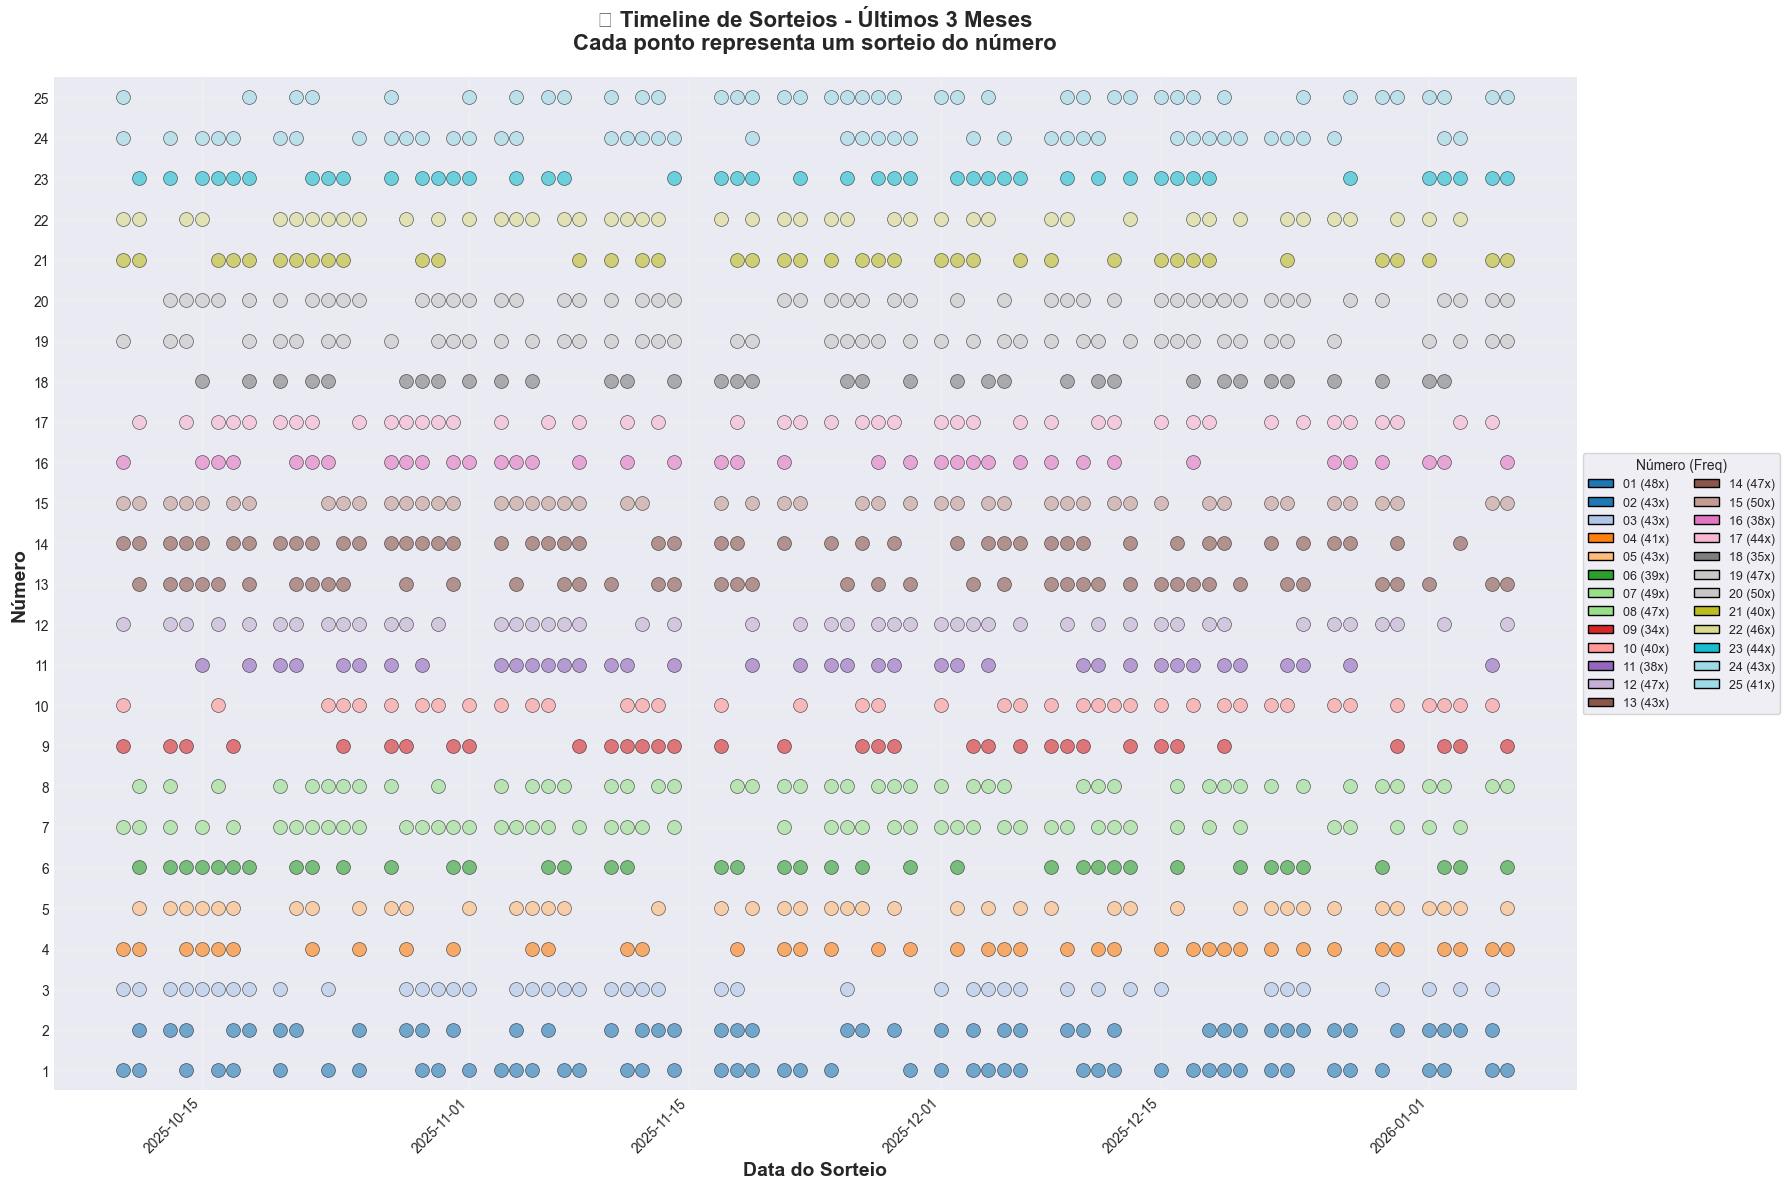


📊 ESTATÍSTICAS DA TIMELINE:

🔝 Top 5 mais sorteados:
   15: 50 vezes
   20: 50 vezes
   07: 49 vezes
   01: 48 vezes
   08: 47 vezes

🔻 Top 5 menos sorteados:
   09: 34 vezes
   18: 35 vezes
   11: 38 vezes
   16: 38 vezes
   06: 39 vezes



In [7]:
# Preparar dados para timeline
timeline_data = []

for idx, row in df_3meses.iterrows():
    data = row['Data Sorteio']
    concurso = row['Concurso']
    numeros = [row[f'Bola{i}'] for i in range(1, 16)]
    
    for numero in numeros:
        timeline_data.append({
            'Numero': numero,
            'Data': data,
            'Concurso': concurso
        })

df_timeline = pd.DataFrame(timeline_data)

# Criar gráfico timeline
fig, ax = plt.subplots(figsize=(18, 12))

# Cores diferentes para cada número
cores = plt.cm.tab20(np.linspace(0, 1, 25))

for numero in range(1, 26):
    dados_numero = df_timeline[df_timeline['Numero'] == numero]
    
    if len(dados_numero) > 0:
        # Plotar pontos para cada sorteio
        ax.scatter(dados_numero['Data'], [numero] * len(dados_numero), 
                  s=100, alpha=0.6, color=cores[numero-1], 
                  edgecolors='black', linewidth=0.5, zorder=2)
        
        # Linha de base para cada número
        ax.axhline(y=numero, color='gray', alpha=0.2, linewidth=0.5, zorder=1)

# Configurações do gráfico
ax.set_xlabel('Data do Sorteio', fontsize=14, fontweight='bold')
ax.set_ylabel('Número', fontsize=14, fontweight='bold')
ax.set_title('📅 Timeline de Sorteios - Últimos 3 Meses\nCada ponto representa um sorteio do número', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_yticks(range(1, 26))
ax.set_ylim(0.5, 25.5)
ax.grid(True, alpha=0.3, axis='x')

# Rotacionar labels de data
plt.xticks(rotation=45, ha='right')

# Adicionar legenda com contagem
from matplotlib.patches import Patch
legend_elements = []
for numero in range(1, 26):
    count = len(df_timeline[df_timeline['Numero'] == numero])
    legend_elements.append(
        Patch(facecolor=cores[numero-1], edgecolor='black', 
              label=f'{numero:02d} ({count}x)')
    )

# Dividir legenda em 2 colunas
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),
          ncol=2, frameon=True, fontsize=9, title='Número (Freq)')

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("\n📊 ESTATÍSTICAS DA TIMELINE:")
print("="*70)
freq_por_numero = df_timeline['Numero'].value_counts().sort_index()
print(f"\n🔝 Top 5 mais sorteados:")
for num, freq in freq_por_numero.nlargest(5).items():
    print(f"   {num:02d}: {freq} vezes")

print(f"\n🔻 Top 5 menos sorteados:")
for num, freq in freq_por_numero.nsmallest(5).items():
    print(f"   {num:02d}: {freq} vezes")

print("\n" + "="*70)

## 3️⃣ Análise 1: Frequência de Sorteios

Quantas vezes cada número foi sorteado nos últimos 3 meses.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\773924472.py:44: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


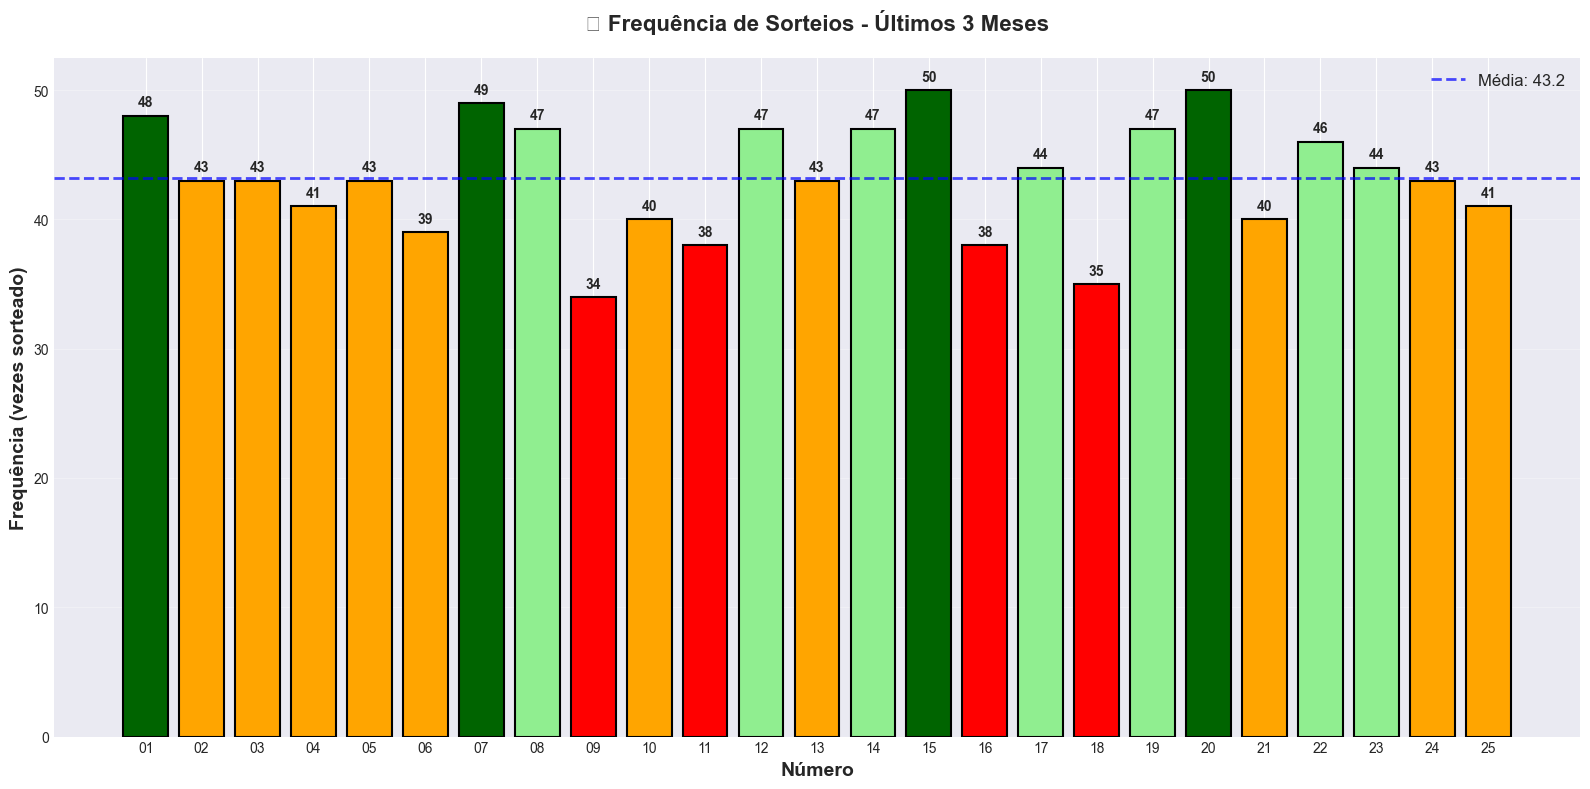


📊 ESTATÍSTICAS DE FREQUÊNCIA:
📈 Média: 43.20 sorteios
📏 Desvio Padrão: 4.43
🔝 Máximo: 50 sorteios (número 15)
🔻 Mínimo: 34 sorteios (número 9)

🟢 Acima da média (43.2):
   15(50), 20(50), 07(49), 01(48), 08(47), 14(47), 12(47), 19(47), 22(46), 17(44), 23(44)

🔴 Abaixo da média (43.2):
   09(34), 18(35), 16(38), 11(38), 06(39), 21(40), 10(40), 04(41), 25(41), 03(43), 05(43), 02(43), 13(43), 24(43)


In [8]:
# Calcular frequência de cada número
frequencia = df_timeline['Numero'].value_counts().sort_index()
frequencia_df = pd.DataFrame({
    'Numero': range(1, 26),
    'Frequencia': [frequencia.get(i, 0) for i in range(1, 26)]
})

# Calcular média e desvio padrão
media_freq = frequencia_df['Frequencia'].mean()
std_freq = frequencia_df['Frequencia'].std()

# Criar gráfico de barras
fig, ax = plt.subplots(figsize=(16, 8))

# Cores baseadas na frequência (verde = alta, vermelho = baixa)
colors = ['red' if f < media_freq - std_freq 
          else 'orange' if f < media_freq 
          else 'lightgreen' if f < media_freq + std_freq 
          else 'darkgreen' 
          for f in frequencia_df['Frequencia']]

bars = ax.bar(frequencia_df['Numero'], frequencia_df['Frequencia'], 
              color=colors, edgecolor='black', linewidth=1.5)

# Linha de média
ax.axhline(y=media_freq, color='blue', linestyle='--', linewidth=2, 
           label=f'Média: {media_freq:.1f}', alpha=0.7)

# Adicionar valores nas barras
for i, (num, freq) in enumerate(zip(frequencia_df['Numero'], frequencia_df['Frequencia'])):
    ax.text(num, freq + 0.5, str(freq), ha='center', va='bottom', 
            fontweight='bold', fontsize=10)

# Configurações
ax.set_xlabel('Número', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequência (vezes sorteado)', fontsize=14, fontweight='bold')
ax.set_title('📊 Frequência de Sorteios - Últimos 3 Meses', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 26))
ax.set_xticklabels([f'{i:02d}' for i in range(1, 26)])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
print("\n📊 ESTATÍSTICAS DE FREQUÊNCIA:")
print("="*70)
print(f"📈 Média: {media_freq:.2f} sorteios")
print(f"📏 Desvio Padrão: {std_freq:.2f}")
print(f"🔝 Máximo: {frequencia_df['Frequencia'].max()} sorteios (número {frequencia_df.loc[frequencia_df['Frequencia'].idxmax(), 'Numero']})")
print(f"🔻 Mínimo: {frequencia_df['Frequencia'].min()} sorteios (número {frequencia_df.loc[frequencia_df['Frequencia'].idxmin(), 'Numero']})")

print(f"\n🟢 Acima da média ({media_freq:.1f}):")
acima = frequencia_df[frequencia_df['Frequencia'] > media_freq].sort_values('Frequencia', ascending=False)
print(f"   {', '.join([f'{row.Numero:02d}({row.Frequencia})' for _, row in acima.iterrows()])}")

print(f"\n🔴 Abaixo da média ({media_freq:.1f}):")
abaixo = frequencia_df[frequencia_df['Frequencia'] < media_freq].sort_values('Frequencia')
print(f"   {', '.join([f'{row.Numero:02d}({row.Frequencia})' for _, row in abaixo.iterrows()])}")
print("="*70)

## 4️⃣ Análise 2: Recência (Dias desde último sorteio)

Há quantos dias cada número não é sorteado.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\1318314239.py:46: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\1318314239.py:46: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


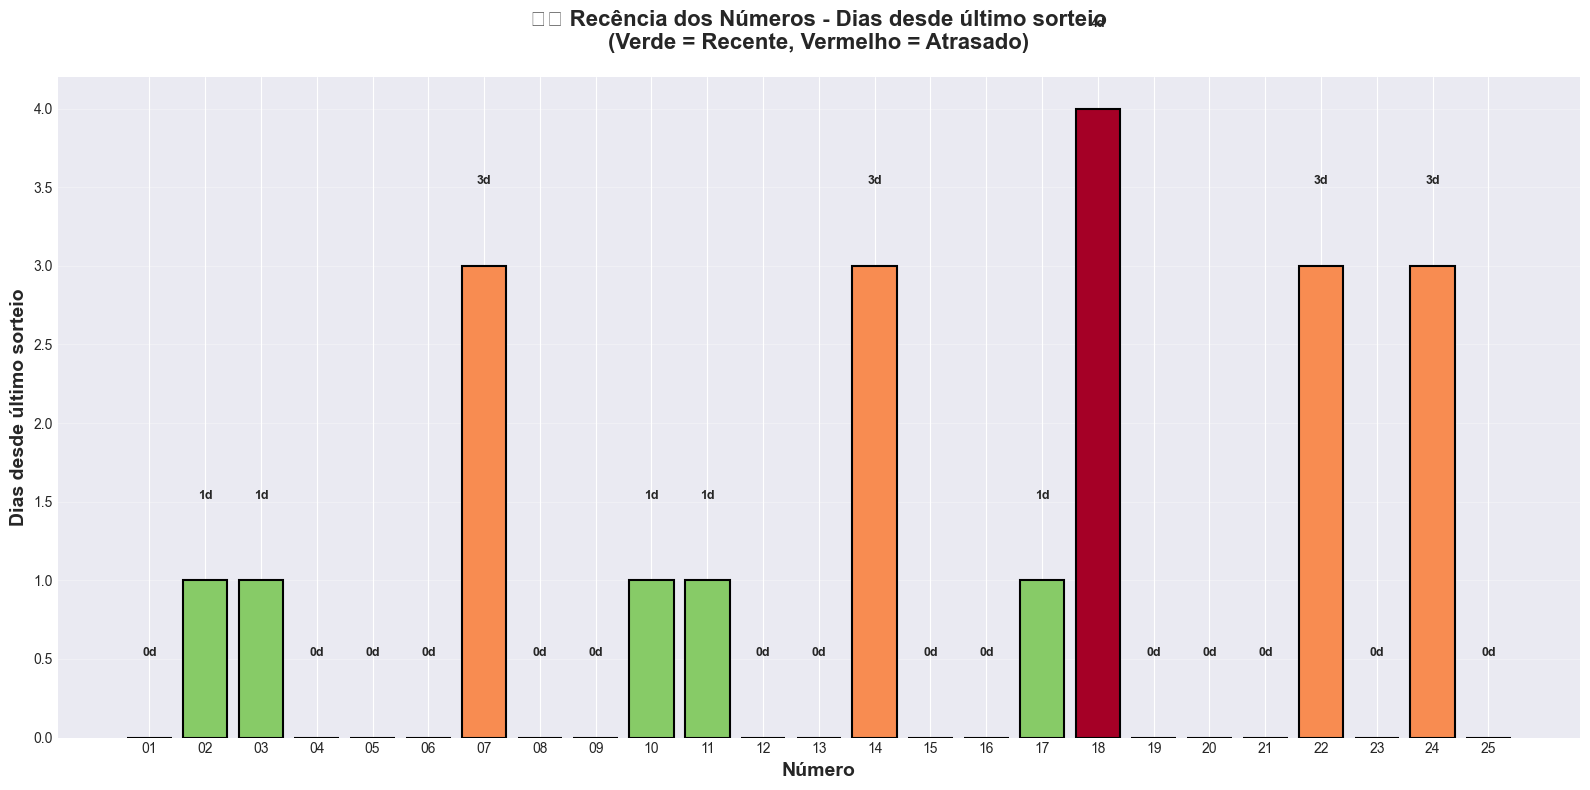


⏱️ ESTATÍSTICAS DE RECÊNCIA:
📈 Média: 0.8 dias
🔝 Mais atrasado: 4 dias (número 18)
🟢 Mais recente: 0 dias (número 01)

🔴 Top 5 mais atrasados (podem estar 'devendo'):
   18: 4 dias (último: 02/01/2026)
   07: 3 dias (último: 03/01/2026)
   14: 3 dias (último: 03/01/2026)
   22: 3 dias (último: 03/01/2026)
   24: 3 dias (último: 03/01/2026)

🟢 Top 5 mais recentes:
   01: 0 dias (último: 06/01/2026)
   04: 0 dias (último: 06/01/2026)
   05: 0 dias (último: 06/01/2026)
   06: 0 dias (último: 06/01/2026)
   08: 0 dias (último: 06/01/2026)


In [9]:
# Calcular dias desde último sorteio para cada número
data_atual = df_3meses['Data Sorteio'].max()
recencia_data = []

for numero in range(1, 26):
    dados_num = df_timeline[df_timeline['Numero'] == numero]
    
    if len(dados_num) > 0:
        ultimo_sorteio = dados_num['Data'].max()
        dias_desde = (data_atual - ultimo_sorteio).days
    else:
        dias_desde = 90  # Não foi sorteado nos últimos 3 meses
    
    recencia_data.append({
        'Numero': numero,
        'Dias_Desde_Ultimo': dias_desde,
        'Ultimo_Sorteio': ultimo_sorteio if len(dados_num) > 0 else None
    })

recencia_df = pd.DataFrame(recencia_data)

# Criar gráfico
fig, ax = plt.subplots(figsize=(16, 8))

# Cores: vermelho = muito tempo, verde = recente
max_dias = recencia_df['Dias_Desde_Ultimo'].max()
colors = [plt.cm.RdYlGn_r(dias / max_dias) for dias in recencia_df['Dias_Desde_Ultimo']]

bars = ax.bar(recencia_df['Numero'], recencia_df['Dias_Desde_Ultimo'], 
              color=colors, edgecolor='black', linewidth=1.5)

# Adicionar valores
for num, dias in zip(recencia_df['Numero'], recencia_df['Dias_Desde_Ultimo']):
    ax.text(num, dias + 0.5, f'{int(dias)}d', ha='center', va='bottom', 
            fontweight='bold', fontsize=9)

# Configurações
ax.set_xlabel('Número', fontsize=14, fontweight='bold')
ax.set_ylabel('Dias desde último sorteio', fontsize=14, fontweight='bold')
ax.set_title('⏱️ Recência dos Números - Dias desde último sorteio\n(Verde = Recente, Vermelho = Atrasado)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 26))
ax.set_xticklabels([f'{i:02d}' for i in range(1, 26)])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
print("\n⏱️ ESTATÍSTICAS DE RECÊNCIA:")
print("="*70)
print(f"📈 Média: {recencia_df['Dias_Desde_Ultimo'].mean():.1f} dias")
print(f"🔝 Mais atrasado: {int(recencia_df['Dias_Desde_Ultimo'].max())} dias (número {recencia_df.loc[recencia_df['Dias_Desde_Ultimo'].idxmax(), 'Numero']:02d})")
print(f"🟢 Mais recente: {int(recencia_df['Dias_Desde_Ultimo'].min())} dias (número {recencia_df.loc[recencia_df['Dias_Desde_Ultimo'].idxmin(), 'Numero']:02d})")

print(f"\n🔴 Top 5 mais atrasados (podem estar 'devendo'):")
atrasados = recencia_df.nlargest(5, 'Dias_Desde_Ultimo')
for _, row in atrasados.iterrows():
    data_str = row['Ultimo_Sorteio'].strftime('%d/%m/%Y') if row['Ultimo_Sorteio'] else 'N/A'
    print(f"   {row['Numero']:02d}: {int(row['Dias_Desde_Ultimo'])} dias (último: {data_str})")

print(f"\n🟢 Top 5 mais recentes:")
recentes = recencia_df.nsmallest(5, 'Dias_Desde_Ultimo')
for _, row in recentes.iterrows():
    data_str = row['Ultimo_Sorteio'].strftime('%d/%m/%Y') if row['Ultimo_Sorteio'] else 'N/A'
    print(f"   {row['Numero']:02d}: {int(row['Dias_Desde_Ultimo'])} dias (último: {data_str})")
print("="*70)

## 5️⃣ Análise 3: Gap Médio entre Sorteios

Intervalo médio (em dias) entre aparições de cada número.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\1279105185.py:60: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


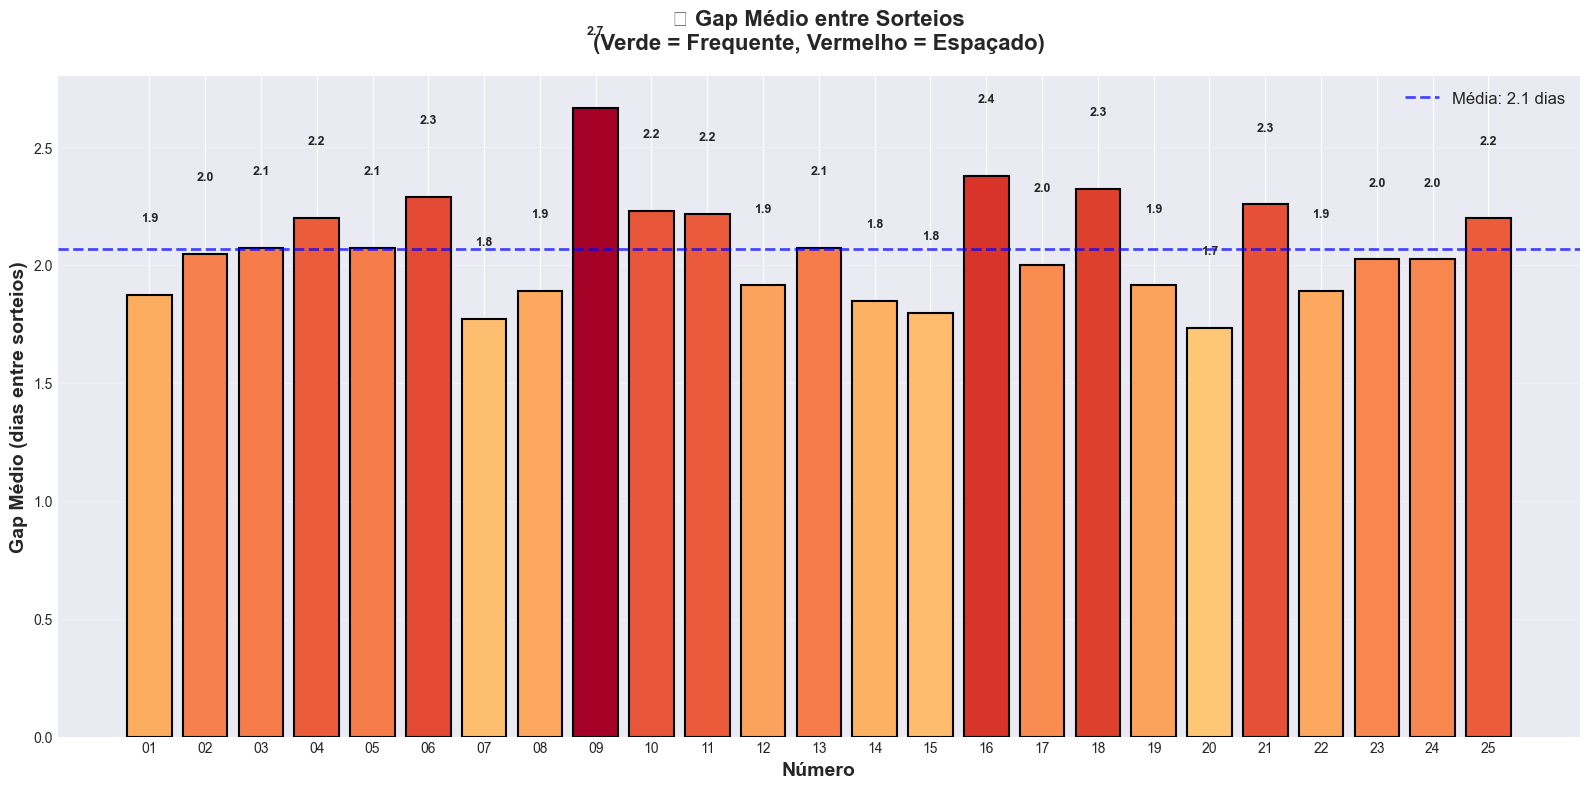


📏 ESTATÍSTICAS DE GAP MÉDIO:
📈 Gap médio geral: 2.07 dias
📏 Desvio padrão: 0.22 dias

🟢 Top 5 mais frequentes (menor gap):
   20: gap de 1.7 dias (sorteado 50x)
   07: gap de 1.8 dias (sorteado 49x)
   15: gap de 1.8 dias (sorteado 50x)
   14: gap de 1.8 dias (sorteado 47x)
   01: gap de 1.9 dias (sorteado 48x)

🔴 Top 5 mais espaçados (maior gap):
   09: gap de 2.7 dias (sorteado 34x)
   16: gap de 2.4 dias (sorteado 38x)
   18: gap de 2.3 dias (sorteado 35x)
   06: gap de 2.3 dias (sorteado 39x)
   21: gap de 2.3 dias (sorteado 40x)

💡 INTERPRETAÇÃO:
   • Gap baixo = número sai com frequência regular
   • Gap alto = número fica muito tempo sem sair


In [11]:
# Calcular gap médio entre sorteios
gap_data = []

for numero in range(1, 26):
    dados_num = df_timeline[df_timeline['Numero'] == numero].sort_values('Data')
    
    if len(dados_num) > 1:
        # Calcular diferenças entre datas consecutivas
        datas = dados_num['Data'].values
        gaps = [(datas[i+1] - datas[i]).astype('timedelta64[D]').astype(int) 
                for i in range(len(datas)-1)]
        gap_medio = np.mean(gaps) if gaps else 0
        gap_min = np.min(gaps) if gaps else 0
        gap_max = np.max(gaps) if gaps else 0
    else:
        gap_medio = 90  # Muito espaçado
        gap_min = 0
        gap_max = 90
    
    gap_data.append({
        'Numero': numero,
        'Gap_Medio': gap_medio,
        'Gap_Min': gap_min,
        'Gap_Max': gap_max,
        'Frequencia': len(dados_num)
    })

gap_df = pd.DataFrame(gap_data)

# Criar gráfico de barras com erro
fig, ax = plt.subplots(figsize=(16, 8))

# Cores baseadas no gap (verde = frequente/menor gap, vermelho = espaçado/maior gap)
max_gap = gap_df['Gap_Medio'].max()
colors = [plt.cm.RdYlGn_r(gap / max_gap) for gap in gap_df['Gap_Medio']]

bars = ax.bar(gap_df['Numero'], gap_df['Gap_Medio'], 
              color=colors, edgecolor='black', linewidth=1.5)

# Adicionar valores
for num, gap in zip(gap_df['Numero'], gap_df['Gap_Medio']):
    ax.text(num, gap + 0.3, f'{gap:.1f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=9)

# Linha de média
media_gap = gap_df['Gap_Medio'].mean()
ax.axhline(y=media_gap, color='blue', linestyle='--', linewidth=2, 
           label=f'Média: {media_gap:.1f} dias', alpha=0.7)

# Configurações
ax.set_xlabel('Número', fontsize=14, fontweight='bold')
ax.set_ylabel('Gap Médio (dias entre sorteios)', fontsize=14, fontweight='bold')
ax.set_title('📏 Gap Médio entre Sorteios\n(Verde = Frequente, Vermelho = Espaçado)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 26))
ax.set_xticklabels([f'{i:02d}' for i in range(1, 26)])
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
print("\n📏 ESTATÍSTICAS DE GAP MÉDIO:")
print("="*70)
print(f"📈 Gap médio geral: {gap_df['Gap_Medio'].mean():.2f} dias")
print(f"📏 Desvio padrão: {gap_df['Gap_Medio'].std():.2f} dias")

print(f"\n🟢 Top 5 mais frequentes (menor gap):")
frequentes = gap_df.nsmallest(5, 'Gap_Medio')
for _, row in frequentes.iterrows():
    print(f"   {int(row['Numero']):02d}: gap de {row['Gap_Medio']:.1f} dias (sorteado {int(row['Frequencia'])}x)")

print(f"\n🔴 Top 5 mais espaçados (maior gap):")
espacados = gap_df.nlargest(5, 'Gap_Medio')
for _, row in espacados.iterrows():
    print(f"   {int(row['Numero']):02d}: gap de {row['Gap_Medio']:.1f} dias (sorteado {int(row['Frequencia'])}x)")

print(f"\n💡 INTERPRETAÇÃO:")
print(f"   • Gap baixo = número sai com frequência regular")
print(f"   • Gap alto = número fica muito tempo sem sair")
print("="*70)

## 6️⃣ Análise 4: Tendência de Crescimento/Decrescimento

Análise se a frequência está aumentando ou diminuindo nos últimos 3 meses.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3269403560.py:70: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


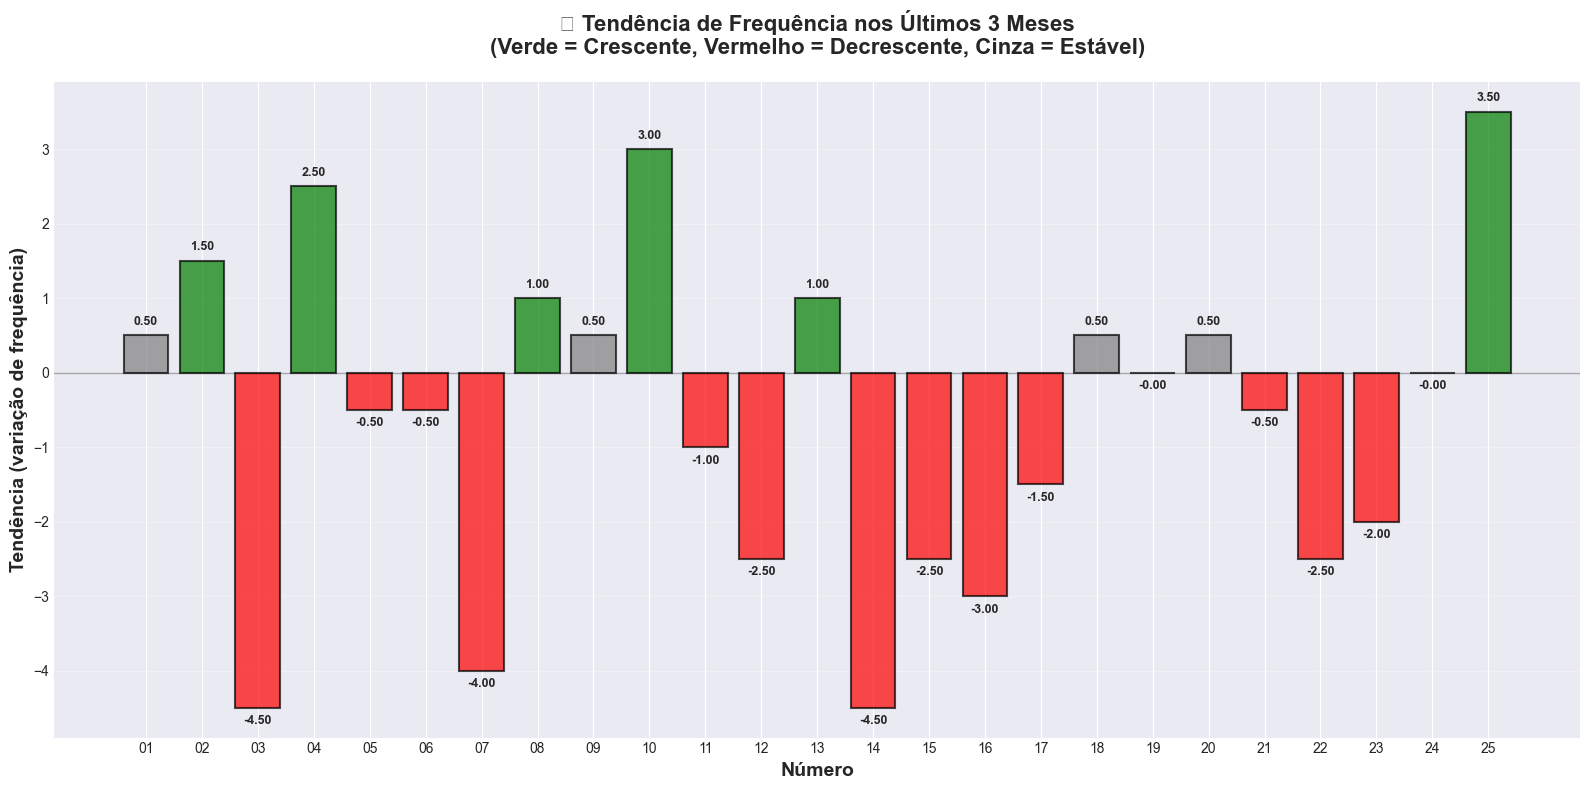

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3269403560.py:96: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


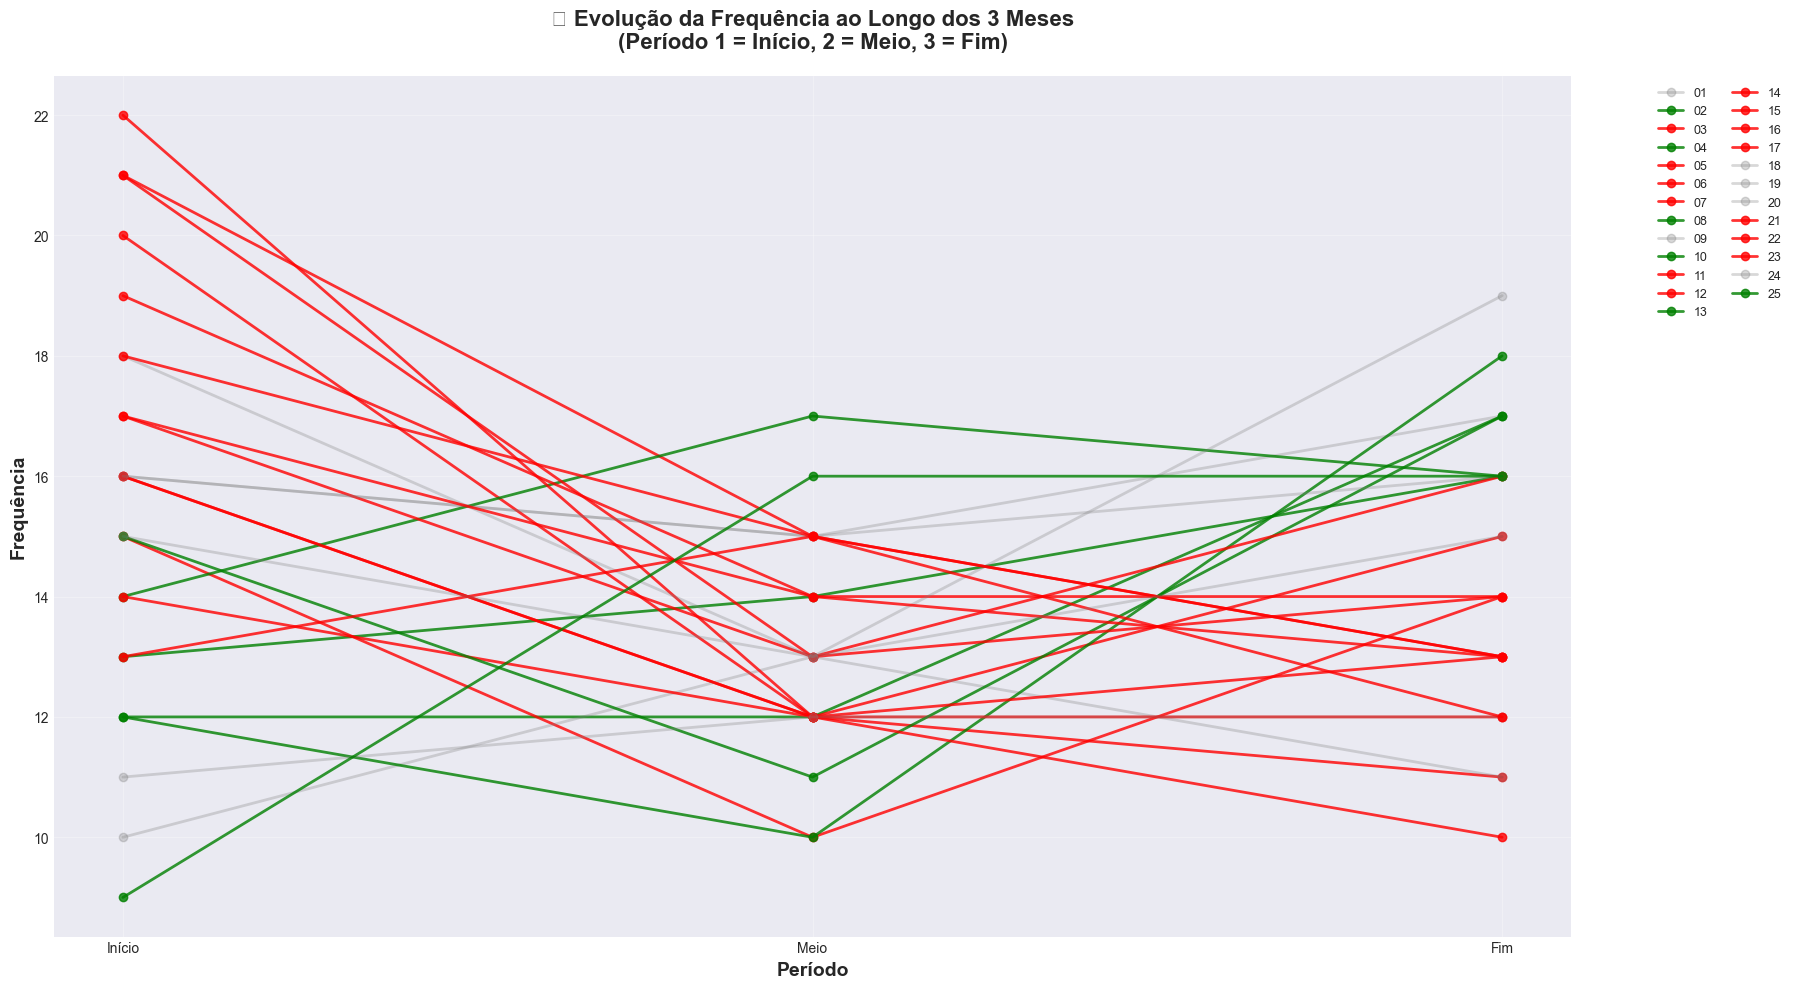


📈 ESTATÍSTICAS DE TENDÊNCIA:
🟢 Números em CRESCIMENTO (tendência > 0.5):
   25: +3.50 (P1:9 → P2:16 → P3:16)
   10: +3.00 (P1:12 → P2:10 → P3:18)
   04: +2.50 (P1:12 → P2:12 → P3:17)
   02: +1.50 (P1:13 → P2:14 → P3:16)
   13: +1.00 (P1:15 → P2:11 → P3:17)
   08: +1.00 (P1:14 → P2:17 → P3:16)

🔴 Números em DECRESCIMENTO (tendência < -0.5):
   14: -4.50 (P1:22 → P2:12 → P3:13)
   03: -4.50 (P1:20 → P2:12 → P3:11)
   07: -4.00 (P1:21 → P2:15 → P3:13)
   16: -3.00 (P1:16 → P2:12 → P3:10)
   15: -2.50 (P1:21 → P2:13 → P3:16)
   22: -2.50 (P1:18 → P2:15 → P3:13)
   12: -2.50 (P1:19 → P2:14 → P3:14)
   23: -2.00 (P1:17 → P2:14 → P3:13)
   17: -1.50 (P1:17 → P2:13 → P3:14)
   11: -1.00 (P1:14 → P2:12 → P3:12)
   06: -0.50 (P1:15 → P2:10 → P3:14)
   21: -0.50 (P1:13 → P2:15 → P3:12)
   05: -0.50 (P1:16 → P2:12 → P3:15)

⚪ Números ESTÁVEIS (-0.5 ≤ tendência ≤ 0.5):
   01, 09, 18, 19, 20, 24


In [12]:
# Dividir o período em 3 partes (início, meio, fim)
periodo_total = (df_3meses['Data Sorteio'].max() - df_3meses['Data Sorteio'].min()).days
periodo_1_fim = df_3meses['Data Sorteio'].min() + timedelta(days=periodo_total//3)
periodo_2_fim = df_3meses['Data Sorteio'].min() + timedelta(days=2*periodo_total//3)

df_periodo1 = df_3meses[df_3meses['Data Sorteio'] <= periodo_1_fim]
df_periodo2 = df_3meses[(df_3meses['Data Sorteio'] > periodo_1_fim) & 
                         (df_3meses['Data Sorteio'] <= periodo_2_fim)]
df_periodo3 = df_3meses[df_3meses['Data Sorteio'] > periodo_2_fim]

# Calcular frequência em cada período
tendencia_data = []

for numero in range(1, 26):
    # Contar em cada período
    freq_p1 = sum([numero in [df_periodo1.iloc[i][f'Bola{j}'] for j in range(1, 16)] 
                   for i in range(len(df_periodo1))])
    freq_p2 = sum([numero in [df_periodo2.iloc[i][f'Bola{j}'] for j in range(1, 16)] 
                   for i in range(len(df_periodo2))])
    freq_p3 = sum([numero in [df_periodo3.iloc[i][f'Bola{j}'] for j in range(1, 16)] 
                   for i in range(len(df_periodo3))])
    
    # Calcular tendência (regressão linear simples)
    x = np.array([1, 2, 3])
    y = np.array([freq_p1, freq_p2, freq_p3])
    
    # Coeficiente angular (slope)
    slope = np.polyfit(x, y, 1)[0]
    
    tendencia_data.append({
        'Numero': numero,
        'Periodo_1': freq_p1,
        'Periodo_2': freq_p2,
        'Periodo_3': freq_p3,
        'Tendencia': slope,
        'Status': 'Crescente' if slope > 0.5 else 'Decrescente' if slope < -0.5 else 'Estável'
    })

tendencia_df = pd.DataFrame(tendencia_data)

# Criar gráfico de tendência
fig, ax = plt.subplots(figsize=(16, 8))

# Cores baseadas na tendência
colors = ['green' if t > 0.5 else 'red' if t < -0.5 else 'gray' 
          for t in tendencia_df['Tendencia']]

bars = ax.bar(tendencia_df['Numero'], tendencia_df['Tendencia'], 
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.7)

# Linha zero
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

# Adicionar valores
for num, tend in zip(tendencia_df['Numero'], tendencia_df['Tendencia']):
    y_pos = tend + (0.1 if tend > 0 else -0.1)
    ax.text(num, y_pos, f'{tend:.2f}', ha='center', 
            va='bottom' if tend > 0 else 'top', 
            fontweight='bold', fontsize=9)

# Configurações
ax.set_xlabel('Número', fontsize=14, fontweight='bold')
ax.set_ylabel('Tendência (variação de frequência)', fontsize=14, fontweight='bold')
ax.set_title('📈 Tendência de Frequência nos Últimos 3 Meses\n(Verde = Crescente, Vermelho = Decrescente, Cinza = Estável)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 26))
ax.set_xticklabels([f'{i:02d}' for i in range(1, 26)])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de linhas para visualizar evolução
fig, ax = plt.subplots(figsize=(18, 10))

for _, row in tendencia_df.iterrows():
    num = row['Numero']
    periodos = [1, 2, 3]
    frequencias = [row['Periodo_1'], row['Periodo_2'], row['Periodo_3']]
    
    color = 'green' if row['Tendencia'] > 0.5 else 'red' if row['Tendencia'] < -0.5 else 'gray'
    alpha = 0.8 if abs(row['Tendencia']) > 0.5 else 0.3
    
    ax.plot(periodos, frequencias, marker='o', label=f'{num:02d}', 
            color=color, alpha=alpha, linewidth=2)

ax.set_xlabel('Período', fontsize=14, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=14, fontweight='bold')
ax.set_title('📊 Evolução da Frequência ao Longo dos 3 Meses\n(Período 1 = Início, 2 = Meio, 3 = Fim)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Início', 'Meio', 'Fim'])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
print("\n📈 ESTATÍSTICAS DE TENDÊNCIA:")
print("="*70)
print(f"🟢 Números em CRESCIMENTO (tendência > 0.5):")
crescentes = tendencia_df[tendencia_df['Tendencia'] > 0.5].sort_values('Tendencia', ascending=False)
for _, row in crescentes.iterrows():
    print(f"   {row['Numero']:02d}: {row['Tendencia']:+.2f} (P1:{row['Periodo_1']} → P2:{row['Periodo_2']} → P3:{row['Periodo_3']})")

print(f"\n🔴 Números em DECRESCIMENTO (tendência < -0.5):")
decrescentes = tendencia_df[tendencia_df['Tendencia'] < -0.5].sort_values('Tendencia')
for _, row in decrescentes.iterrows():
    print(f"   {row['Numero']:02d}: {row['Tendencia']:+.2f} (P1:{row['Periodo_1']} → P2:{row['Periodo_2']} → P3:{row['Periodo_3']})")

print(f"\n⚪ Números ESTÁVEIS (-0.5 ≤ tendência ≤ 0.5):")
estaveis = tendencia_df[abs(tendencia_df['Tendencia']) <= 0.5]
print(f"   {', '.join([f'{row.Numero:02d}' for _, row in estaveis.iterrows()])}")
print("="*70)

## 7️⃣ Score de Expectativa Combinado

Combinação de todos os fatores para calcular um score de expectativa de cada número ser sorteado.

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3126157174.py:66: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


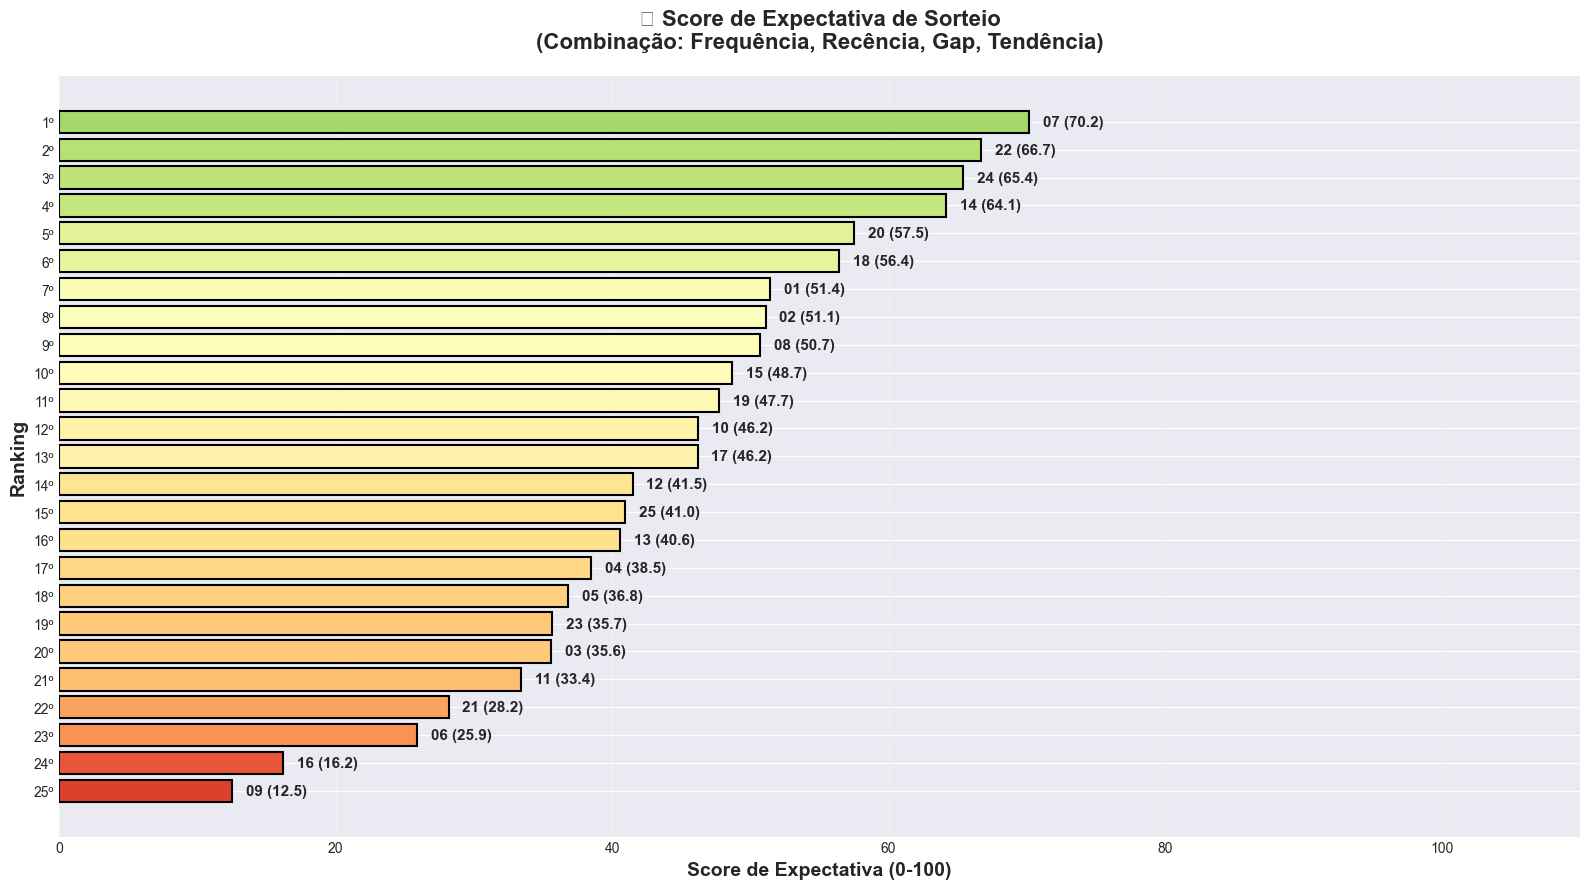

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3126157174.py:103: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


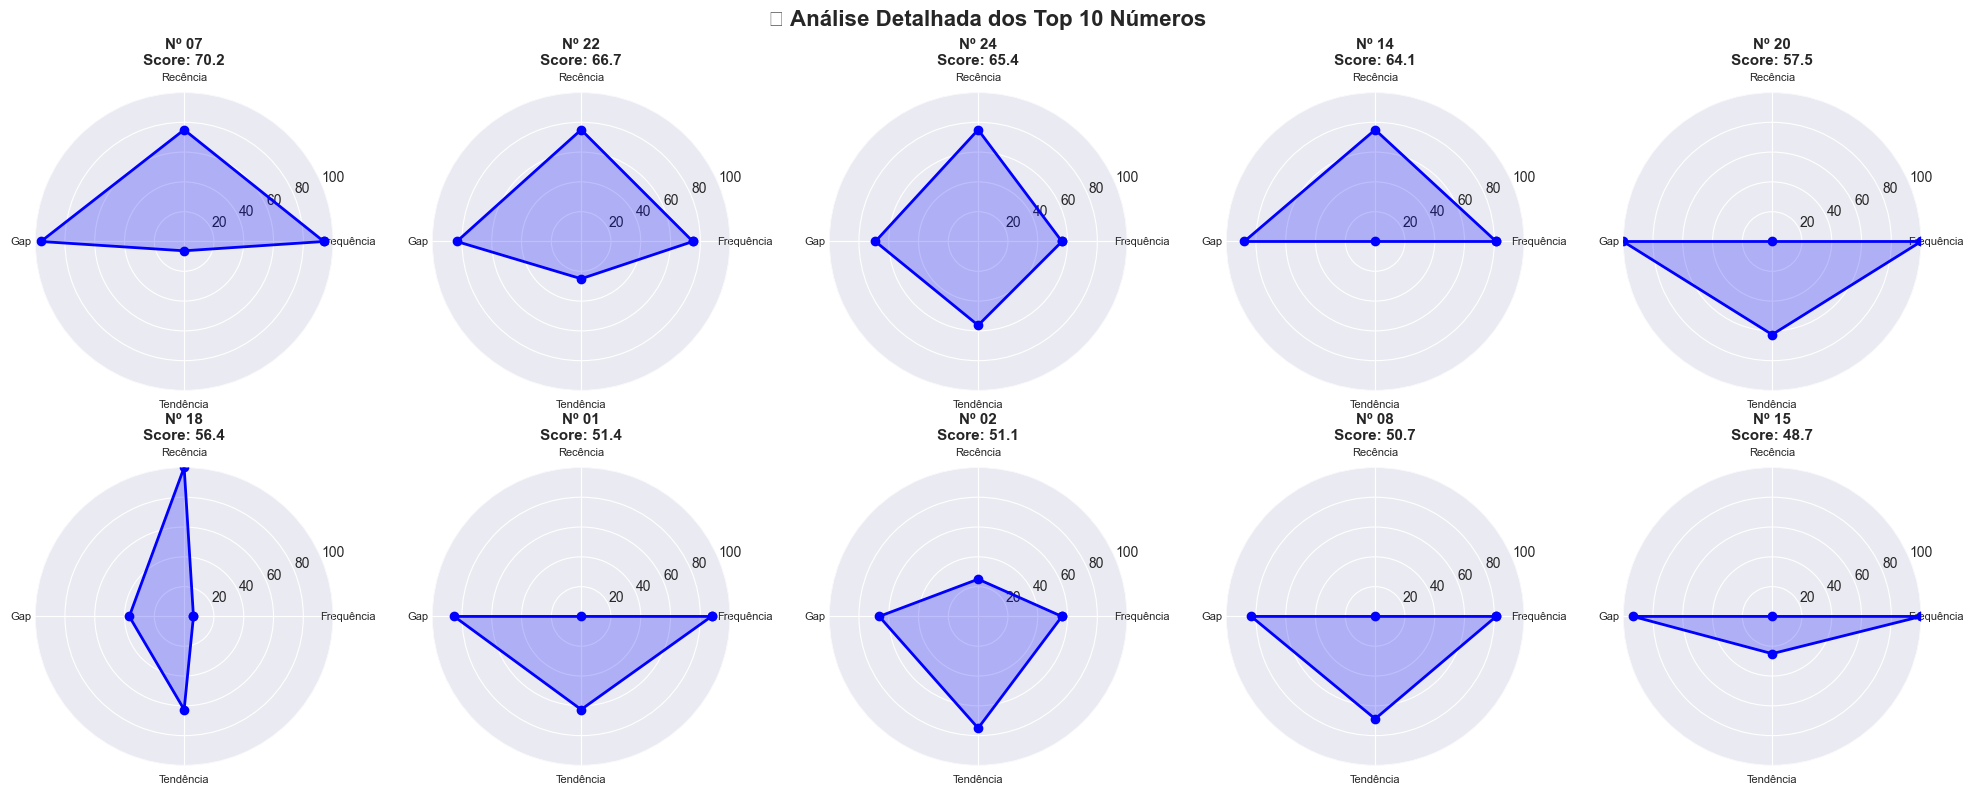


🎯 SCORE DE EXPECTATIVA - RANKING FINAL:
Rank   Nº   Score    Freq   Dias   Gap      Tend     Análise                       
----------------------------------------------------------------------------------------------------
1      07      70.2  49     3      1.8        -4.00  🟢 ALTA expectativa
2      22      66.7  46     3      1.9        -2.50  🟡 MÉDIA expectativa
3      24      65.4  43     3      2.0        -0.00  🟡 MÉDIA expectativa
4      14      64.1  47     3      1.8        -4.50  🟡 MÉDIA expectativa
5      20      57.5  50     0      1.7        +0.50  🟡 MÉDIA expectativa
6      18      56.4  35     4      2.3        +0.50  🟡 MÉDIA expectativa
7      01      51.4  48     0      1.9        +0.50  🟡 MÉDIA expectativa
8      02      51.1  43     1      2.0        +1.50  🟡 MÉDIA expectativa
9      08      50.7  47     0      1.9        +1.00  🟡 MÉDIA expectativa
10     15      48.7  50     0      1.8        -2.50  🔴 BAIXA expectativa
11     19      47.7  47     0      1.9       

In [14]:
# Combinar todos os dados
score_df = pd.DataFrame({
    'Numero': range(1, 26)
})

# Merge com todos os dataframes
score_df = score_df.merge(frequencia_df[['Numero', 'Frequencia']], on='Numero')
score_df = score_df.merge(recencia_df[['Numero', 'Dias_Desde_Ultimo']], on='Numero')
score_df = score_df.merge(gap_df[['Numero', 'Gap_Medio']], on='Numero')
score_df = score_df.merge(tendencia_df[['Numero', 'Tendencia']], on='Numero')

# Normalizar cada métrica para escala 0-100
def normalizar(serie, inverter=False):
    """Normaliza série para 0-100. Se inverter=True, valores altos ficam baixos."""
    min_val = serie.min()
    max_val = serie.max()
    if max_val == min_val:
        return pd.Series([50] * len(serie))
    
    norm = ((serie - min_val) / (max_val - min_val)) * 100
    if inverter:
        norm = 100 - norm
    return norm

score_df['Score_Frequencia'] = normalizar(score_df['Frequencia'])
score_df['Score_Recencia'] = normalizar(score_df['Dias_Desde_Ultimo'])  # Quanto mais dias, maior expectativa
score_df['Score_Gap'] = normalizar(score_df['Gap_Medio'], inverter=True)  # Gap menor = melhor
score_df['Score_Tendencia'] = normalizar(score_df['Tendencia'])

# Calcular score final (média ponderada)
# Pesos: Frequência=25%, Recência=35%, Gap=20%, Tendência=20%
score_df['Score_Final'] = (
    score_df['Score_Frequencia'] * 0.25 +
    score_df['Score_Recencia'] * 0.35 +
    score_df['Score_Gap'] * 0.20 +
    score_df['Score_Tendencia'] * 0.20
)

score_df = score_df.sort_values('Score_Final', ascending=False)

# Criar gráfico do score final
fig, ax = plt.subplots(figsize=(16, 9))

# Cores em gradiente
colors = plt.cm.RdYlGn(score_df['Score_Final'] / 100)

bars = ax.barh(range(len(score_df)), score_df['Score_Final'], 
               color=colors, edgecolor='black', linewidth=1.5)

# Adicionar números e scores
for i, (idx, row) in enumerate(score_df.iterrows()):
    ax.text(row['Score_Final'] + 1, i, f"{int(row['Numero']):02d} ({row['Score_Final']:.1f})", 
            va='center', fontweight='bold', fontsize=11)

# Configurações
ax.set_xlabel('Score de Expectativa (0-100)', fontsize=14, fontweight='bold')
ax.set_ylabel('Ranking', fontsize=14, fontweight='bold')
ax.set_title('🎯 Score de Expectativa de Sorteio\n(Combinação: Frequência, Recência, Gap, Tendência)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_yticks(range(len(score_df)))
ax.set_yticklabels([f'{i+1}º' for i in range(len(score_df))])
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Gráfico de radar para top 10
top_10 = score_df.head(10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for idx, (_, row) in enumerate(top_10.iterrows()):
    ax = axes[idx]
    
    # Dados para o radar
    categorias = ['Frequência', 'Recência', 'Gap', 'Tendência']
    valores = [
        row['Score_Frequencia'],
        row['Score_Recencia'],
        row['Score_Gap'],
        row['Score_Tendencia']
    ]
    
    # Fechar o polígono
    valores += valores[:1]
    angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
    angulos += angulos[:1]
    
    # Plot
    ax.plot(angulos, valores, 'o-', linewidth=2, color='blue')
    ax.fill(angulos, valores, alpha=0.25, color='blue')
    ax.set_ylim(0, 100)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=8)
    ax.set_title(f'Nº {int(row["Numero"]):02d}\nScore: {row["Score_Final"]:.1f}', 
                 fontweight='bold', fontsize=11)
    ax.grid(True)

plt.suptitle('📊 Análise Detalhada dos Top 10 Números', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Estatísticas finais
print("\n🎯 SCORE DE EXPECTATIVA - RANKING FINAL:")
print("="*100)
print(f"{'Rank':<6} {'Nº':<4} {'Score':<8} {'Freq':<6} {'Dias':<6} {'Gap':<8} {'Tend':<8} {'Análise':<30}")
print("-"*100)

for rank, (_, row) in enumerate(score_df.iterrows(), 1):
    analise = ""
    if row['Score_Final'] > 70:
        analise = "🟢 ALTA expectativa"
    elif row['Score_Final'] > 50:
        analise = "🟡 MÉDIA expectativa"
    else:
        analise = "🔴 BAIXA expectativa"
    
    print(f"{rank:<6} {int(row['Numero']):02d}    {row['Score_Final']:6.1f}  "
          f"{row['Frequencia']:<6.0f} {row['Dias_Desde_Ultimo']:<6.0f} "
          f"{row['Gap_Medio']:<8.1f} {row['Tendencia']:+7.2f}  {analise}")

print("="*100)
print(f"\n💡 INTERPRETAÇÃO DO SCORE:")
print(f"   • 70-100: ALTA expectativa (número 'quente', atrasado, ou em crescimento)")
print(f"   • 50-70:  MÉDIA expectativa (equilibrado)")
print(f"   • 0-50:   BAIXA expectativa (número 'frio', recente, ou em queda)")
print(f"\n🎯 TOP 5 RECOMENDADOS para próximos sorteios:")
for rank, (_, row) in enumerate(score_df.head(5).iterrows(), 1):
    print(f"   {rank}º - Número {int(row['Numero']):02d} (Score: {row['Score_Final']:.1f})")
print("="*100)

## 8️⃣ Análise de Trincas - Últimos 20 Jogos

Análise das combinações de 3 números (trincas) mais quentes e mais frias nos últimos 20 sorteios.

📊 Analisando últimos 20 sorteios:
   Concurso 3561 até 3580
   Data: 12/12/2025 até 06/01/2026

🔥 TOP 20 TRINCAS MAIS QUENTES (Mais frequentes nos últimos 20 jogos)
Rank   Trinca               Freq   %        Visualização
------------------------------------------------------------------------------------------
1      01-04-20             11      55.0%   ███████████░░░░░░░░░
2      01-08-20             10      50.0%   ██████████░░░░░░░░░░
3      01-15-20             10      50.0%   ██████████░░░░░░░░░░
4      04-08-20             10      50.0%   ██████████░░░░░░░░░░
5      05-06-20             10      50.0%   ██████████░░░░░░░░░░
6      01-02-10             10      50.0%   ██████████░░░░░░░░░░
7      01-10-20             10      50.0%   ██████████░░░░░░░░░░
8      01-04-08             9       45.0%   █████████░░░░░░░░░░░
9      01-04-15             9       45.0%   █████████░░░░░░░░░░░
10     01-20-25             9       45.0%   █████████░░░░░░░░░░░
11     04-20-25             9       4

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2110326860.py:99: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2110326860.py:99: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2110326860.py:99: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATI

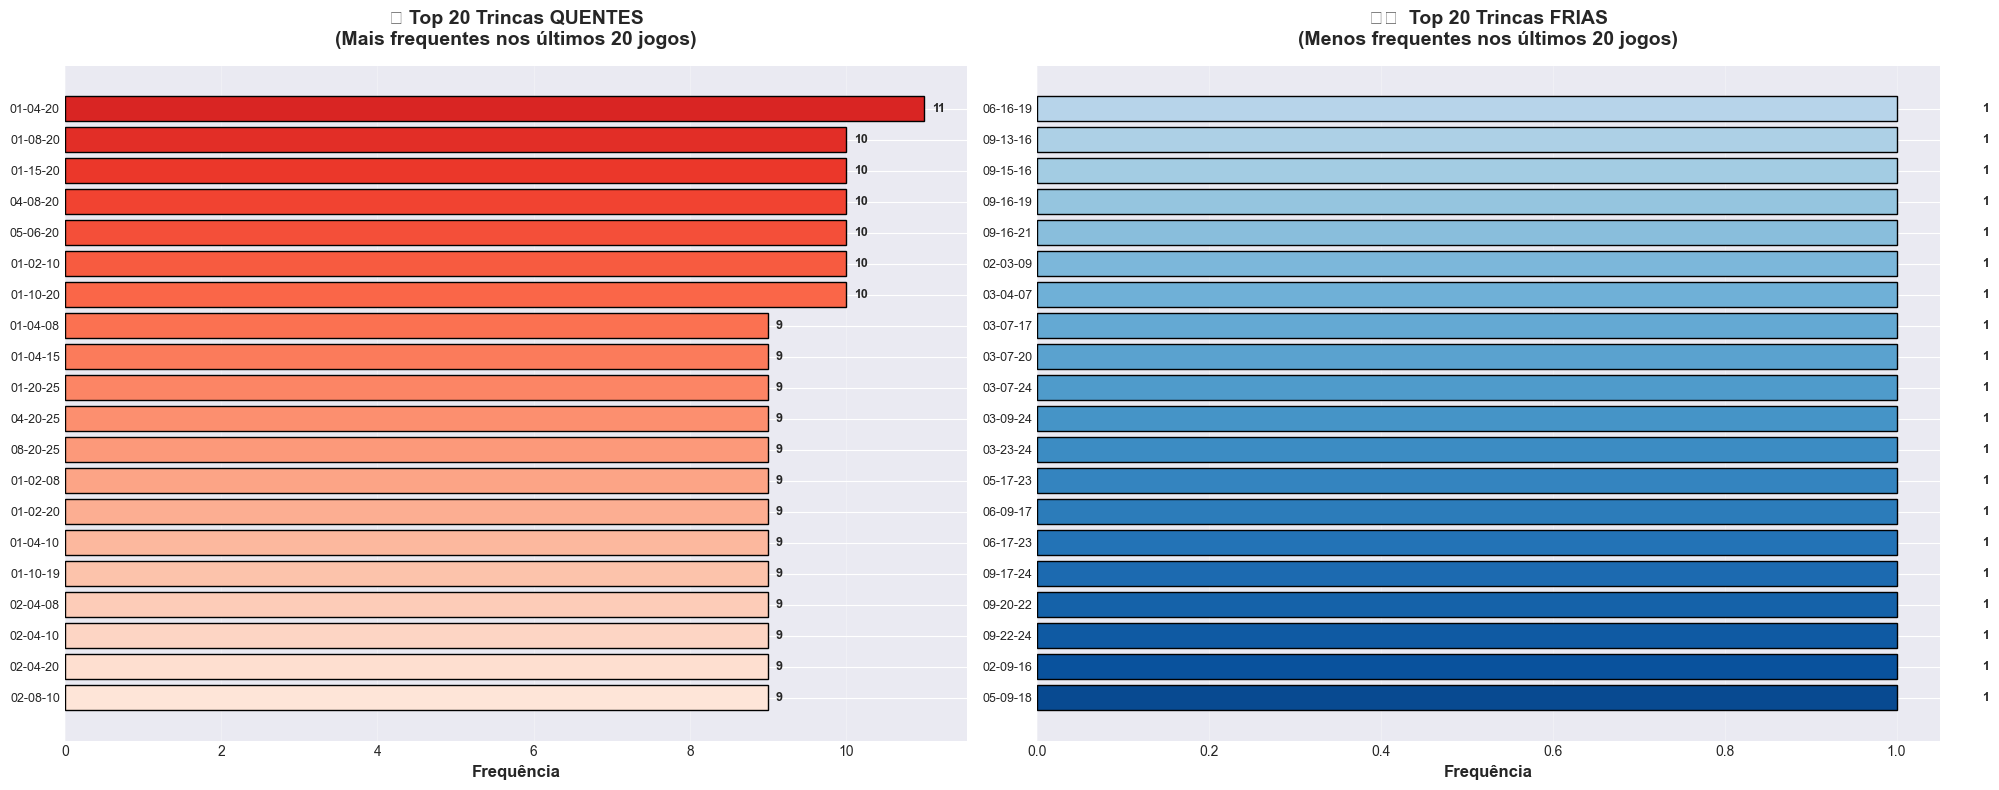


📈 ESTATÍSTICAS GERAIS DAS TRINCAS:
Total de trincas diferentes encontradas: 2,271
Total de trincas analisadas: 9,100
Frequência máxima: 11 aparições
Frequência mínima: 1 aparição(ões)
Frequência média: 4.01 aparições

Trincas que apareceram 3+ vezes: 1814

🎯 Trincas com 3 ou mais aparições (candidatas 'quentes'):
   01-04-20: 11 vezes
   01-08-20: 10 vezes
   01-15-20: 10 vezes
   04-08-20: 10 vezes
   05-06-20: 10 vezes
   01-02-10: 10 vezes
   01-10-20: 10 vezes
   01-04-08: 9 vezes
   01-04-15: 9 vezes
   01-20-25: 9 vezes


In [5]:
from itertools import combinations
from collections import Counter

# Filtrar últimos 20 sorteios
ultimos_20 = df.nlargest(20, 'Concurso')

print(f"📊 Analisando últimos 20 sorteios:")
print(f"   Concurso {ultimos_20['Concurso'].min()} até {ultimos_20['Concurso'].max()}")
print(f"   Data: {ultimos_20['Data Sorteio'].min().strftime('%d/%m/%Y')} até {ultimos_20['Data Sorteio'].max().strftime('%d/%m/%Y')}")

# Extrair todas as trincas dos últimos 20 jogos
todas_trincas = []

for idx, row in ultimos_20.iterrows():
    # Pegar os 15 números do sorteio
    numeros = sorted([row[f'Bola{i}'] for i in range(1, 16)])
    
    # Gerar todas as combinações de 3 números
    trincas_sorteio = list(combinations(numeros, 3))
    todas_trincas.extend(trincas_sorteio)

# Contar frequência de cada trinca
contador_trincas = Counter(todas_trincas)

# Separar quentes e frias
trincas_quentes = contador_trincas.most_common(20)  # Top 20 mais frequentes
todas_possiveis = list(contador_trincas.keys())
trincas_frias = [(t, contador_trincas[t]) for t in sorted(todas_possiveis, key=lambda x: contador_trincas[x])[:20]]

# Visualização - Trincas Quentes
print("\n" + "="*90)
print("🔥 TOP 20 TRINCAS MAIS QUENTES (Mais frequentes nos últimos 20 jogos)")
print("="*90)
print(f"{'Rank':<6} {'Trinca':<20} {'Freq':<6} {'%':<8} {'Visualização'}")
print("-"*90)

for rank, (trinca, freq) in enumerate(trincas_quentes, 1):
    percentual = (freq / 20) * 100
    barra = '█' * int(freq) + '░' * (20 - int(freq))
    trinca_str = f"{trinca[0]:02d}-{trinca[1]:02d}-{trinca[2]:02d}"
    print(f"{rank:<6} {trinca_str:<20} {freq:<6} {percentual:>5.1f}%   {barra}")

# Visualização - Trincas Frias
print("\n" + "="*90)
print("❄️  TOP 20 TRINCAS MAIS FRIAS (Menos frequentes nos últimos 20 jogos)")
print("="*90)
print(f"{'Rank':<6} {'Trinca':<20} {'Freq':<6} {'%':<8} {'Visualização'}")
print("-"*90)

for rank, (trinca, freq) in enumerate(trincas_frias, 1):
    percentual = (freq / 20) * 100
    barra = '█' * int(freq) + '░' * (20 - int(freq))
    trinca_str = f"{trinca[0]:02d}-{trinca[1]:02d}-{trinca[2]:02d}"
    print(f"{rank:<6} {trinca_str:<20} {freq:<6} {percentual:>5.1f}%   {barra}")

# Gráficos de barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Trincas Quentes
trincas_q_labels = [f"{t[0]:02d}-{t[1]:02d}-{t[2]:02d}" for t, _ in trincas_quentes]
trincas_q_valores = [f for _, f in trincas_quentes]

bars1 = ax1.barh(range(len(trincas_q_labels)), trincas_q_valores, 
                 color=plt.cm.Reds_r(np.linspace(0.3, 0.9, len(trincas_q_labels))),
                 edgecolor='black', linewidth=1)

ax1.set_yticks(range(len(trincas_q_labels)))
ax1.set_yticklabels(trincas_q_labels, fontsize=9)
ax1.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax1.set_title('🔥 Top 20 Trincas QUENTES\n(Mais frequentes nos últimos 20 jogos)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Adicionar valores nas barras
for i, v in enumerate(trincas_q_valores):
    ax1.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=9)

# Gráfico 2: Trincas Frias
trincas_f_labels = [f"{t[0]:02d}-{t[1]:02d}-{t[2]:02d}" for t, _ in trincas_frias]
trincas_f_valores = [f for _, f in trincas_frias]

bars2 = ax2.barh(range(len(trincas_f_labels)), trincas_f_valores, 
                 color=plt.cm.Blues(np.linspace(0.3, 0.9, len(trincas_f_labels))),
                 edgecolor='black', linewidth=1)

ax2.set_yticks(range(len(trincas_f_labels)))
ax2.set_yticklabels(trincas_f_labels, fontsize=9)
ax2.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax2.set_title('❄️  Top 20 Trincas FRIAS\n(Menos frequentes nos últimos 20 jogos)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Adicionar valores nas barras
for i, v in enumerate(trincas_f_valores):
    ax2.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Estatísticas gerais
print("\n" + "="*90)
print("📈 ESTATÍSTICAS GERAIS DAS TRINCAS:")
print("="*90)
print(f"Total de trincas diferentes encontradas: {len(contador_trincas):,}")
print(f"Total de trincas analisadas: {len(todas_trincas):,}")
print(f"Frequência máxima: {max(contador_trincas.values())} aparições")
print(f"Frequência mínima: {min(contador_trincas.values())} aparição(ões)")
print(f"Frequência média: {sum(contador_trincas.values()) / len(contador_trincas):.2f} aparições")

# Trincas que aparecem em múltiplos jogos
trincas_multiplas = {t: f for t, f in contador_trincas.items() if f >= 3}
print(f"\nTrincas que apareceram 3+ vezes: {len(trincas_multiplas)}")

if len(trincas_multiplas) > 0:
    print("\n🎯 Trincas com 3 ou mais aparições (candidatas 'quentes'):")
    for trinca, freq in sorted(trincas_multiplas.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"   {trinca[0]:02d}-{trinca[1]:02d}-{trinca[2]:02d}: {freq} vezes")

print("="*90)

📊 Analisando últimos 20 sorteios:
   Concurso 3561 até 3580
   Data: 12/12/2025 até 06/01/2026

🔥 TOP 20 DUPLAS MAIS QUENTES (Mais frequentes nos últimos 20 jogos)
Rank   Trinca               Freq   %        Visualização
------------------------------------------------------------------------------------------
1      01-20                13      65.0%   █████████████░░░░░░░
2      04-20                13      65.0%   █████████████░░░░░░░
3      01-04                12      60.0%   ████████████░░░░░░░░
4      08-20                12      60.0%   ████████████░░░░░░░░
5      01-10                12      60.0%   ████████████░░░░░░░░
6      02-10                12      60.0%   ████████████░░░░░░░░
7      01-08                11      55.0%   ███████████░░░░░░░░░
8      01-15                11      55.0%   ███████████░░░░░░░░░
9      04-08                11      55.0%   ███████████░░░░░░░░░
10     05-06                11      55.0%   ███████████░░░░░░░░░
11     08-25                11      55

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2338997002.py:99: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2338997002.py:99: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\2338997002.py:99: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10052 (\N{SNOWFLAKE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATI

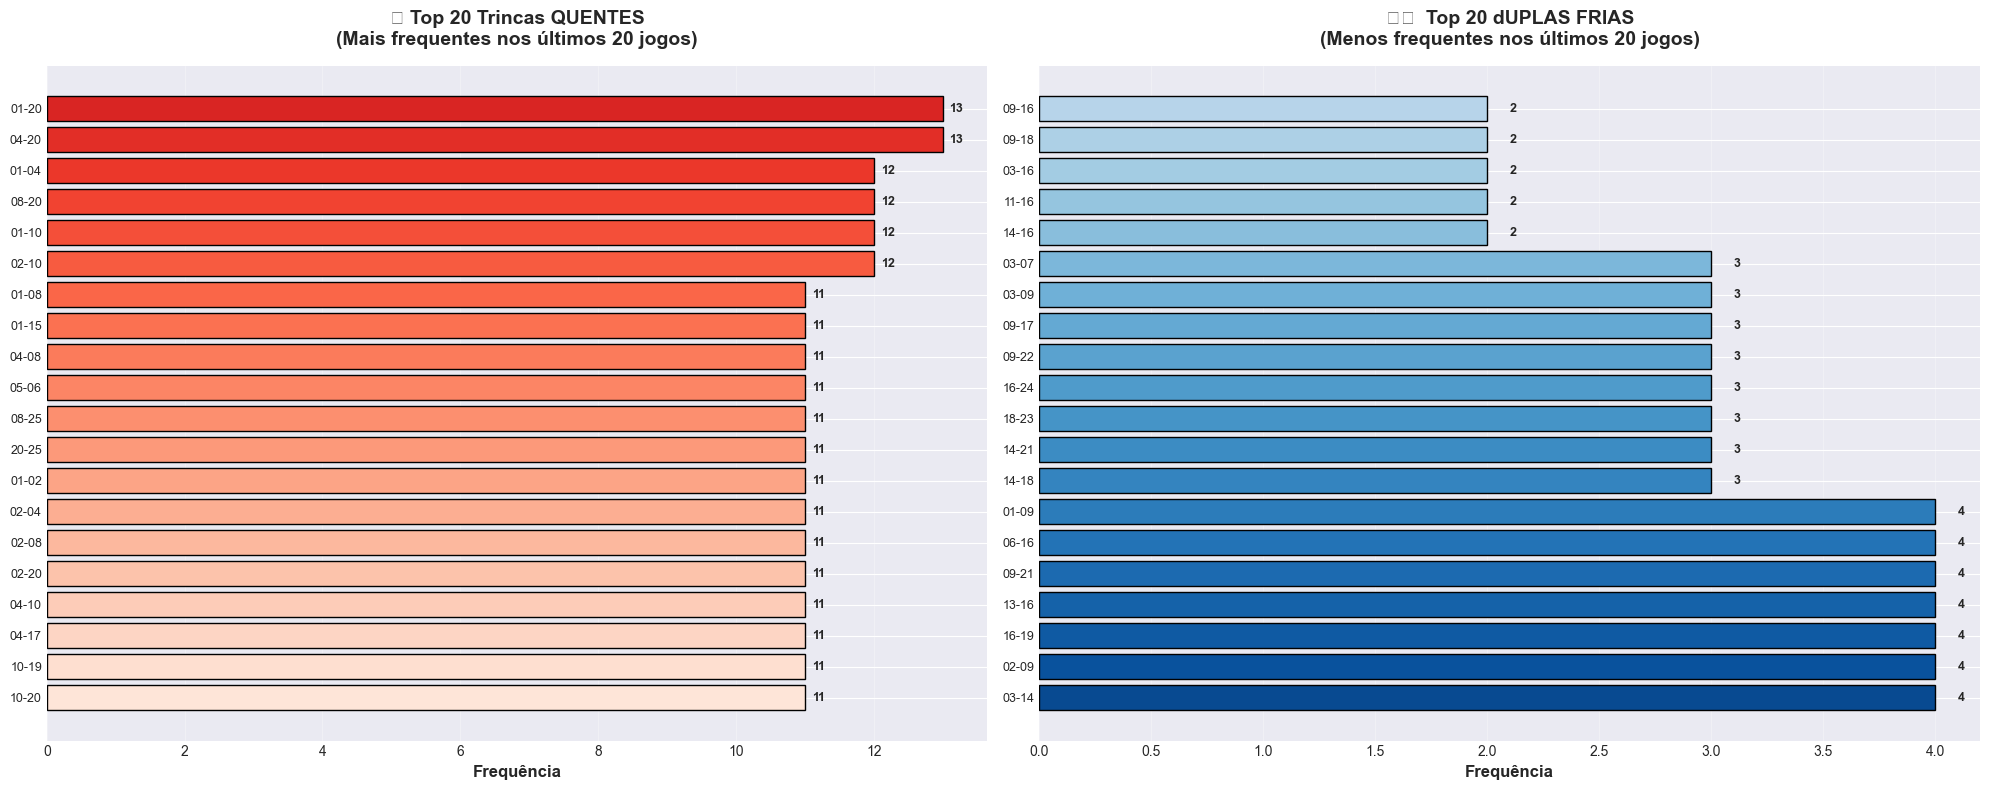


📈 ESTATÍSTICAS GERAIS DAS duplas:
Total de duplas diferentes encontradas: 300
Total de duplas analisadas: 2,100
Frequência máxima: 13 aparições
Frequência mínima: 2 aparição(ões)
Frequência média: 7.00 aparições
\duplas que apareceram 3+ vezes: 295

🎯 duplas com 3 ou mais aparições (candidatas 'quentes'):
   01-20: 13 vezes
   04-20: 13 vezes
   01-04: 12 vezes
   08-20: 12 vezes
   01-10: 12 vezes
   02-10: 12 vezes
   01-08: 11 vezes
   01-15: 11 vezes
   04-08: 11 vezes
   05-06: 11 vezes


In [6]:
from itertools import combinations
from collections import Counter

# Filtrar últimos 20 sorteios
ultimos_20 = df.nlargest(20, 'Concurso')

print(f"📊 Analisando últimos 20 sorteios:")
print(f"   Concurso {ultimos_20['Concurso'].min()} até {ultimos_20['Concurso'].max()}")
print(f"   Data: {ultimos_20['Data Sorteio'].min().strftime('%d/%m/%Y')} até {ultimos_20['Data Sorteio'].max().strftime('%d/%m/%Y')}")

# Extrair todas as trincas dos últimos 20 jogos
todas_trincas = []

for idx, row in ultimos_20.iterrows():
    # Pegar os 15 números do sorteio
    numeros = sorted([row[f'Bola{i}'] for i in range(1, 16)])
    
    # Gerar todas as combinações de 3 números
    trincas_sorteio = list(combinations(numeros, 2))
    todas_trincas.extend(trincas_sorteio)

# Contar frequência de cada trinca
contador_trincas = Counter(todas_trincas)

# Separar quentes e frias
trincas_quentes = contador_trincas.most_common(20)  # Top 20 mais frequentes
todas_possiveis = list(contador_trincas.keys())
trincas_frias = [(t, contador_trincas[t]) for t in sorted(todas_possiveis, key=lambda x: contador_trincas[x])[:20]]

# Visualização - Trincas Quentes
print("\n" + "="*90)
print("🔥 TOP 20 DUPLAS MAIS QUENTES (Mais frequentes nos últimos 20 jogos)")
print("="*90)
print(f"{'Rank':<6} {'Trinca':<20} {'Freq':<6} {'%':<8} {'Visualização'}")
print("-"*90)

for rank, (trinca, freq) in enumerate(trincas_quentes, 1):
    percentual = (freq / 20) * 100
    barra = '█' * int(freq) + '░' * (20 - int(freq))
    trinca_str = f"{trinca[0]:02d}-{trinca[1]:02d}"
    print(f"{rank:<6} {trinca_str:<20} {freq:<6} {percentual:>5.1f}%   {barra}")

# Visualização - Trincas Frias
print("\n" + "="*90)
print("❄️  TOP 20 DUPLAS MAIS FRIAS (Menos frequentes nos últimos 20 jogos)")
print("="*90)
print(f"{'Rank':<6} {'Trinca':<20} {'Freq':<6} {'%':<8} {'Visualização'}")
print("-"*90)

for rank, (trinca, freq) in enumerate(trincas_frias, 1):
    percentual = (freq / 20) * 100
    barra = '█' * int(freq) + '░' * (20 - int(freq))
    trinca_str = f"{trinca[0]:02d}-{trinca[1]:02d}"
    print(f"{rank:<6} {trinca_str:<20} {freq:<6} {percentual:>5.1f}%   {barra}")

# Gráficos de barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Trincas Quentes
trincas_q_labels = [f"{t[0]:02d}-{t[1]:02d}" for t, _ in trincas_quentes]
trincas_q_valores = [f for _, f in trincas_quentes]

bars1 = ax1.barh(range(len(trincas_q_labels)), trincas_q_valores, 
                 color=plt.cm.Reds_r(np.linspace(0.3, 0.9, len(trincas_q_labels))),
                 edgecolor='black', linewidth=1)

ax1.set_yticks(range(len(trincas_q_labels)))
ax1.set_yticklabels(trincas_q_labels, fontsize=9)
ax1.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax1.set_title('🔥 Top 20 Trincas QUENTES\n(Mais frequentes nos últimos 20 jogos)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Adicionar valores nas barras
for i, v in enumerate(trincas_q_valores):
    ax1.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=9)

# Gráfico 2: Trincas Frias
trincas_f_labels = [f"{t[0]:02d}-{t[1]:02d}" for t, _ in trincas_frias]
trincas_f_valores = [f for _, f in trincas_frias]

bars2 = ax2.barh(range(len(trincas_f_labels)), trincas_f_valores, 
                 color=plt.cm.Blues(np.linspace(0.3, 0.9, len(trincas_f_labels))),
                 edgecolor='black', linewidth=1)

ax2.set_yticks(range(len(trincas_f_labels)))
ax2.set_yticklabels(trincas_f_labels, fontsize=9)
ax2.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax2.set_title('❄️  Top 20 dUPLAS FRIAS\n(Menos frequentes nos últimos 20 jogos)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Adicionar valores nas barras
for i, v in enumerate(trincas_f_valores):
    ax2.text(v + 0.1, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Estatísticas gerais
print("\n" + "="*90)
print("📈 ESTATÍSTICAS GERAIS DAS duplas:")
print("="*90)
print(f"Total de duplas diferentes encontradas: {len(contador_trincas):,}")
print(f"Total de duplas analisadas: {len(todas_trincas):,}")
print(f"Frequência máxima: {max(contador_trincas.values())} aparições")
print(f"Frequência mínima: {min(contador_trincas.values())} aparição(ões)")
print(f"Frequência média: {sum(contador_trincas.values()) / len(contador_trincas):.2f} aparições")

# Trincas que aparecem em múltiplos jogos
trincas_multiplas = {t: f for t, f in contador_trincas.items() if f >= 3}
print(f"\duplas que apareceram 3+ vezes: {len(trincas_multiplas)}")

if len(trincas_multiplas) > 0:
    print("\n🎯 duplas com 3 ou mais aparições (candidatas 'quentes'):")
    for trinca, freq in sorted(trincas_multiplas.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"   {trinca[0]:02d}-{trinca[1]:02d}: {freq} vezes")

print("="*90)

## 9️⃣ Análise de Acertos por Data - Pool Específico

Verificação de quantos números do pool (1,2,4,5,6,8,9,10,15,16,17,19,20,22,24,25) acertaram em cada sorteio.

🎯 Pool selecionado (19 números):
   01, 02, 04, 05, 06, 08, 09, 10, 12, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25


📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:
Concurso   Data         Acertos  Números Acertados                                           
----------------------------------------------------------------------------------------------------
3580       06/01/2026   🟢 13     01, 04, 05, 06, 08, 09, 12, 15, 16, 19, 20, 23, 25          
3579       05/01/2026   🟡 11     01, 02, 04, 08, 10, 15, 17, 19, 20, 23, 25                  
3578       03/01/2026   🟡 12     02, 04, 05, 06, 09, 10, 17, 19, 20, 22, 23, 24              
3577       02/01/2026   🟢 15     01, 02, 04, 05, 06, 08, 09, 10, 12, 16, 18, 20, 23, 24, 25  
3576       01/01/2026   🟡 11     01, 02, 05, 08, 10, 16, 18, 19, 22, 23, 25                  
3575       30/12/2025   🟡 11     02, 04, 05, 08, 09, 10, 12, 15, 17, 22, 25                  
3574       29/12/2025   🟡 12     01, 04, 05, 06, 08, 12, 15, 16, 17, 18, 20, 25        

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\4064912067.py:139: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


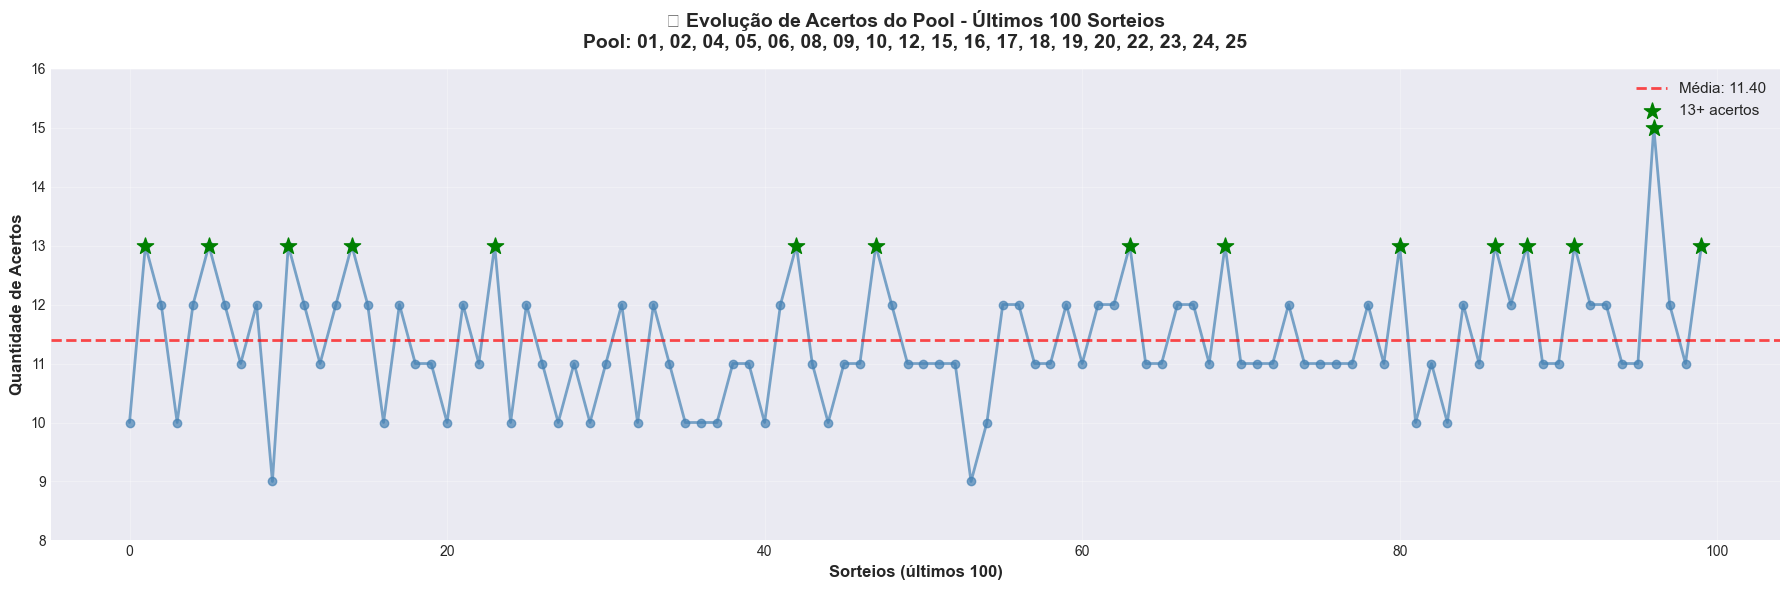

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\4064912067.py:166: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


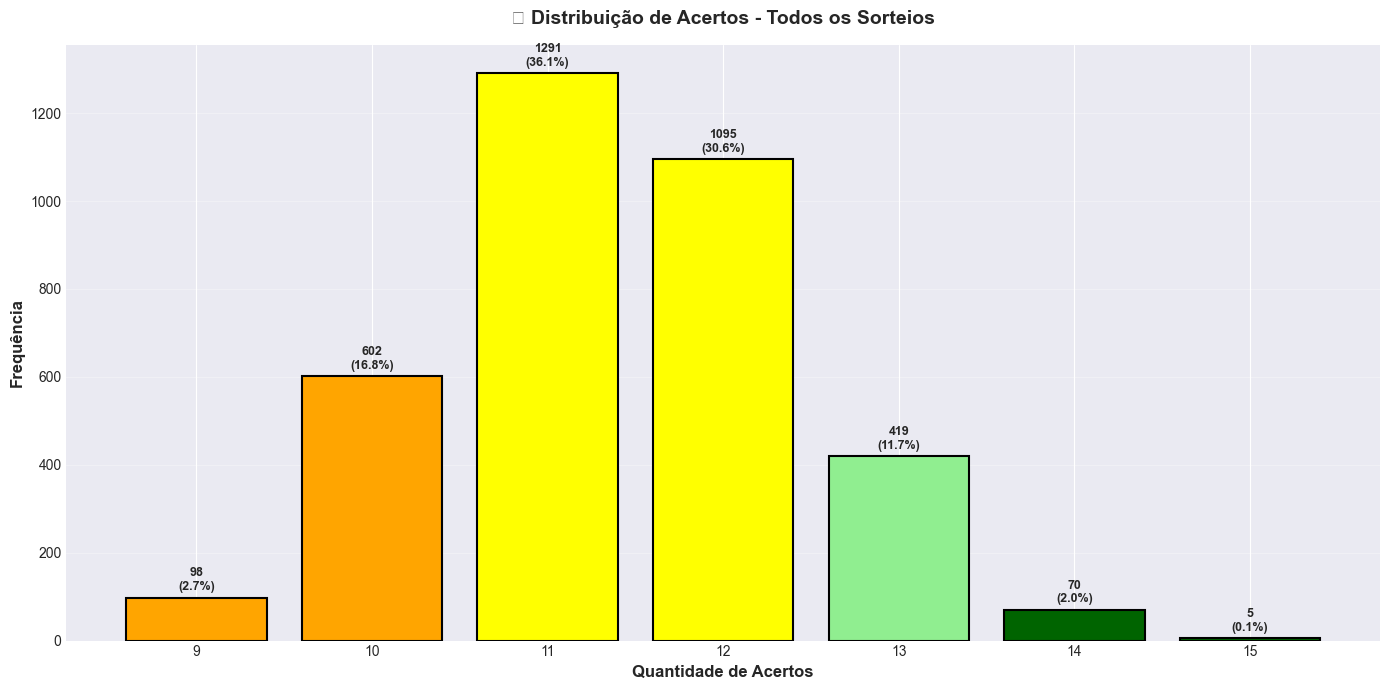

In [17]:
# Definir o pool
#pool = [1, 2, 4, 5, 6, 8, 9, 10, 15, 16, 17, 19, 20, 22, 24, 25]
pool = [1, 2, 4, 5, 6, 8, 9, 10, 12, 15, 16, 17, 18, 19, 20, 22, 23, 24, 25]

print(f"🎯 Pool selecionado ({len(pool)} números):")
print(f"   {', '.join([f'{n:02d}' for n in pool])}")
print(f"\n{'='*100}")

# Analisar todos os sorteios
resultados = []

for idx, row in df.iterrows():
    concurso = row['Concurso']
    data = row['Data Sorteio']
    numeros_sorteados = [row[f'Bola{i}'] for i in range(1, 16)]
    
    # Contar quantos números do pool foram sorteados
    acertos = len([n for n in numeros_sorteados if n in pool])
    numeros_acertados = sorted([n for n in numeros_sorteados if n in pool])
    
    resultados.append({
        'Concurso': concurso,
        'Data': data,
        'Acertos': acertos,
        'Numeros_Acertados': numeros_acertados
    })

# Criar DataFrame
df_acertos = pd.DataFrame(resultados)

# Mostrar últimos 30 sorteios
print(f"\n📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:")
print("="*100)
print(f"{'Concurso':<10} {'Data':<12} {'Acertos':<8} {'Números Acertados':<60}")
print("-"*100)

for _, row in df_acertos.nlargest(30, 'Concurso').iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    
    # Colorir baseado na quantidade de acertos
    if row['Acertos'] >= 13:
        emoji = '🟢'
    elif row['Acertos'] >= 11:
        emoji = '🟡'
    else:
        emoji = '🔴'
    
    print(f"{row['Concurso']:<10} {data_str:<12} {emoji} {row['Acertos']:<6} {numeros_str:<60}")

print("="*100)

# Estatísticas gerais
print(f"\n📈 ESTATÍSTICAS DE ACERTOS:")
print("="*100)
print(f"Total de sorteios analisados: {len(df_acertos):,}")
print(f"Acertos médios: {df_acertos['Acertos'].mean():.2f} números")
print(f"Máximo de acertos: {df_acertos['Acertos'].max()} números")
print(f"Mínimo de acertos: {df_acertos['Acertos'].min()} números")

# Frequência de cada número do pool
print(f"\n🔢 FREQUÊNCIA DE ACERTOS POR NÚMERO DO POOL:")
print("="*100)
freq_por_numero_pool = {}
for numero in pool:
    count = sum([numero in row['Numeros_Acertados'] for _, row in df_acertos.iterrows()])
    freq_por_numero_pool[numero] = count

# Ordenar por frequência (decrescente)
freq_ordenada = sorted(freq_por_numero_pool.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Número':<8} {'Vezes':<8} {'%':<8} {'Visualização':<50}")
print("-"*100)
for rank, (numero, freq) in enumerate(freq_ordenada, 1):
    percentual = (freq / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"{rank:<6} {numero:02d}       {freq:<8} {percentual:>5.2f}%   {barra}")
print("="*100)

# Distribuição de acertos
print(f"\n📊 DISTRIBUIÇÃO DE ACERTOS:")
distribuicao = df_acertos['Acertos'].value_counts().sort_index()
for acertos, quantidade in distribuicao.items():
    percentual = (quantidade / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"   {acertos:2d} acertos: {quantidade:4d} vezes ({percentual:5.2f}%) {barra}")

# Melhores e piores resultados
print(f"\n🏆 TOP 10 MELHORES RESULTADOS:")
melhores = df_acertos.nlargest(10, 'Acertos')
for idx, row in melhores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

print(f"\n💔 TOP 10 PIORES RESULTADOS:")
piores = df_acertos.nsmallest(10, 'Acertos')
for idx, row in piores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

# Gráfico de linha temporal
fig, ax = plt.subplots(figsize=(18, 6))

# Plotar últimos 100 sorteios
ultimos_100 = df_acertos.nlargest(100, 'Concurso').sort_values('Concurso')

ax.plot(range(len(ultimos_100)), ultimos_100['Acertos'], 
        marker='o', linewidth=2, markersize=6, color='steelblue', alpha=0.7)

# Linha de média
media_acertos = ultimos_100['Acertos'].mean()
ax.axhline(y=media_acertos, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {media_acertos:.2f}', alpha=0.7)

# Destacar acertos >= 13
acertos_altos = ultimos_100[ultimos_100['Acertos'] >= 13]
indices_altos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos >= 13]
if indices_altos:
    ax.scatter(indices_altos, acertos_altos['Acertos'], 
              color='green', s=150, zorder=5, label='13+ acertos', marker='*')

# Destacar acertos <= 8
acertos_baixos = ultimos_100[ultimos_100['Acertos'] <= 8]
indices_baixos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos <= 8]
if indices_baixos:
    ax.scatter(indices_baixos, acertos_baixos['Acertos'], 
              color='red', s=100, zorder=5, label='≤8 acertos', marker='v')

ax.set_xlabel('Sorteios (últimos 100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Evolução de Acertos do Pool - Últimos 100 Sorteios\nPool: {", ".join([f"{n:02d}" for n in pool])}', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(df_acertos['Acertos'].min() - 1, df_acertos['Acertos'].max() + 1)

plt.tight_layout()
plt.show()

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(14, 7))

distribuicao_valores = distribuicao.sort_index()
cores = ['red' if x <= 8 else 'orange' if x <= 10 else 'yellow' if x <= 12 
         else 'lightgreen' if x <= 13 else 'darkgreen' 
         for x in distribuicao_valores.index]

bars = ax.bar(distribuicao_valores.index, distribuicao_valores.values, 
              color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (acertos, quantidade) in enumerate(distribuicao_valores.items()):
    percentual = (quantidade / len(df_acertos)) * 100
    ax.text(acertos, quantidade + 10, f'{quantidade}\n({percentual:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribuição de Acertos - Todos os Sorteios', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(df_acertos['Acertos'].min(), df_acertos['Acertos'].max() + 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*100)

🎯 Pool selecionado (18 números):
   01, 02, 04, 05, 06, 08, 09, 10, 12, 13, 14, 18, 20, 21, 22, 23, 24, 25


📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:
Concurso   Data         Acertos  Números Acertados                                           
----------------------------------------------------------------------------------------------------
3580       06/01/2026   🟡 12     01, 04, 05, 06, 08, 09, 12, 13, 20, 21, 23, 25              
3579       05/01/2026   🔴 10     01, 02, 04, 08, 10, 13, 20, 21, 23, 25                      
3578       03/01/2026   🟡 11     02, 04, 05, 06, 09, 10, 14, 20, 22, 23, 24                  
3577       02/01/2026   🟢 14     01, 02, 04, 05, 06, 08, 09, 10, 12, 18, 20, 23, 24, 25      
3576       01/01/2026   🟡 11     01, 02, 05, 08, 10, 13, 18, 21, 22, 23, 25                  
3575       30/12/2025   🟡 12     02, 04, 05, 08, 09, 10, 12, 13, 14, 21, 22, 25              
3574       29/12/2025   🟡 11     01, 04, 05, 06, 08, 12, 13, 18, 20, 21, 25                

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3477906810.py:139: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


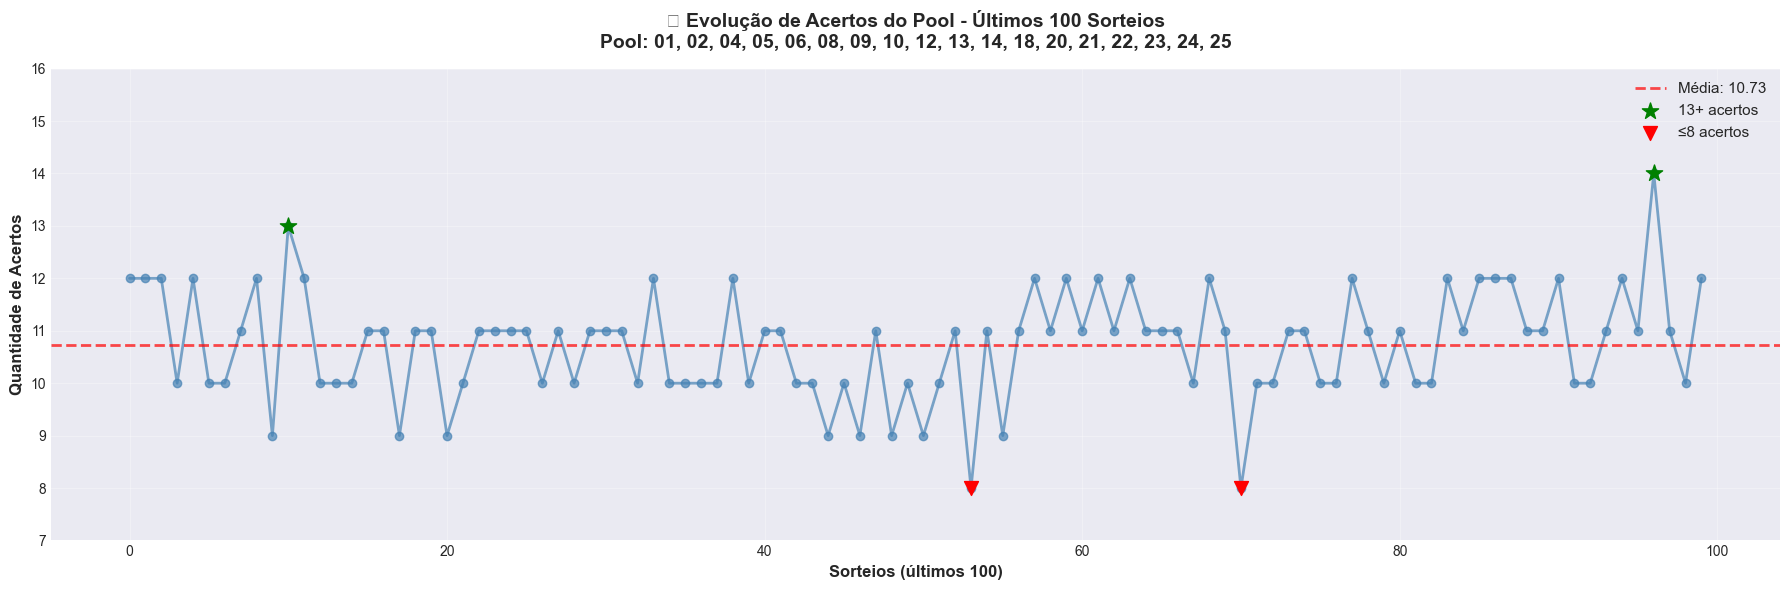

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3477906810.py:166: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


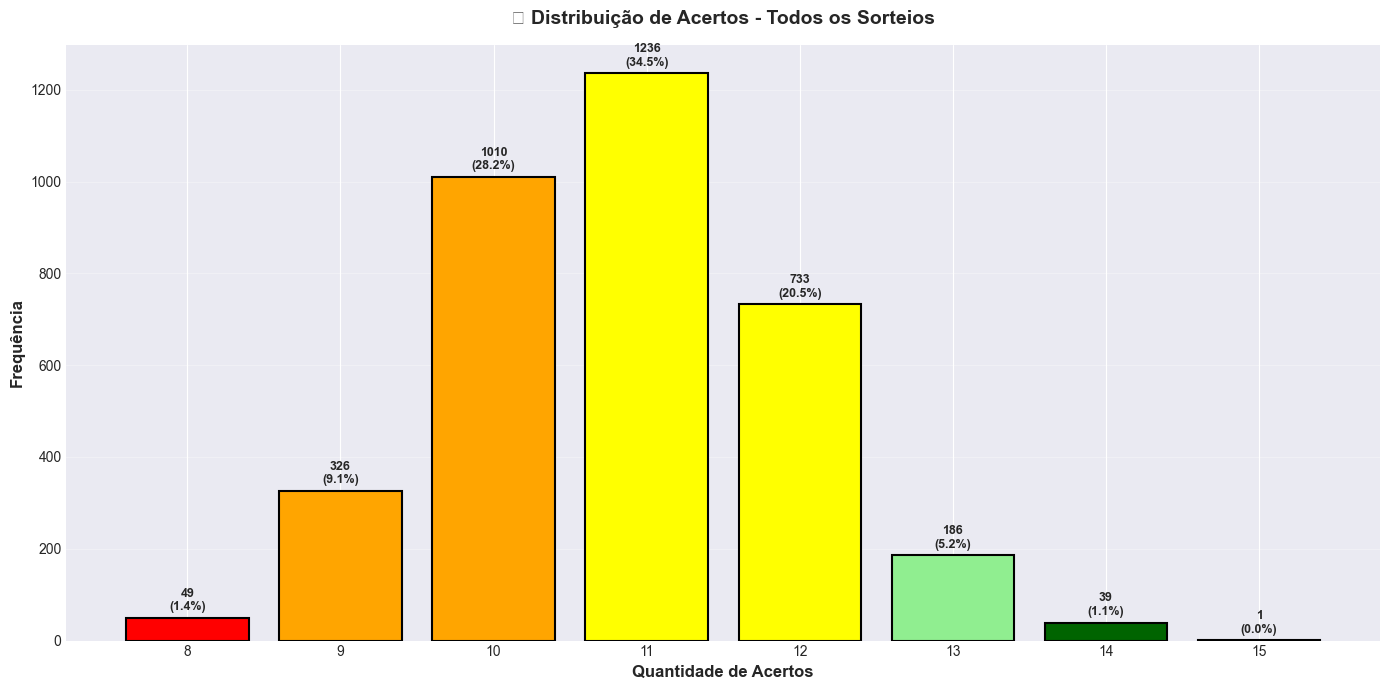

In [26]:
# Definir o pool
#pool = [1, 2, 4, 5, 6, 8, 9, 10, 15, 16, 17, 19, 20, 22, 24, 25]
pool = [1,2,4,5,6,8,9,10,12,13,14,18,20,21,22,23,24,25]

print(f"🎯 Pool selecionado ({len(pool)} números):")
print(f"   {', '.join([f'{n:02d}' for n in pool])}")
print(f"\n{'='*100}")

# Analisar todos os sorteios
resultados = []

for idx, row in df.iterrows():
    concurso = row['Concurso']
    data = row['Data Sorteio']
    numeros_sorteados = [row[f'Bola{i}'] for i in range(1, 16)]
    
    # Contar quantos números do pool foram sorteados
    acertos = len([n for n in numeros_sorteados if n in pool])
    numeros_acertados = sorted([n for n in numeros_sorteados if n in pool])
    
    resultados.append({
        'Concurso': concurso,
        'Data': data,
        'Acertos': acertos,
        'Numeros_Acertados': numeros_acertados
    })

# Criar DataFrame
df_acertos = pd.DataFrame(resultados)

# Mostrar últimos 30 sorteios
print(f"\n📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:")
print("="*100)
print(f"{'Concurso':<10} {'Data':<12} {'Acertos':<8} {'Números Acertados':<60}")
print("-"*100)

for _, row in df_acertos.nlargest(30, 'Concurso').iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    
    # Colorir baseado na quantidade de acertos
    if row['Acertos'] >= 13:
        emoji = '🟢'
    elif row['Acertos'] >= 11:
        emoji = '🟡'
    else:
        emoji = '🔴'
    
    print(f"{row['Concurso']:<10} {data_str:<12} {emoji} {row['Acertos']:<6} {numeros_str:<60}")

print("="*100)

# Estatísticas gerais
print(f"\n📈 ESTATÍSTICAS DE ACERTOS:")
print("="*100)
print(f"Total de sorteios analisados: {len(df_acertos):,}")
print(f"Acertos médios: {df_acertos['Acertos'].mean():.2f} números")
print(f"Máximo de acertos: {df_acertos['Acertos'].max()} números")
print(f"Mínimo de acertos: {df_acertos['Acertos'].min()} números")

# Frequência de cada número do pool
print(f"\n🔢 FREQUÊNCIA DE ACERTOS POR NÚMERO DO POOL:")
print("="*100)
freq_por_numero_pool = {}
for numero in pool:
    count = sum([numero in row['Numeros_Acertados'] for _, row in df_acertos.iterrows()])
    freq_por_numero_pool[numero] = count

# Ordenar por frequência (decrescente)
freq_ordenada = sorted(freq_por_numero_pool.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Número':<8} {'Vezes':<8} {'%':<8} {'Visualização':<50}")
print("-"*100)
for rank, (numero, freq) in enumerate(freq_ordenada, 1):
    percentual = (freq / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"{rank:<6} {numero:02d}       {freq:<8} {percentual:>5.2f}%   {barra}")
print("="*100)

# Distribuição de acertos
print(f"\n📊 DISTRIBUIÇÃO DE ACERTOS:")
distribuicao = df_acertos['Acertos'].value_counts().sort_index()
for acertos, quantidade in distribuicao.items():
    percentual = (quantidade / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"   {acertos:2d} acertos: {quantidade:4d} vezes ({percentual:5.2f}%) {barra}")

# Melhores e piores resultados
print(f"\n🏆 TOP 10 MELHORES RESULTADOS:")
melhores = df_acertos.nlargest(10, 'Acertos')
for idx, row in melhores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

print(f"\n💔 TOP 10 PIORES RESULTADOS:")
piores = df_acertos.nsmallest(10, 'Acertos')
for idx, row in piores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

# Gráfico de linha temporal
fig, ax = plt.subplots(figsize=(18, 6))

# Plotar últimos 100 sorteios
ultimos_100 = df_acertos.nlargest(100, 'Concurso').sort_values('Concurso')

ax.plot(range(len(ultimos_100)), ultimos_100['Acertos'], 
        marker='o', linewidth=2, markersize=6, color='steelblue', alpha=0.7)

# Linha de média
media_acertos = ultimos_100['Acertos'].mean()
ax.axhline(y=media_acertos, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {media_acertos:.2f}', alpha=0.7)

# Destacar acertos >= 13
acertos_altos = ultimos_100[ultimos_100['Acertos'] >= 13]
indices_altos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos >= 13]
if indices_altos:
    ax.scatter(indices_altos, acertos_altos['Acertos'], 
              color='green', s=150, zorder=5, label='13+ acertos', marker='*')

# Destacar acertos <= 8
acertos_baixos = ultimos_100[ultimos_100['Acertos'] <= 8]
indices_baixos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos <= 8]
if indices_baixos:
    ax.scatter(indices_baixos, acertos_baixos['Acertos'], 
              color='red', s=100, zorder=5, label='≤8 acertos', marker='v')

ax.set_xlabel('Sorteios (últimos 100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Evolução de Acertos do Pool - Últimos 100 Sorteios\nPool: {", ".join([f"{n:02d}" for n in pool])}', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(df_acertos['Acertos'].min() - 1, df_acertos['Acertos'].max() + 1)

plt.tight_layout()
plt.show()

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(14, 7))

distribuicao_valores = distribuicao.sort_index()
cores = ['red' if x <= 8 else 'orange' if x <= 10 else 'yellow' if x <= 12 
         else 'lightgreen' if x <= 13 else 'darkgreen' 
         for x in distribuicao_valores.index]

bars = ax.bar(distribuicao_valores.index, distribuicao_valores.values, 
              color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (acertos, quantidade) in enumerate(distribuicao_valores.items()):
    percentual = (quantidade / len(df_acertos)) * 100
    ax.text(acertos, quantidade + 10, f'{quantidade}\n({percentual:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribuição de Acertos - Todos os Sorteios', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(df_acertos['Acertos'].min(), df_acertos['Acertos'].max() + 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*100)

🎯 Pool selecionado (15 números):
   01, 04, 05, 06, 08, 10, 11, 13, 15, 16, 17, 19, 20, 21, 25


📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:
Concurso   Data         Acertos  Números Acertados                                           
----------------------------------------------------------------------------------------------------
3580       06/01/2026   🟡 12     01, 04, 05, 06, 08, 13, 15, 16, 19, 20, 21, 25              
3579       05/01/2026   🟡 12     01, 04, 08, 10, 11, 13, 15, 17, 19, 20, 21, 25              
3578       03/01/2026   🔴 7      04, 05, 06, 10, 17, 19, 20                                  
3577       02/01/2026   🔴 9      01, 04, 05, 06, 08, 10, 16, 20, 25                          
3576       01/01/2026   🔴 9      01, 05, 08, 10, 13, 16, 19, 21, 25                          
3575       30/12/2025   🔴 9      04, 05, 08, 10, 13, 15, 17, 21, 25                          
3574       29/12/2025   🟡 12     01, 04, 05, 06, 08, 13, 15, 16, 17, 20, 21, 25              
3573     

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\2412275036.py:141: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


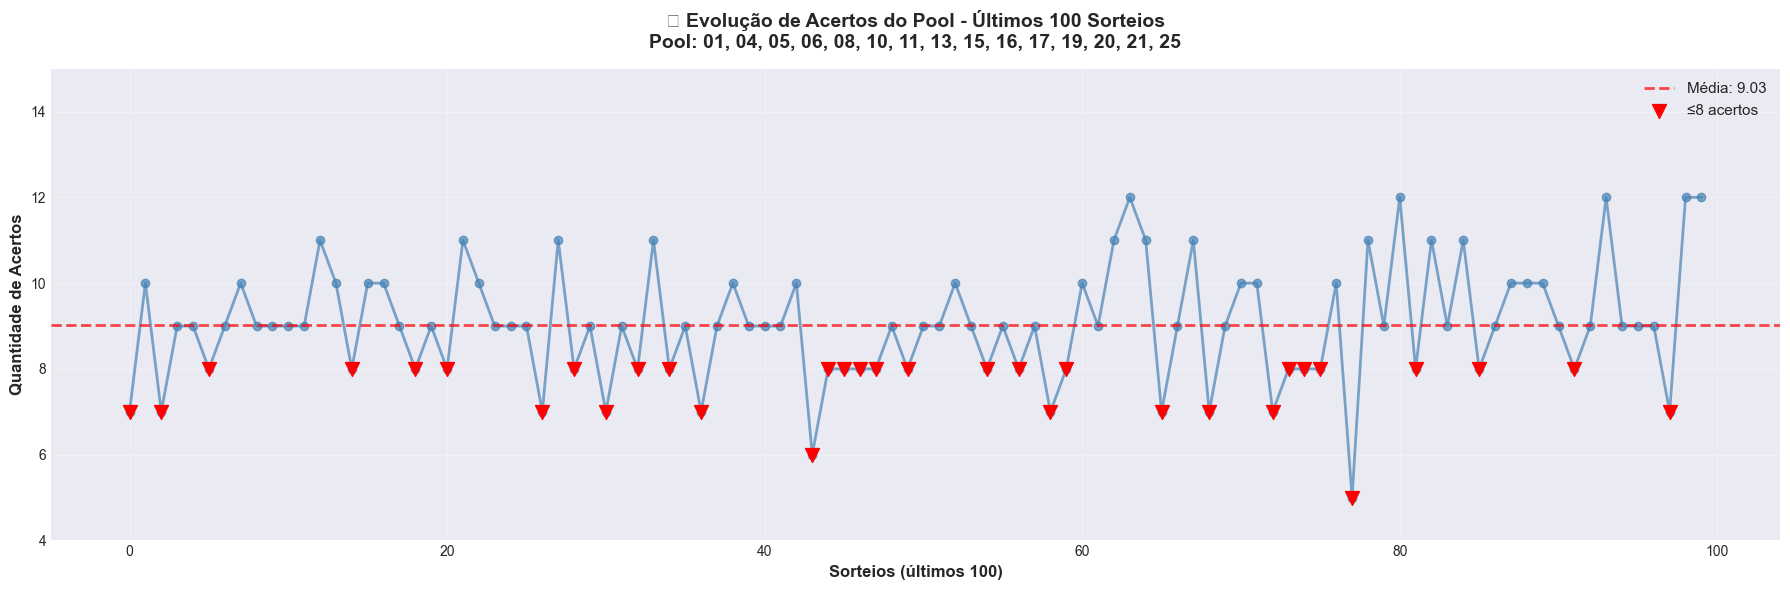

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\2412275036.py:168: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


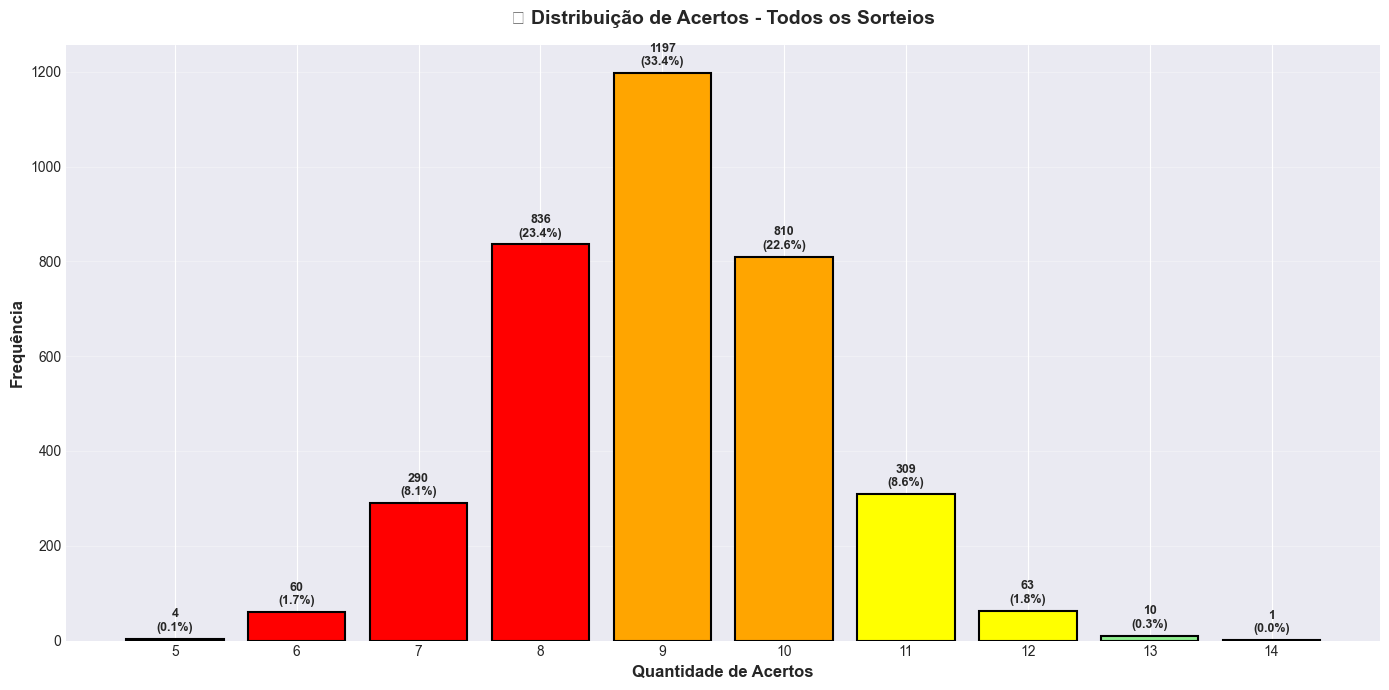

In [33]:
# Definir o pool
#pool = [1, 2, 4, 5, 6, 8, 9, 10, 15, 16, 17, 19, 20, 22, 24, 25]
#pool = [1,2,4,5,6,8,9,10,12,13,14,16,18,20,22,23,24,25]

#pool = [1,2,4,5,6,8,9,10,15,16,17,19,20,22,24,25]
pool = [1,4,5,6,8,10,11,13,15,16,17,19,20,21,25]
print(f"🎯 Pool selecionado ({len(pool)} números):")
print(f"   {', '.join([f'{n:02d}' for n in pool])}")
print(f"\n{'='*100}")

# Analisar todos os sorteios
resultados = []

for idx, row in df.iterrows():
    concurso = row['Concurso']
    data = row['Data Sorteio']
    numeros_sorteados = [row[f'Bola{i}'] for i in range(1, 16)]
    
    # Contar quantos números do pool foram sorteados
    acertos = len([n for n in numeros_sorteados if n in pool])
    numeros_acertados = sorted([n for n in numeros_sorteados if n in pool])
    
    resultados.append({
        'Concurso': concurso,
        'Data': data,
        'Acertos': acertos,
        'Numeros_Acertados': numeros_acertados
    })

# Criar DataFrame
df_acertos = pd.DataFrame(resultados)

# Mostrar últimos 30 sorteios
print(f"\n📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:")
print("="*100)
print(f"{'Concurso':<10} {'Data':<12} {'Acertos':<8} {'Números Acertados':<60}")
print("-"*100)

for _, row in df_acertos.nlargest(30, 'Concurso').iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    
    # Colorir baseado na quantidade de acertos
    if row['Acertos'] >= 13:
        emoji = '🟢'
    elif row['Acertos'] >= 11:
        emoji = '🟡'
    else:
        emoji = '🔴'
    
    print(f"{row['Concurso']:<10} {data_str:<12} {emoji} {row['Acertos']:<6} {numeros_str:<60}")

print("="*100)

# Estatísticas gerais
print(f"\n📈 ESTATÍSTICAS DE ACERTOS:")
print("="*100)
print(f"Total de sorteios analisados: {len(df_acertos):,}")
print(f"Acertos médios: {df_acertos['Acertos'].mean():.2f} números")
print(f"Máximo de acertos: {df_acertos['Acertos'].max()} números")
print(f"Mínimo de acertos: {df_acertos['Acertos'].min()} números")

# Frequência de cada número do pool
print(f"\n🔢 FREQUÊNCIA DE ACERTOS POR NÚMERO DO POOL:")
print("="*100)
freq_por_numero_pool = {}
for numero in pool:
    count = sum([numero in row['Numeros_Acertados'] for _, row in df_acertos.iterrows()])
    freq_por_numero_pool[numero] = count

# Ordenar por frequência (decrescente)
freq_ordenada = sorted(freq_por_numero_pool.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Número':<8} {'Vezes':<8} {'%':<8} {'Visualização':<50}")
print("-"*100)
for rank, (numero, freq) in enumerate(freq_ordenada, 1):
    percentual = (freq / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"{rank:<6} {numero:02d}       {freq:<8} {percentual:>5.2f}%   {barra}")
print("="*100)

# Distribuição de acertos
print(f"\n📊 DISTRIBUIÇÃO DE ACERTOS:")
distribuicao = df_acertos['Acertos'].value_counts().sort_index()
for acertos, quantidade in distribuicao.items():
    percentual = (quantidade / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"   {acertos:2d} acertos: {quantidade:4d} vezes ({percentual:5.2f}%) {barra}")

# Melhores e piores resultados
print(f"\n🏆 TOP 10 MELHORES RESULTADOS:")
melhores = df_acertos.nlargest(10, 'Acertos')
for idx, row in melhores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

print(f"\n💔 TOP 10 PIORES RESULTADOS:")
piores = df_acertos.nsmallest(10, 'Acertos')
for idx, row in piores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

# Gráfico de linha temporal
fig, ax = plt.subplots(figsize=(18, 6))

# Plotar últimos 100 sorteios
ultimos_100 = df_acertos.nlargest(100, 'Concurso').sort_values('Concurso')

ax.plot(range(len(ultimos_100)), ultimos_100['Acertos'], 
        marker='o', linewidth=2, markersize=6, color='steelblue', alpha=0.7)

# Linha de média
media_acertos = ultimos_100['Acertos'].mean()
ax.axhline(y=media_acertos, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {media_acertos:.2f}', alpha=0.7)

# Destacar acertos >= 13
acertos_altos = ultimos_100[ultimos_100['Acertos'] >= 13]
indices_altos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos >= 13]
if indices_altos:
    ax.scatter(indices_altos, acertos_altos['Acertos'], 
              color='green', s=150, zorder=5, label='13+ acertos', marker='*')

# Destacar acertos <= 8
acertos_baixos = ultimos_100[ultimos_100['Acertos'] <= 8]
indices_baixos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos <= 8]
if indices_baixos:
    ax.scatter(indices_baixos, acertos_baixos['Acertos'], 
              color='red', s=100, zorder=5, label='≤8 acertos', marker='v')

ax.set_xlabel('Sorteios (últimos 100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Evolução de Acertos do Pool - Últimos 100 Sorteios\nPool: {", ".join([f"{n:02d}" for n in pool])}', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(df_acertos['Acertos'].min() - 1, df_acertos['Acertos'].max() + 1)

plt.tight_layout()
plt.show()

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(14, 7))

distribuicao_valores = distribuicao.sort_index()
cores = ['red' if x <= 8 else 'orange' if x <= 10 else 'yellow' if x <= 12 
         else 'lightgreen' if x <= 13 else 'darkgreen' 
         for x in distribuicao_valores.index]

bars = ax.bar(distribuicao_valores.index, distribuicao_valores.values, 
              color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (acertos, quantidade) in enumerate(distribuicao_valores.items()):
    percentual = (quantidade / len(df_acertos)) * 100
    ax.text(acertos, quantidade + 10, f'{quantidade}\n({percentual:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribuição de Acertos - Todos os Sorteios', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(df_acertos['Acertos'].min(), df_acertos['Acertos'].max() + 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*100)

🎯 Pool selecionado (15 números):
   02, 03, 04, 05, 06, 07, 08, 10, 12, 15, 16, 17, 20, 22, 24


📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:
Concurso   Data         Acertos  Números Acertados                                           
----------------------------------------------------------------------------------------------------
3580       06/01/2026   🔴 8      04, 05, 06, 08, 12, 15, 16, 20                              
3579       05/01/2026   🔴 8      02, 03, 04, 08, 10, 15, 17, 20                              
3578       03/01/2026   🟡 11     02, 03, 04, 05, 06, 07, 10, 17, 20, 22, 24                  
3577       02/01/2026   🔴 10     02, 04, 05, 06, 08, 10, 12, 16, 20, 24                      
3576       01/01/2026   🔴 8      02, 03, 05, 07, 08, 10, 16, 22                              
3575       30/12/2025   🔴 10     02, 04, 05, 07, 08, 10, 12, 15, 17, 22                      
3574       29/12/2025   🔴 10     03, 04, 05, 06, 08, 12, 15, 16, 17, 20                      
3573     

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\3637770776.py:146: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


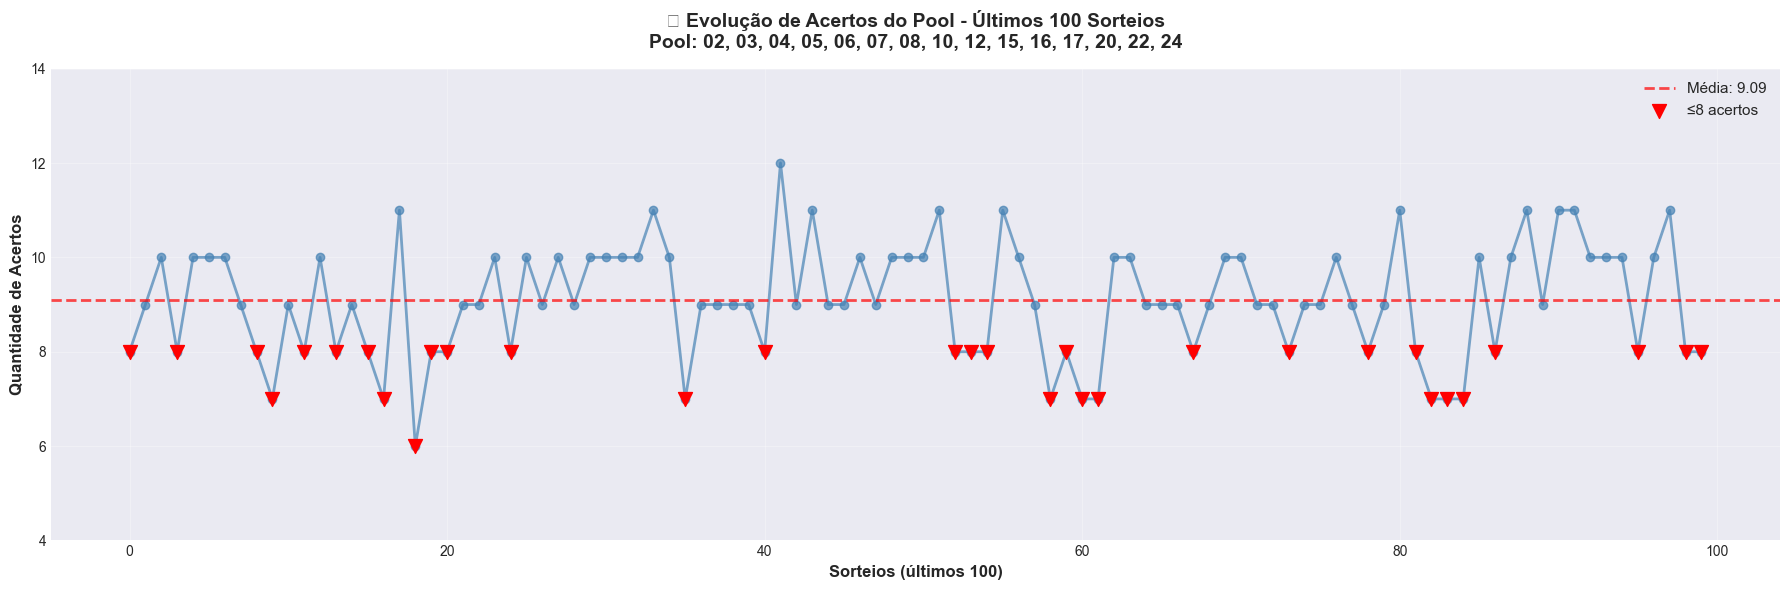

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_16668\3637770776.py:173: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


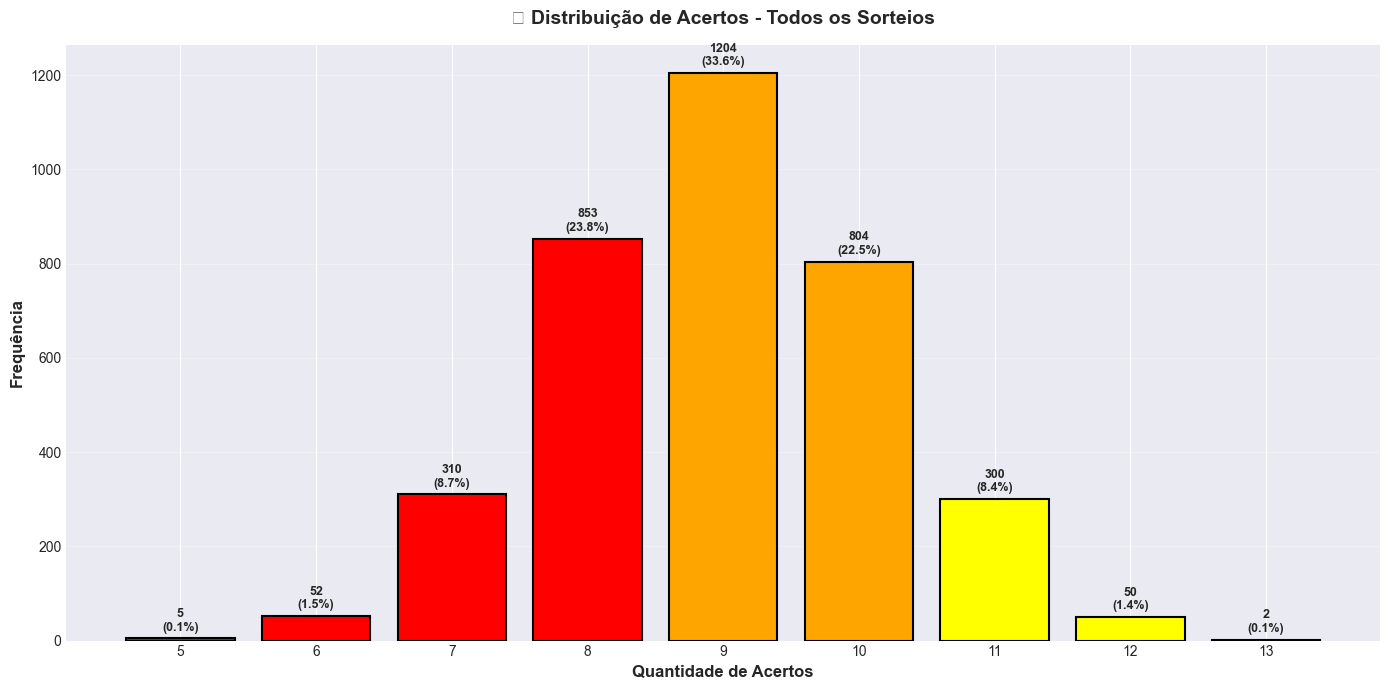

In [8]:
# Definir o pool
#pool = [1, 2, 4, 5, 6, 8, 9, 10, 15, 16, 17, 19, 20, 22, 24, 25]
#pool = [1,2,4,5,6,8,9,10,12,13,14,16,18,20,22,23,24,25]

#pool = [1,2,4,5,6,8,9,10,15,16,17,19,20,22,24,25]
#pool = [1,2,3,4,5,6,8,9,10,11,12,13,15,16,17,19,20,21,23,25]
#pool = [1,2,3,4,5,8,10,11,13,15,19,20,21,22,23,25]

#pool = [1,2,3,4,5,6,8,9,10,13,16,19,20,21,23,25]
pool = [2,3,4,5,6,7,8,10,12,15,16,17,20,22,24]

print(f"🎯 Pool selecionado ({len(pool)} números):")
print(f"   {', '.join([f'{n:02d}' for n in pool])}")
print(f"\n{'='*100}")

# Analisar todos os sorteios
resultados = []

for idx, row in df.iterrows():
    concurso = row['Concurso']
    data = row['Data Sorteio']
    numeros_sorteados = [row[f'Bola{i}'] for i in range(1, 16)]
    
    # Contar quantos números do pool foram sorteados
    acertos = len([n for n in numeros_sorteados if n in pool])
    numeros_acertados = sorted([n for n in numeros_sorteados if n in pool])
    
    resultados.append({
        'Concurso': concurso,
        'Data': data,
        'Acertos': acertos,
        'Numeros_Acertados': numeros_acertados
    })

# Criar DataFrame
df_acertos = pd.DataFrame(resultados)

# Mostrar últimos 30 sorteios
print(f"\n📊 ÚLTIMOS 30 SORTEIOS - ACERTOS DO POOL:")
print("="*100)
print(f"{'Concurso':<10} {'Data':<12} {'Acertos':<8} {'Números Acertados':<60}")
print("-"*100)

for _, row in df_acertos.nlargest(30, 'Concurso').iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    
    # Colorir baseado na quantidade de acertos
    if row['Acertos'] >= 13:
        emoji = '🟢'
    elif row['Acertos'] >= 11:
        emoji = '🟡'
    else:
        emoji = '🔴'
    
    print(f"{row['Concurso']:<10} {data_str:<12} {emoji} {row['Acertos']:<6} {numeros_str:<60}")

print("="*100)

# Estatísticas gerais
print(f"\n📈 ESTATÍSTICAS DE ACERTOS:")
print("="*100)
print(f"Total de sorteios analisados: {len(df_acertos):,}")
print(f"Acertos médios: {df_acertos['Acertos'].mean():.2f} números")
print(f"Máximo de acertos: {df_acertos['Acertos'].max()} números")
print(f"Mínimo de acertos: {df_acertos['Acertos'].min()} números")

# Frequência de cada número do pool
print(f"\n🔢 FREQUÊNCIA DE ACERTOS POR NÚMERO DO POOL:")
print("="*100)
freq_por_numero_pool = {}
for numero in pool:
    count = sum([numero in row['Numeros_Acertados'] for _, row in df_acertos.iterrows()])
    freq_por_numero_pool[numero] = count

# Ordenar por frequência (decrescente)
freq_ordenada = sorted(freq_por_numero_pool.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Número':<8} {'Vezes':<8} {'%':<8} {'Visualização':<50}")
print("-"*100)
for rank, (numero, freq) in enumerate(freq_ordenada, 1):
    percentual = (freq / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"{rank:<6} {numero:02d}       {freq:<8} {percentual:>5.2f}%   {barra}")
print("="*100)

# Distribuição de acertos
print(f"\n📊 DISTRIBUIÇÃO DE ACERTOS:")
distribuicao = df_acertos['Acertos'].value_counts().sort_index()
for acertos, quantidade in distribuicao.items():
    percentual = (quantidade / len(df_acertos)) * 100
    barra = '█' * int(percentual / 2) + '░' * (50 - int(percentual / 2))
    print(f"   {acertos:2d} acertos: {quantidade:4d} vezes ({percentual:5.2f}%) {barra}")

# Melhores e piores resultados
print(f"\n🏆 TOP 10 MELHORES RESULTADOS:")
melhores = df_acertos.nlargest(10, 'Acertos')
for idx, row in melhores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

print(f"\n💔 TOP 10 PIORES RESULTADOS:")
piores = df_acertos.nsmallest(10, 'Acertos')
for idx, row in piores.iterrows():
    data_str = row['Data'].strftime('%d/%m/%Y')
    numeros_str = ', '.join([f'{n:02d}' for n in row['Numeros_Acertados']])
    print(f"   Concurso {row['Concurso']} ({data_str}): {row['Acertos']} acertos → {numeros_str}")

# Gráfico de linha temporal
fig, ax = plt.subplots(figsize=(18, 6))

# Plotar últimos 100 sorteios
ultimos_100 = df_acertos.nlargest(100, 'Concurso').sort_values('Concurso')

ax.plot(range(len(ultimos_100)), ultimos_100['Acertos'], 
        marker='o', linewidth=2, markersize=6, color='steelblue', alpha=0.7)

# Linha de média
media_acertos = ultimos_100['Acertos'].mean()
ax.axhline(y=media_acertos, color='red', linestyle='--', linewidth=2, 
           label=f'Média: {media_acertos:.2f}', alpha=0.7)

# Destacar acertos >= 13
acertos_altos = ultimos_100[ultimos_100['Acertos'] >= 13]
indices_altos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos >= 13]
if indices_altos:
    ax.scatter(indices_altos, acertos_altos['Acertos'], 
              color='green', s=150, zorder=5, label='13+ acertos', marker='*')

# Destacar acertos <= 8
acertos_baixos = ultimos_100[ultimos_100['Acertos'] <= 8]
indices_baixos = [i for i, row in enumerate(ultimos_100.itertuples()) if row.Acertos <= 8]
if indices_baixos:
    ax.scatter(indices_baixos, acertos_baixos['Acertos'], 
              color='red', s=100, zorder=5, label='≤8 acertos', marker='v')

ax.set_xlabel('Sorteios (últimos 100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Evolução de Acertos do Pool - Últimos 100 Sorteios\nPool: {", ".join([f"{n:02d}" for n in pool])}', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(df_acertos['Acertos'].min() - 1, df_acertos['Acertos'].max() + 1)

plt.tight_layout()
plt.show()

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(14, 7))

distribuicao_valores = distribuicao.sort_index()
cores = ['red' if x <= 8 else 'orange' if x <= 10 else 'yellow' if x <= 12 
         else 'lightgreen' if x <= 13 else 'darkgreen' 
         for x in distribuicao_valores.index]

bars = ax.bar(distribuicao_valores.index, distribuicao_valores.values, 
              color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (acertos, quantidade) in enumerate(distribuicao_valores.items()):
    percentual = (quantidade / len(df_acertos)) * 100
    ax.text(acertos, quantidade + 10, f'{quantidade}\n({percentual:.1f}%)', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Quantidade de Acertos', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('📊 Distribuição de Acertos - Todos os Sorteios', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(df_acertos['Acertos'].min(), df_acertos['Acertos'].max() + 1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*100)

## 🔟 Melhores Combinações de 12 Números - Últimos 20 Jogos

Análise das combinações de 12 números (do pool de 16) que tiveram mais acertos nos últimos 20 sorteios.

🎯 Analisando combinações de 12 números do pool de 16 números
   Pool: 01, 02, 04, 05, 06, 08, 09, 10, 15, 16, 17, 19, 20, 22, 24, 25

📊 Últimos 20 sorteios:
   Concurso 3561 até 3580
   Data: 12/12/2025 até 06/01/2026

🔢 Total de combinações possíveis de 12 números: 1,820

⏳ Analisando todas as 1,820 combinações...
✅ Análise concluída!

🏆 TOP 20 MELHORES COMBINAÇÕES DE 12 NÚMEROS (por total de acertos nos últimos 20 jogos)
Rank   Total   Média   Max   Min   11+   Combinação                                                            
------------------------------------------------------------------------------------------------------------------------
1      166     8.30    10    5     0     01, 02, 04, 05, 08, 10, 15, 17, 19, 20, 22, 25
2      166     8.30    11    5     1     01, 02, 04, 05, 08, 10, 15, 17, 19, 20, 24, 25
3      166     8.30    11    6     2     01, 02, 04, 05, 06, 08, 10, 15, 17, 19, 20, 25
4      165     8.25    10    6     0     01, 02, 04, 05, 08, 10, 15, 19, 20,

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3217285697.py:132: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


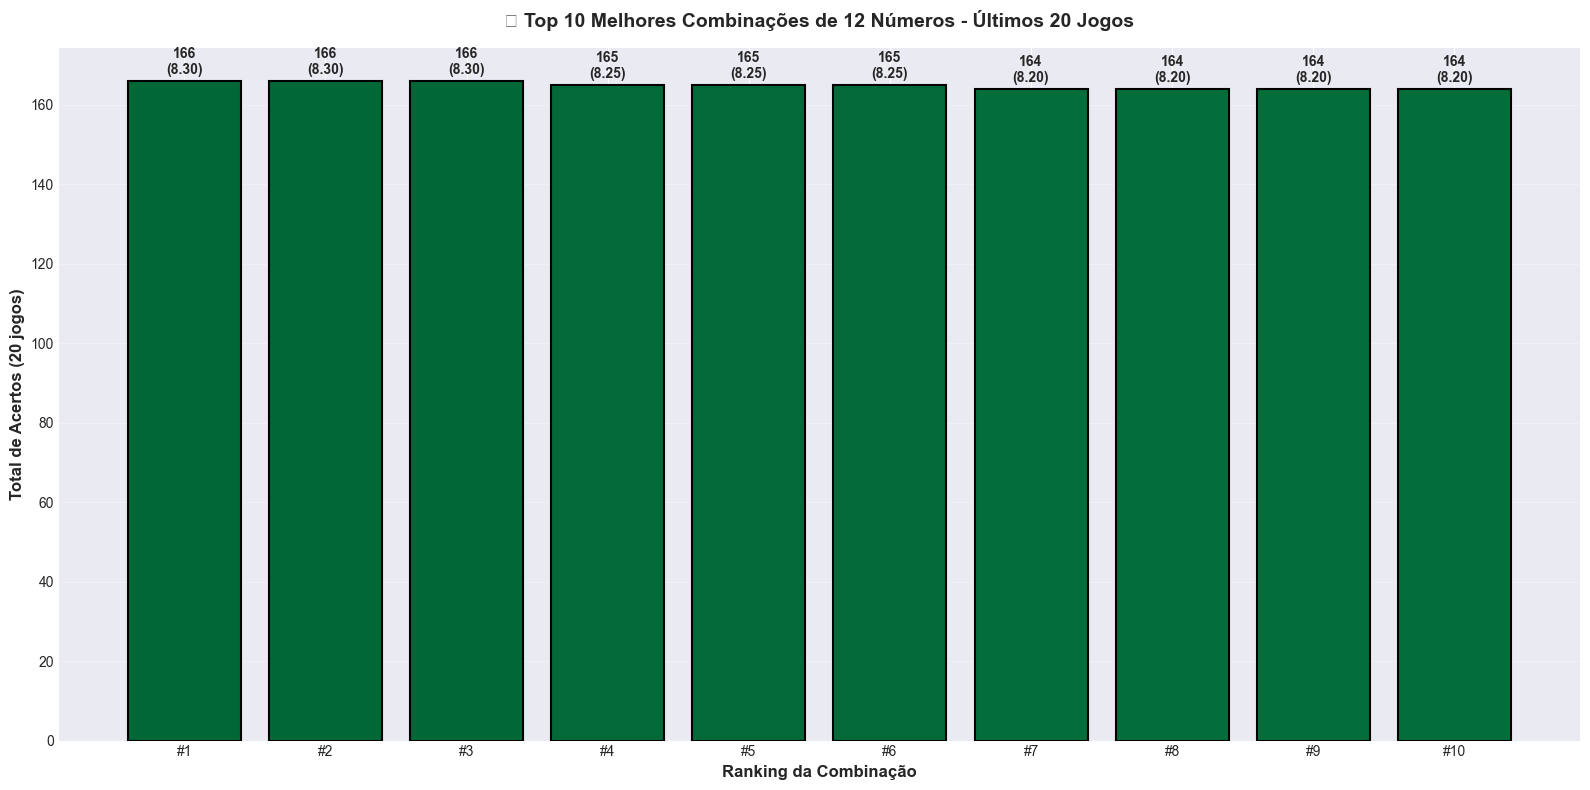

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3217285697.py:162: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


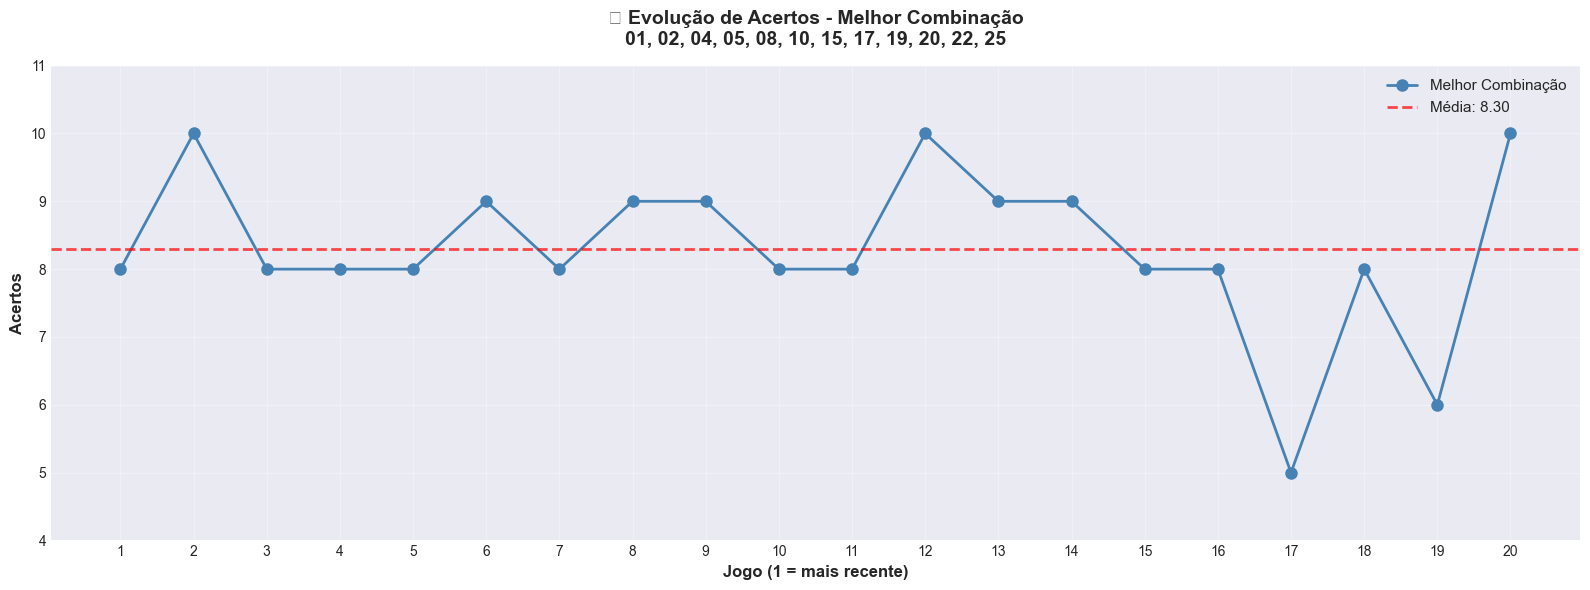


🔍 ANÁLISE: Números mais frequentes nas Top 10 combinações
Número   Presença   % das Top 10   
------------------------------------------------------------------------------------------------------------------------
01       10/10         100%          ██████████
02       10/10         100%          ██████████
04       10/10         100%          ██████████
05       10/10         100%          ██████████
08       10/10         100%          ██████████
10       10/10         100%          ██████████
20       10/10         100%          ██████████
25       10/10         100%          ██████████
15       8/10          80%          ████████░░
19       8/10          80%          ████████░░
17       7/10          70%          ███████░░░
22       6/10          60%          ██████░░░░
24       6/10          60%          ██████░░░░
06       5/10          50%          █████░░░░░


In [30]:
# Pool de 16 números
pool_16 = [1, 2, 4, 5, 6, 8, 9, 10, 15, 16, 17, 19, 20, 22, 24, 25]

print(f"🎯 Analisando combinações de 12 números do pool de {len(pool_16)} números")
print(f"   Pool: {', '.join([f'{n:02d}' for n in pool_16])}")

# Filtrar últimos 20 sorteios
ultimos_20_jogos = df.nlargest(20, 'Concurso')

print(f"\n📊 Últimos 20 sorteios:")
print(f"   Concurso {ultimos_20_jogos['Concurso'].min()} até {ultimos_20_jogos['Concurso'].max()}")
print(f"   Data: {ultimos_20_jogos['Data Sorteio'].min().strftime('%d/%m/%Y')} até {ultimos_20_jogos['Data Sorteio'].max().strftime('%d/%m/%Y')}")

# Calcular total de combinações possíveis
from math import comb
total_combinacoes = comb(len(pool_16), 12)
print(f"\n🔢 Total de combinações possíveis de 12 números: {total_combinacoes:,}")

# Analisar todas as combinações de 12 números
print(f"\n⏳ Analisando todas as {total_combinacoes:,} combinações...")

resultados_combinacoes = []

for combo in combinations(pool_16, 12):
    combo_set = set(combo)
    total_acertos = 0
    acertos_por_jogo = []
    
    # Para cada um dos últimos 20 jogos
    for idx, row in ultimos_20_jogos.iterrows():
        numeros_sorteados = set([row[f'Bola{i}'] for i in range(1, 16)])
        acertos_jogo = len(combo_set & numeros_sorteados)
        total_acertos += acertos_jogo
        acertos_por_jogo.append(acertos_jogo)
    
    # Calcular estatísticas
    media_acertos = total_acertos / 20
    max_acertos = max(acertos_por_jogo)
    min_acertos = min(acertos_por_jogo)
    
    # Contar quantas vezes teve 11+ acertos
    acertos_11_plus = sum([1 for a in acertos_por_jogo if a >= 11])
    
    resultados_combinacoes.append({
        'Combinacao': combo,
        'Total_Acertos': total_acertos,
        'Media_Acertos': media_acertos,
        'Max_Acertos': max_acertos,
        'Min_Acertos': min_acertos,
        'Acertos_11_Plus': acertos_11_plus,
        'Acertos_Por_Jogo': acertos_por_jogo
    })

# Criar DataFrame e ordenar por total de acertos
df_combinacoes = pd.DataFrame(resultados_combinacoes)
df_combinacoes = df_combinacoes.sort_values('Total_Acertos', ascending=False)

print(f"✅ Análise concluída!\n")

# Mostrar Top 20 melhores combinações
print("="*120)
print("🏆 TOP 20 MELHORES COMBINAÇÕES DE 12 NÚMEROS (por total de acertos nos últimos 20 jogos)")
print("="*120)
print(f"{'Rank':<6} {'Total':<7} {'Média':<7} {'Max':<5} {'Min':<5} {'11+':<5} {'Combinação':<70}")
print("-"*120)

for rank, (idx, row) in enumerate(df_combinacoes.head(20).iterrows(), 1):
    combo_str = ', '.join([f'{n:02d}' for n in row['Combinacao']])
    print(f"{rank:<6} {row['Total_Acertos']:<7} {row['Media_Acertos']:<7.2f} {row['Max_Acertos']:<5} {row['Min_Acertos']:<5} {row['Acertos_11_Plus']:<5} {combo_str}")

print("="*120)

# Detalhes da melhor combinação
print(f"\n🥇 MELHOR COMBINAÇÃO - Análise Detalhada:")
print("="*120)
melhor = df_combinacoes.iloc[0]
melhor_combo_str = ', '.join([f'{n:02d}' for n in melhor['Combinacao']])

print(f"Combinação: {melhor_combo_str}")
print(f"Total de acertos: {melhor['Total_Acertos']}")
print(f"Média por jogo: {melhor['Media_Acertos']:.2f} acertos")
print(f"Máximo: {melhor['Max_Acertos']} acertos")
print(f"Mínimo: {melhor['Min_Acertos']} acertos")
print(f"Jogos com 11+ acertos: {melhor['Acertos_11_Plus']} de 20")

print(f"\n📊 Acertos por jogo (últimos 20):")
for i, (idx, jogo) in enumerate(ultimos_20_jogos.iterrows(), 1):
    acertos = melhor['Acertos_Por_Jogo'][i-1]
    data_jogo = jogo['Data Sorteio'].strftime('%d/%m/%Y')
    emoji = '🟢' if acertos >= 11 else '🟡' if acertos >= 9 else '🔴'
    print(f"   Jogo {i:2d} - Concurso {jogo['Concurso']} ({data_jogo}): {emoji} {acertos:2d} acertos")

# Detalhes das Top 5 combinações
print(f"\n📋 TOP 5 COMBINAÇÕES - Detalhamento por Concurso:")
print("="*120)

for rank, (idx, combo_row) in enumerate(df_combinacoes.head(5).iterrows(), 1):
    combo_str = ', '.join([f'{n:02d}' for n in combo_row['Combinacao']])
    print(f"\n#{rank} - {combo_str}")
    print(f"    Total: {combo_row['Total_Acertos']} | Média: {combo_row['Media_Acertos']:.2f} | 11+: {combo_row['Acertos_11_Plus']}/20")
    print(f"    Jogos com 11+ acertos:")
    
    for i, (idx_jogo, jogo) in enumerate(ultimos_20_jogos.iterrows()):
        acertos = combo_row['Acertos_Por_Jogo'][i]
        if acertos >= 11:
            data_jogo = jogo['Data Sorteio'].strftime('%d/%m/%Y')
            print(f"       • Concurso {jogo['Concurso']} ({data_jogo}): {acertos} acertos")
    
print("="*120)

# Gráfico de barras - Top 10
fig, ax = plt.subplots(figsize=(16, 8))

top_10 = df_combinacoes.head(10)
labels = [f"#{i+1}" for i in range(len(top_10))]
valores = top_10['Total_Acertos'].values

cores = plt.cm.RdYlGn(valores / valores.max())
bars = ax.bar(labels, valores, color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (label, valor) in enumerate(zip(labels, valores)):
    ax.text(i, valor + 1, f'{valor}\n({top_10.iloc[i]["Media_Acertos"]:.2f})', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Ranking da Combinação', fontsize=12, fontweight='bold')
ax.set_ylabel('Total de Acertos (20 jogos)', fontsize=12, fontweight='bold')
ax.set_title('🏆 Top 10 Melhores Combinações de 12 Números - Últimos 20 Jogos', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de linha - Evolução da melhor combinação
fig, ax = plt.subplots(figsize=(16, 6))

jogos_indices = list(range(1, 21))
acertos_melhor = melhor['Acertos_Por_Jogo']

ax.plot(jogos_indices, acertos_melhor, marker='o', linewidth=2, 
        markersize=8, color='steelblue', label='Melhor Combinação')

# Linha de média
ax.axhline(y=melhor['Media_Acertos'], color='red', linestyle='--', 
           linewidth=2, label=f'Média: {melhor["Media_Acertos"]:.2f}', alpha=0.7)

# Destacar acertos >= 11
for i, acertos in enumerate(acertos_melhor):
    if acertos >= 11:
        ax.scatter(i+1, acertos, color='green', s=200, zorder=5, marker='*')

ax.set_xlabel('Jogo (1 = mais recente)', fontsize=12, fontweight='bold')
ax.set_ylabel('Acertos', fontsize=12, fontweight='bold')
ax.set_title(f'📈 Evolução de Acertos - Melhor Combinação\n{melhor_combo_str}', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(jogos_indices)
ax.set_ylim(min(acertos_melhor) - 1, max(acertos_melhor) + 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparação: números mais presentes nas top 10 combinações
print("\n" + "="*120)
print("🔍 ANÁLISE: Números mais frequentes nas Top 10 combinações")
print("="*120)

freq_numeros_top10 = {}
for idx, row in df_combinacoes.head(10).iterrows():
    for num in row['Combinacao']:
        freq_numeros_top10[num] = freq_numeros_top10.get(num, 0) + 1

freq_ordenada_top10 = sorted(freq_numeros_top10.items(), key=lambda x: x[1], reverse=True)

print(f"{'Número':<8} {'Presença':<10} {'% das Top 10':<15}")
print("-"*120)
for num, freq in freq_ordenada_top10:
    percentual = (freq / 10) * 100
    barra = '█' * freq + '░' * (10 - freq)
    print(f"{num:02d}       {freq}/10       {percentual:>5.0f}%          {barra}")

print("="*120)

## 1️⃣1️⃣ Combinações de 10 Números Mais Repetidas - Últimos 30 Jogos

Análise para identificar quais combinações de 10 números aparecem com mais frequência nos últimos 30 sorteios, gerando um novo pool base.

📊 Analisando últimos 30 sorteios:
   Concurso 3551 até 3580
   Data: 01/12/2025 até 06/01/2026

⏳ Gerando combinações de 10 números de cada sorteio...
   Total de combinações geradas: 90,090

🔍 Contando repetições...
   Combinações únicas: 88,954
   Combinações que se repetiram: 1,111

🏆 TOP 20 COMBINAÇÕES DE 10 NÚMEROS MAIS REPETIDAS (Últimos 30 jogos)
Rank   Vezes    %        Combinação                                                            
------------------------------------------------------------------------------------------------------------------------
1      3         10.0%   01, 04, 05, 06, 08, 15, 16, 20, 21, 25
2      3         10.0%   01, 04, 10, 11, 13, 17, 19, 20, 21, 23
3      3         10.0%   01, 04, 10, 11, 13, 17, 19, 20, 21, 25
4      3         10.0%   01, 04, 10, 11, 13, 17, 19, 20, 23, 25
5      3         10.0%   01, 04, 10, 11, 13, 17, 19, 21, 23, 25
6      3         10.0%   01, 04, 10, 11, 13, 17, 20, 21, 23, 25
7      3         10.0%   01, 04, 10, 11, 13

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\2179986874.py:124: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


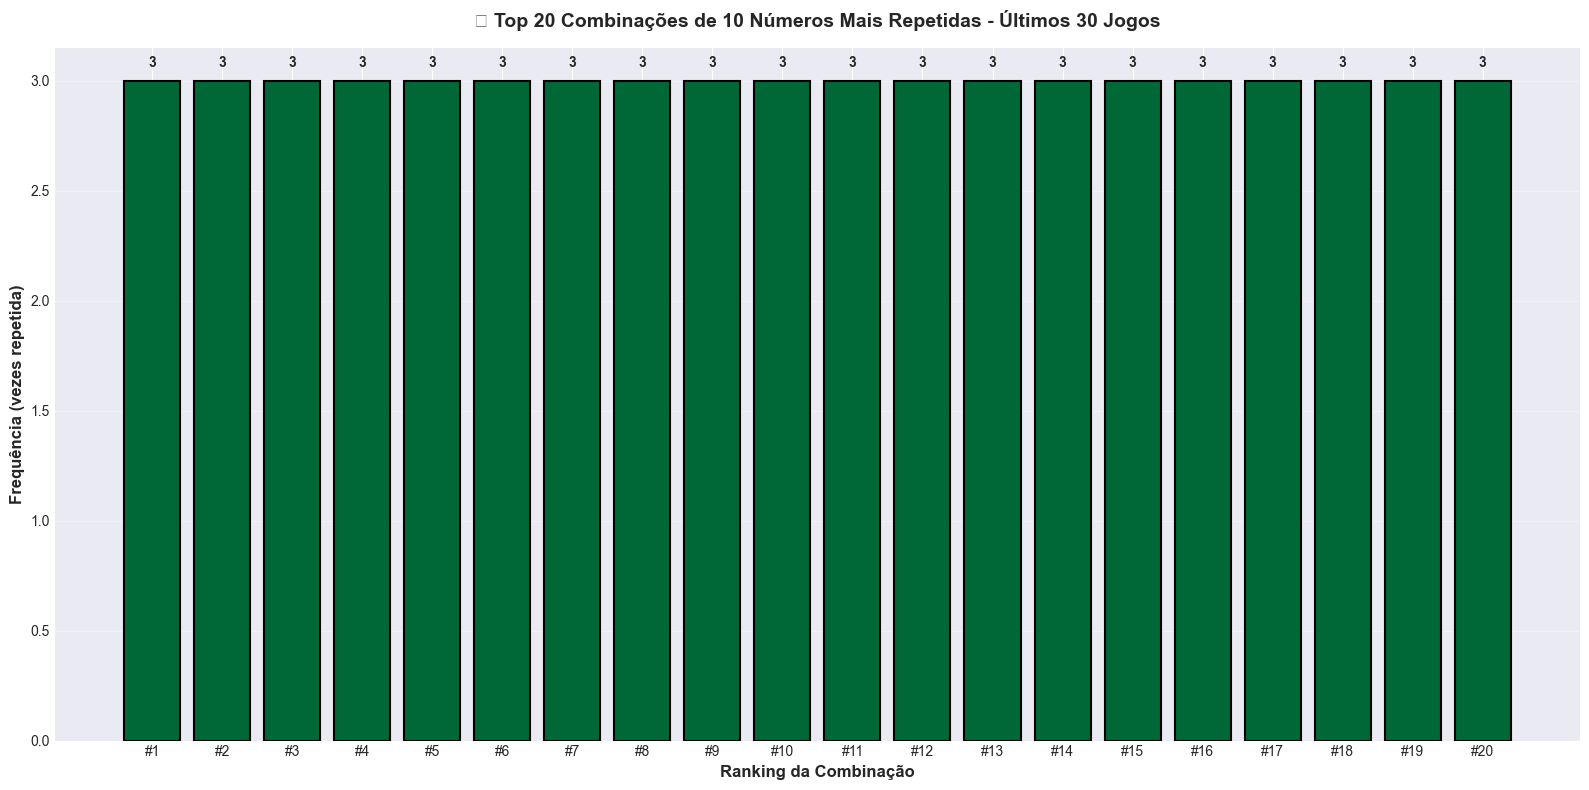

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\2179986874.py:152: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


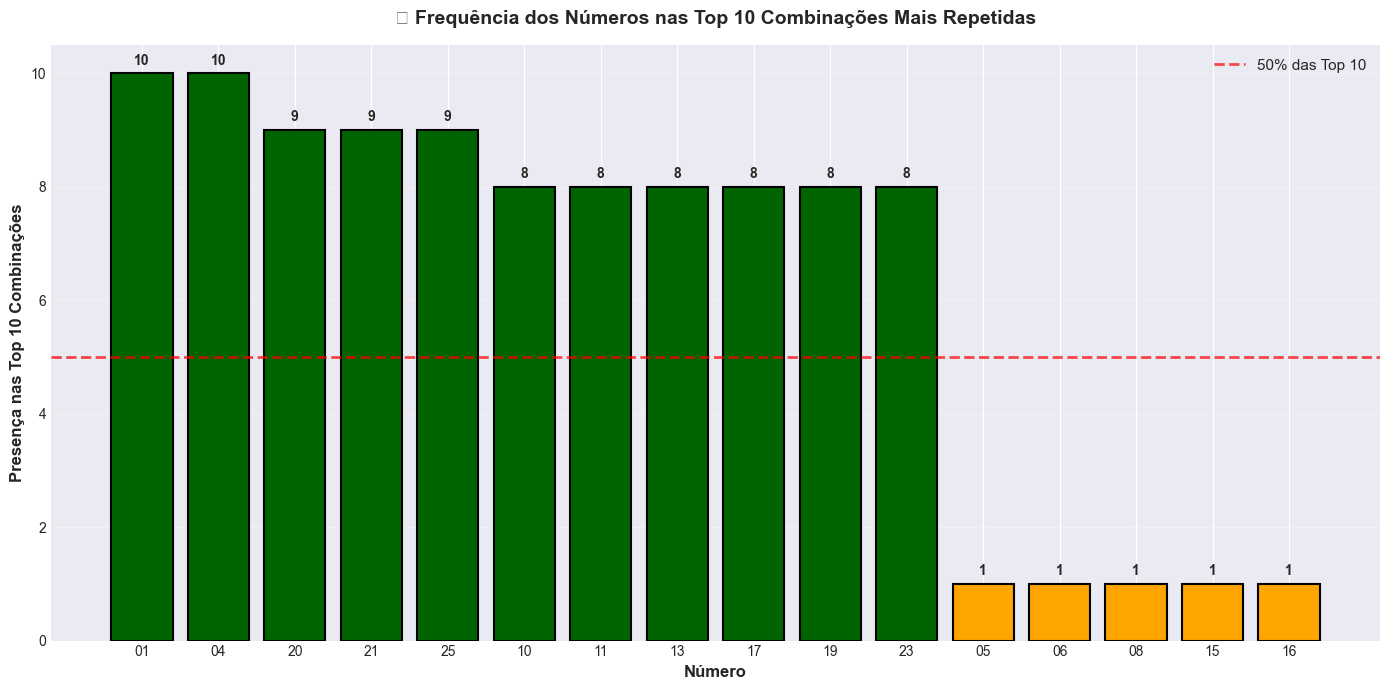


💡 RESUMO:
✅ Análise concluída dos últimos 30 sorteios
✅ Identificadas 1,111 combinações de 10 números que se repetiram
✅ Pool base sugerido com 11 números mais frequentes
✅ Use este pool base para gerar suas apostas!


In [32]:
from itertools import combinations
from collections import Counter

# Filtrar últimos 30 sorteios
ultimos_30 = df.nlargest(30, 'Concurso')

print(f"📊 Analisando últimos 30 sorteios:")
print(f"   Concurso {ultimos_30['Concurso'].min()} até {ultimos_30['Concurso'].max()}")
print(f"   Data: {ultimos_30['Data Sorteio'].min().strftime('%d/%m/%Y')} até {ultimos_30['Data Sorteio'].max().strftime('%d/%m/%Y')}")

# Extrair todas as combinações de 10 números dos últimos 30 jogos
print(f"\n⏳ Gerando combinações de 10 números de cada sorteio...")

todas_combinacoes_10 = []

for idx, row in ultimos_30.iterrows():
    # Pegar os 15 números do sorteio
    numeros = sorted([row[f'Bola{i}'] for i in range(1, 16)])
    
    # Gerar todas as combinações de 10 números deste sorteio
    combos_sorteio = list(combinations(numeros, 10))
    todas_combinacoes_10.extend(combos_sorteio)

print(f"   Total de combinações geradas: {len(todas_combinacoes_10):,}")

# Contar frequência de cada combinação de 10 números
print(f"\n🔍 Contando repetições...")
contador_combos = Counter(todas_combinacoes_10)

# Filtrar apenas as que aparecem mais de 1 vez
combos_repetidas = {combo: freq for combo, freq in contador_combos.items() if freq > 1}

print(f"   Combinações únicas: {len(contador_combos):,}")
print(f"   Combinações que se repetiram: {len(combos_repetidas):,}")

# Ordenar por frequência
combos_ordenadas = sorted(combos_repetidas.items(), key=lambda x: x[1], reverse=True)

# Mostrar Top 20 combinações mais repetidas
print("\n" + "="*120)
print("🏆 TOP 20 COMBINAÇÕES DE 10 NÚMEROS MAIS REPETIDAS (Últimos 30 jogos)")
print("="*120)
print(f"{'Rank':<6} {'Vezes':<8} {'%':<8} {'Combinação':<70}")
print("-"*120)

for rank, (combo, freq) in enumerate(combos_ordenadas[:20], 1):
    percentual = (freq / 30) * 100
    combo_str = ', '.join([f'{n:02d}' for n in combo])
    print(f"{rank:<6} {freq:<8} {percentual:>5.1f}%   {combo_str}")

print("="*120)

# Análise: números mais presentes nas combinações mais repetidas
print(f"\n🔍 NOVO POOL BASE - Números mais frequentes nas Top 10 combinações repetidas:")
print("="*120)

freq_numeros_repetidas = {}
for combo, freq in combos_ordenadas[:10]:
    for num in combo:
        freq_numeros_repetidas[num] = freq_numeros_repetidas.get(num, 0) + 1

freq_ordenada_numeros = sorted(freq_numeros_repetidas.items(), key=lambda x: x[1], reverse=True)

print(f"{'Número':<8} {'Presença':<12} {'% das Top 10':<15} {'Visualização'}")
print("-"*120)

for num, freq in freq_ordenada_numeros:
    percentual = (freq / 10) * 100
    barra = '█' * freq + '░' * (10 - freq)
    print(f"{num:02d}       {freq}/10         {percentual:>5.0f}%            {barra}")

# Gerar pool base com números que aparecem em 50% ou mais das top 10
pool_base = [num for num, freq in freq_ordenada_numeros if freq >= 5]
print(f"\n🎯 POOL BASE SUGERIDO (aparecem em 50%+ das Top 10):")
print(f"   {', '.join([f'{n:02d}' for n in pool_base])}")
print(f"   Total: {len(pool_base)} números")

# Análise detalhada das combinações mais repetidas
print(f"\n📋 DETALHAMENTO: Top 5 Combinações Mais Repetidas")
print("="*120)

for rank, (combo, freq) in enumerate(combos_ordenadas[:5], 1):
    combo_str = ', '.join([f'{n:02d}' for n in combo])
    print(f"\n#{rank} - Apareceu {freq} vezes ({freq/30*100:.1f}% dos jogos)")
    print(f"    Combinação: {combo_str}")
    print(f"    Concursos onde esta combinação de 10 números apareceu:")
    
    # Encontrar em quais concursos esta combinação apareceu
    combo_set = set(combo)
    concursos_encontrados = []
    
    for idx, row in ultimos_30.iterrows():
        numeros = set([row[f'Bola{i}'] for i in range(1, 16)])
        # Verificar se todos os 10 números da combo estão presentes
        if combo_set.issubset(numeros):
            data_jogo = row['Data Sorteio'].strftime('%d/%m/%Y')
            concursos_encontrados.append((row['Concurso'], data_jogo))
    
    for concurso, data in concursos_encontrados:
        print(f"       • Concurso {concurso} ({data})")

print("="*120)

# Gráfico de barras - Top 20
fig, ax = plt.subplots(figsize=(16, 8))

top_20_combos = combos_ordenadas[:20]
labels = [f"#{i+1}" for i in range(len(top_20_combos))]
valores = [freq for _, freq in top_20_combos]

cores = plt.cm.RdYlGn(np.array(valores) / max(valores))
bars = ax.bar(labels, valores, color=cores, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, valor in enumerate(valores):
    ax.text(i, valor + 0.05, str(valor), ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xlabel('Ranking da Combinação', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência (vezes repetida)', fontsize=12, fontweight='bold')
ax.set_title('🏆 Top 20 Combinações de 10 Números Mais Repetidas - Últimos 30 Jogos', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de frequência dos números
fig, ax = plt.subplots(figsize=(14, 7))

numeros = [num for num, _ in freq_ordenada_numeros]
frequencias = [freq for _, freq in freq_ordenada_numeros]

cores_numeros = ['darkgreen' if f >= 8 else 'lightgreen' if f >= 5 else 'orange' for f in frequencias]
bars = ax.bar([f'{n:02d}' for n in numeros], frequencias, color=cores_numeros, 
              edgecolor='black', linewidth=1.5)

# Adicionar valores
for i, (num, freq) in enumerate(zip(numeros, frequencias)):
    ax.text(i, freq + 0.1, str(freq), ha='center', va='bottom', fontweight='bold', fontsize=10)

# Linha em 5 (50%)
ax.axhline(y=5, color='red', linestyle='--', linewidth=2, 
           label='50% das Top 10', alpha=0.7)

ax.set_xlabel('Número', fontsize=12, fontweight='bold')
ax.set_ylabel('Presença nas Top 10 Combinações', fontsize=12, fontweight='bold')
ax.set_title('🔢 Frequência dos Números nas Top 10 Combinações Mais Repetidas', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 RESUMO:")
print("="*120)
print(f"✅ Análise concluída dos últimos 30 sorteios")
print(f"✅ Identificadas {len(combos_repetidas):,} combinações de 10 números que se repetiram")
print(f"✅ Pool base sugerido com {len(pool_base)} números mais frequentes")
print(f"✅ Use este pool base para gerar suas apostas!")
print("="*120)

## 1️⃣2️⃣ Cálculo de Apostas: Pool Base + Números Adicionais

Análise do número de apostas necessárias para cobrir todas as combinações possíveis.

🎯 ANÁLISE DE APOSTAS - POOL BASE + NÚMEROS ADICIONAIS

📋 POOL BASE (15 números):
   01, 02, 03, 04, 05, 08, 10, 13, 15, 19, 20, 21, 22, 23, 25

📋 NÚMEROS ADICIONAIS (6 números):
   06, 09, 11, 12, 16, 17

📊 TOTAL DE NÚMEROS DISPONÍVEIS: 21 números

💡 CENÁRIOS POSSÍVEIS

1️⃣ USAR APENAS O POOL BASE (15 números):
   • Números: 01, 02, 03, 04, 05, 08, 10, 13, 15, 19, 20, 21, 22, 23, 25
   • Total de apostas de 15 números: 1 aposta
   • Custo estimado: R$ 3,50 (1 aposta simples)

2️⃣ POOL BASE + 1 NÚMERO ADICIONAL (16 números):
   • Para cada escolha de 1 número dos 6 adicionais:
   • C(16,15) = 16 apostas de 15 números
   • Custo por combinação: R$ 56.00
   • Número de combinações possíveis: C(6,1) = 6
   • Custo total para testar todas: R$ 336.00

3️⃣ POOL BASE + 2 NÚMEROS ADICIONAIS (17 números):
   • Para cada escolha de 2 números dos 6 adicionais:
   • C(17,15) = 136 apostas de 15 números
   • Custo por combinação: R$ 476.00
   • Número de combinações possíveis: C(6,2) = 15
   • Custo

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3254646678.py:159: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3254646678.py:159: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()


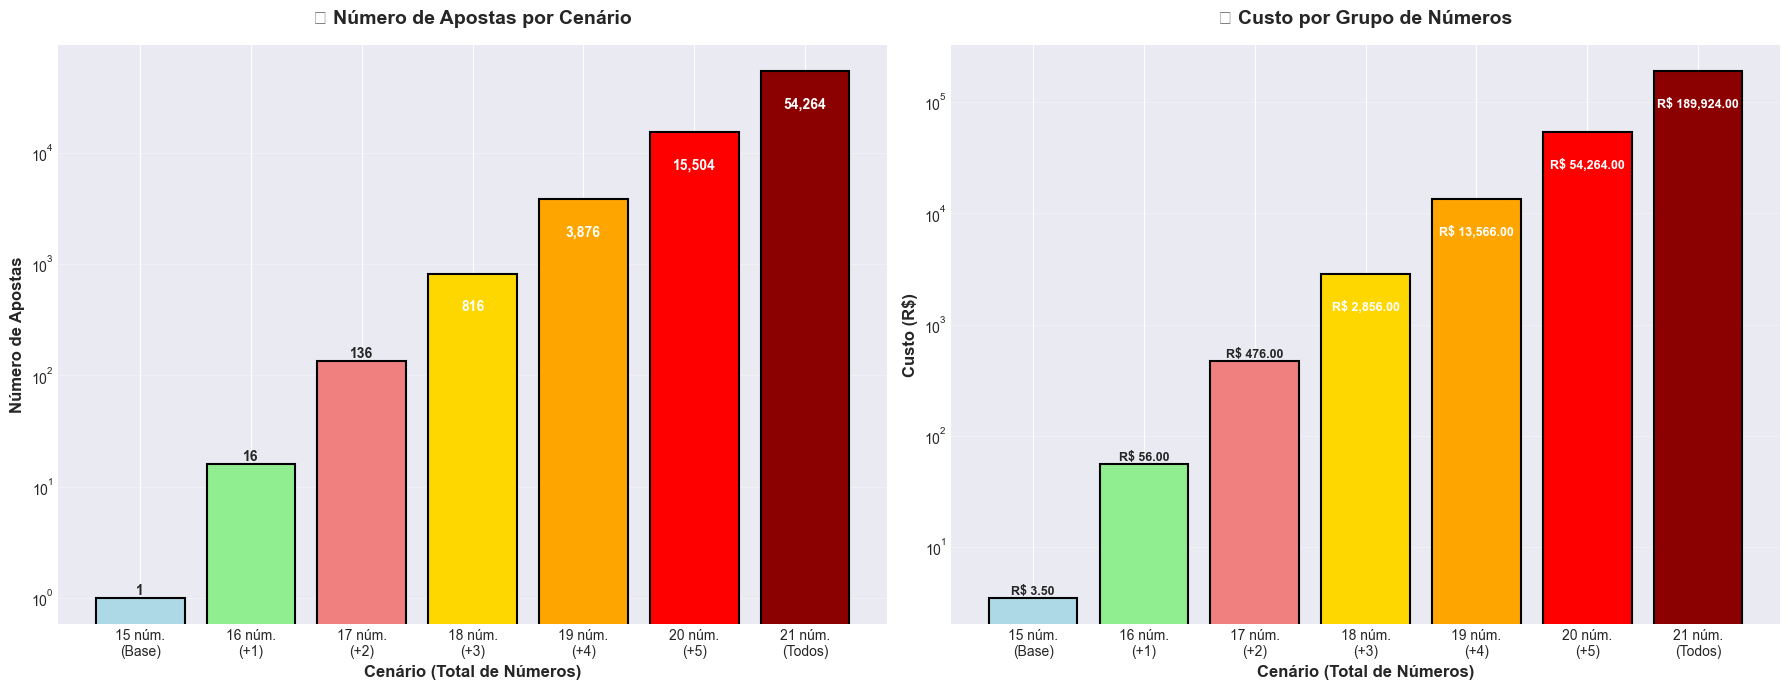


💡 RECOMENDAÇÃO:
✅ Para trabalhar com 18 números (Pool Base + 3 adicionais):
   • Escolha 1 das 20 combinações de 3 números adicionais
   • Gere 816 apostas de 15 números = R$ 2,856.00
   • OU teste todas as 20 combinações = 16,320 apostas = R$ 57,120.00


In [38]:
from itertools import combinations
from math import comb

# Pool base (15 números fixos)
pool_base = [1, 2, 3, 4, 5, 8, 10, 13, 15, 19, 20, 21, 22, 23, 25]

# Números adicionais (6 números)
numeros_adicionais = [6, 9, 11, 12, 16, 17]

print("="*120)
print("🎯 ANÁLISE DE APOSTAS - POOL BASE + NÚMEROS ADICIONAIS")
print("="*120)

print(f"\n📋 POOL BASE ({len(pool_base)} números):")
print(f"   {', '.join([f'{n:02d}' for n in pool_base])}")

print(f"\n📋 NÚMEROS ADICIONAIS ({len(numeros_adicionais)} números):")
print(f"   {', '.join([f'{n:02d}' for n in numeros_adicionais])}")

print(f"\n📊 TOTAL DE NÚMEROS DISPONÍVEIS: {len(pool_base) + len(numeros_adicionais)} números")

# Análise de diferentes cenários
print("\n" + "="*120)
print("💡 CENÁRIOS POSSÍVEIS")
print("="*120)

# Cenário 1: Apenas o pool base (15 números)
print(f"\n1️⃣ USAR APENAS O POOL BASE (15 números):")
print(f"   • Números: {', '.join([f'{n:02d}' for n in pool_base])}")
print(f"   • Total de apostas de 15 números: 1 aposta")
print(f"   • Custo estimado: R$ 3,50 (1 aposta simples)")

# Cenário 2: Pool base + 1 número adicional (16 números)
print(f"\n2️⃣ POOL BASE + 1 NÚMERO ADICIONAL (16 números):")
total_apostas_16 = comb(16, 15)
print(f"   • Para cada escolha de 1 número dos 6 adicionais:")
print(f"   • C(16,15) = {total_apostas_16:,} apostas de 15 números")
print(f"   • Custo por combinação: R$ {total_apostas_16 * 3.5:,.2f}")
print(f"   • Número de combinações possíveis: C(6,1) = 6")
print(f"   • Custo total para testar todas: R$ {6 * total_apostas_16 * 3.5:,.2f}")

# Cenário 3: Pool base + 2 números adicionais (17 números)
print(f"\n3️⃣ POOL BASE + 2 NÚMEROS ADICIONAIS (17 números):")
total_apostas_17 = comb(17, 15)
print(f"   • Para cada escolha de 2 números dos 6 adicionais:")
print(f"   • C(17,15) = {total_apostas_17:,} apostas de 15 números")
print(f"   • Custo por combinação: R$ {total_apostas_17 * 3.5:,.2f}")
print(f"   • Número de combinações possíveis: C(6,2) = 15")
print(f"   • Custo total para testar todas: R$ {15 * total_apostas_17 * 3.5:,.2f}")

# Cenário 4: Pool base + 3 números adicionais (18 números) - PRINCIPAL
print(f"\n4️⃣ POOL BASE + 3 NÚMEROS ADICIONAIS (18 números): ⭐ PRINCIPAL")
total_apostas_18 = comb(18, 15)
print(f"   • Para cada escolha de 3 números dos 6 adicionais:")
print(f"   • C(18,15) = C(18,3) = {total_apostas_18:,} apostas de 15 números")
print(f"   • Custo por combinação: R$ {total_apostas_18 * 3.5:,.2f}")
print(f"   • Número de combinações possíveis: C(6,3) = 20")
print(f"   • Custo total para testar todas: R$ {20 * total_apostas_18 * 3.5:,.2f}")

# Cenário 5: Pool base + 4 números adicionais (19 números)
print(f"\n5️⃣ POOL BASE + 4 NÚMEROS ADICIONAIS (19 números):")
total_apostas_19 = comb(19, 15)
print(f"   • Para cada escolha de 4 números dos 6 adicionais:")
print(f"   • C(19,15) = {total_apostas_19:,} apostas de 15 números")
print(f"   • Custo por combinação: R$ {total_apostas_19 * 3.5:,.2f}")
print(f"   • Número de combinações possíveis: C(6,4) = 15")
print(f"   • Custo total para testar todas: R$ {15 * total_apostas_19 * 3.5:,.2f}")

# Cenário 6: Pool base + 5 números adicionais (20 números)
print(f"\n6️⃣ POOL BASE + 5 NÚMEROS ADICIONAIS (20 números):")
total_apostas_20 = comb(20, 15)
print(f"   • Para cada escolha de 5 números dos 6 adicionais:")
print(f"   • C(20,15) = {total_apostas_20:,} apostas de 15 números")
print(f"   • Custo por combinação: R$ {total_apostas_20 * 3.5:,.2f}")
print(f"   • Número de combinações possíveis: C(6,5) = 6")
print(f"   • Custo total para testar todas: R$ {6 * total_apostas_20 * 3.5:,.2f}")

# Cenário 7: Todos os números (21 números)
print(f"\n7️⃣ USAR TODOS OS NÚMEROS (21 números):")
total_apostas_21 = comb(21, 15)
print(f"   • C(21,15) = {total_apostas_21:,} apostas de 15 números")
print(f"   • Custo total: R$ {total_apostas_21 * 3.5:,.2f}")

# Detalhamento do cenário 4 (18 números)
print("\n" + "="*120)
print("🎯 DETALHAMENTO: POOL BASE + 3 NÚMEROS ADICIONAIS (18 números)")
print("="*120)

print(f"\nCombinações possíveis de 3 números dos 6 adicionais:")
print(f"{'-'*120}")

todas_combos_3 = list(combinations(numeros_adicionais, 3))
for i, combo in enumerate(todas_combos_3, 1):
    pool_completo = sorted(pool_base + list(combo))
    pool_str = ', '.join([f'{n:02d}' for n in pool_completo])
    combo_str = ', '.join([f'{n:02d}' for n in combo])
    print(f"{i:2d}. Adicionar [{combo_str}] → Pool de 18: [{pool_str}]")

print(f"\n📊 RESUMO:")
print(f"   • Total de combinações: {len(todas_combos_3)} grupos diferentes de 18 números")
print(f"   • Apostas por grupo: {total_apostas_18:,} apostas de 15 números")
print(f"   • Total de apostas (todos os grupos): {len(todas_combos_3) * total_apostas_18:,}")
print(f"   • Custo total: R$ {len(todas_combos_3) * total_apostas_18 * 3.5:,.2f}")

# Gráfico de comparação
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Número de apostas por cenário
cenarios = ['15 núm.\n(Base)', '16 núm.\n(+1)', '17 núm.\n(+2)', 
            '18 núm.\n(+3)', '19 núm.\n(+4)', '20 núm.\n(+5)', '21 núm.\n(Todos)']
apostas = [1, total_apostas_16, total_apostas_17, total_apostas_18, 
           total_apostas_19, total_apostas_20, total_apostas_21]

cores_barras = ['lightblue', 'lightgreen', 'lightcoral', 'gold', 'orange', 'red', 'darkred']
bars1 = ax1.bar(cenarios, apostas, color=cores_barras, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (bar, valor) in enumerate(zip(bars1, apostas)):
    height = bar.get_height()
    if i <= 2:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{valor:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    else:
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{valor:,}', ha='center', va='center', fontweight='bold', 
                fontsize=10, color='white')

ax1.set_ylabel('Número de Apostas', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cenário (Total de Números)', fontsize=12, fontweight='bold')
ax1.set_title('📊 Número de Apostas por Cenário', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)
ax1.set_yscale('log')

# Gráfico 2: Custo por cenário (1 grupo)
custos_grupo = [val * 3.5 for val in apostas]

bars2 = ax2.bar(cenarios, custos_grupo, color=cores_barras, edgecolor='black', linewidth=1.5)

# Adicionar valores nas barras
for i, (bar, valor) in enumerate(zip(bars2, custos_grupo)):
    height = bar.get_height()
    if i <= 2:
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'R$ {valor:,.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2., height/2,
                f'R$ {valor:,.2f}', ha='center', va='center', fontweight='bold', 
                fontsize=9, color='white')

ax2.set_ylabel('Custo (R$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cenário (Total de Números)', fontsize=12, fontweight='bold')
ax2.set_title('💰 Custo por Grupo de Números', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("💡 RECOMENDAÇÃO:")
print("="*120)
print(f"✅ Para trabalhar com 18 números (Pool Base + 3 adicionais):")
print(f"   • Escolha 1 das {len(todas_combos_3)} combinações de 3 números adicionais")
print(f"   • Gere {total_apostas_18:,} apostas de 15 números = R$ {total_apostas_18 * 3.5:,.2f}")
print(f"   • OU teste todas as {len(todas_combos_3)} combinações = {len(todas_combos_3) * total_apostas_18:,} apostas = R$ {len(todas_combos_3) * total_apostas_18 * 3.5:,.2f}")
print("="*120)

## ❓ O que as 816 apostas cobrem?

Explicação detalhada sobre a cobertura das apostas de 18 números.

In [39]:
from itertools import combinations

print("="*120)
print("🔍 ENTENDENDO AS 816 APOSTAS DE 18 NÚMEROS")
print("="*120)

# Exemplo prático com os 18 números
pool_exemplo = [1, 2, 3, 4, 5, 6, 8, 9, 10, 13, 15, 16, 19, 20, 21, 22, 23, 25]

print(f"\n📋 POOL DE 18 NÚMEROS:")
print(f"   {', '.join([f'{n:02d}' for n in pool_exemplo])}")

print(f"\n💡 O QUE AS 816 APOSTAS COBREM:")
print("-"*120)

print(f"\n✅ COBERTURA TOTAL:")
print(f"   • As 816 apostas representam TODAS as combinações possíveis de escolher 15 números dentre os 18")
print(f"   • Fórmula: C(18, 15) = C(18, 3) = 816 combinações únicas")
print(f"   • Isso significa que você está jogando com TODOS os grupos possíveis de 15 números")

print(f"\n🎯 GARANTIA:")
print(f"   • SE os 15 números sorteados pela Lotofácil estiverem DENTRO desses 18 números...")
print(f"   • ...você GARANTE que terá pelo menos UMA aposta com os 15 números certos!")
print(f"   • Ou seja: você FECHA todas as possibilidades dentro desse universo de 18 números")

print(f"\n⚠️ IMPORTANTE:")
print(f"   • Você NÃO ganha sempre - apenas SE o resultado real estiver nos seus 18 números")
print(f"   • É como uma rede que captura TODAS as combinações possíveis desse grupo")
print(f"   • Reduz o universo de 25 números para 18, mas cobre 100% das possibilidades dentro deles")

print("\n" + "="*120)
print("📊 EXEMPLO VISUAL - PRIMEIRAS 10 APOSTAS DAS 816")
print("="*120)

# Gerar as 816 apostas
todas_apostas = list(combinations(pool_exemplo, 15))

print(f"\nTotal de apostas geradas: {len(todas_apostas):,}")
print(f"\nMostrando as primeiras 10 apostas:")
print(f"{'-'*120}")
print(f"{'#':<5} {'Aposta (15 números)':<80}")
print(f"{'-'*120}")

for i, aposta in enumerate(todas_apostas[:10], 1):
    aposta_str = ', '.join([f'{n:02d}' for n in aposta])
    print(f"{i:<5} {aposta_str}")

print(f"{'-'*120}")
print(f"... (continua até a aposta 816)")

# Demonstração com exemplo concreto
print("\n" + "="*120)
print("🎲 SIMULAÇÃO: E SE O RESULTADO FOSSE...")
print("="*120)

# Simular um resultado hipotético dentro dos 18 números
resultado_simulado = [1, 2, 4, 5, 8, 9, 10, 13, 15, 19, 20, 21, 22, 23, 25]
print(f"\nResultado sorteado: {', '.join([f'{n:02d}' for n in resultado_simulado])}")

# Verificar se está dentro dos 18
resultado_set = set(resultado_simulado)
pool_set = set(pool_exemplo)

if resultado_set.issubset(pool_set):
    print(f"✅ Todos os 15 números estão dentro do pool de 18!")
    print(f"✅ VOCÊ GANHOU! Uma das suas 816 apostas tem exatamente esses 15 números!")
    
    # Encontrar qual aposta ganhou
    for i, aposta in enumerate(todas_apostas, 1):
        if set(aposta) == resultado_set:
            print(f"\n🏆 A aposta vencedora é a #{i}: {', '.join([f'{n:02d}' for n in aposta])}")
            break
else:
    numeros_fora = resultado_set - pool_set
    print(f"❌ Alguns números não estão no pool: {', '.join([f'{n:02d}' for n in sorted(numeros_fora)])}")
    print(f"❌ Nenhuma das 816 apostas ganhou os 15 pontos")

# Análise de cobertura
print("\n" + "="*120)
print("📈 ANÁLISE DE COBERTURA COMPLETA")
print("="*120)

print(f"\n🔢 MATEMÁTICA:")
print(f"   • Universo total da Lotofácil: 25 números")
print(f"   • Todas as combinações possíveis de 15 números: C(25,15) = 3.268.760 apostas")
print(f"   • Seu pool reduzido: 18 números")
print(f"   • Combinações dentro do seu pool: C(18,15) = 816 apostas")
print(f"   • Percentual de cobertura do universo total: {(816/3268760)*100:.4f}%")

print(f"\n💰 CUSTO vs COBERTURA:")
print(f"   • Custo para fechar TODO o universo (25 números): R$ {3268760 * 3.5:,.2f}")
print(f"   • Custo para fechar seu pool (18 números): R$ {816 * 3.5:,.2f}")
print(f"   • Economia: R$ {(3268760 - 816) * 3.5:,.2f}")
print(f"   • Você paga apenas {(816/3268760)*100:.4f}% do custo total para cobrir seus 18 números escolhidos")

print(f"\n🎯 ESTRATÉGIA:")
print(f"   • A chave está em escolher BEM os 18 números (daí a análise de tendências)")
print(f"   • Se seus 18 números forem bem escolhidos, você tem alta chance de acerto")
print(f"   • As 816 apostas garantem que você não perde NENHUMA combinação possível desses 18")

print("\n" + "="*120)
print("💡 RESUMO FINAL")
print("="*120)
print(f"✅ 816 apostas = FECHAMENTO COMPLETO de um pool de 18 números")
print(f"✅ Se acertar o pool, GARANTE pelo menos 1 aposta com 15 pontos")
print(f"✅ Também terá várias apostas com 14, 13, 12 pontos (prêmios menores)")
print(f"✅ Custo: R$ {816 * 3.5:,.2f} por grupo de 18 números")
print("="*120)

🔍 ENTENDENDO AS 816 APOSTAS DE 18 NÚMEROS

📋 POOL DE 18 NÚMEROS:
   01, 02, 03, 04, 05, 06, 08, 09, 10, 13, 15, 16, 19, 20, 21, 22, 23, 25

💡 O QUE AS 816 APOSTAS COBREM:
------------------------------------------------------------------------------------------------------------------------

✅ COBERTURA TOTAL:
   • As 816 apostas representam TODAS as combinações possíveis de escolher 15 números dentre os 18
   • Fórmula: C(18, 15) = C(18, 3) = 816 combinações únicas
   • Isso significa que você está jogando com TODOS os grupos possíveis de 15 números

🎯 GARANTIA:
   • SE os 15 números sorteados pela Lotofácil estiverem DENTRO desses 18 números...
   • ...você GARANTE que terá pelo menos UMA aposta com os 15 números certos!
   • Ou seja: você FECHA todas as possibilidades dentro desse universo de 18 números

⚠️ IMPORTANTE:
   • Você NÃO ganha sempre - apenas SE o resultado real estiver nos seus 18 números
   • É como uma rede que captura TODAS as combinações possíveis desse grupo
   • R

## 1️⃣3️⃣ Combinações de 18 números: Pool Base (15) + Complemento (6)

Cálculo de quantas combinações são necessárias para cobrir todos os grupos de 18 números.

🎯 COMBINAÇÕES DE 18 NÚMEROS: POOL BASE (15) + COMPLEMENTO (6)

📋 POOL BASE (15 números fixos):
   01, 02, 03, 04, 05, 08, 10, 13, 15, 19, 20, 21, 22, 23, 25

📋 NÚMEROS DO COMPLEMENTO (6 números):
   06, 09, 11, 12, 16, 17

📊 TOTAL DE NÚMEROS DISPONÍVEIS: 21 números

🔢 CÁLCULO DE COMBINAÇÕES

🎲 CENÁRIO: Combinar grupos de 18 números
   • Pool base: 15 números (sempre presentes)
   • Complemento: 6 números disponíveis
   • Objetivo: Formar grupos de 18 números
   • Lógica: 15 (fixos) + 3 (escolhidos dos 6) = 18 números por grupo

💡 CÁLCULO:
   • Como 15 números são FIXOS, precisamos escolher 3 números dos 6 do complemento
   • Fórmula: C(6, 3) = 20 combinações

✅ RESPOSTA:
   🎯 São necessárias 20 combinações de 18 números!

📋 TODAS AS 20 COMBINAÇÕES DE 18 NÚMEROS

#    3 Números do Complemento       Pool Completo de 18 Números                                                     
--------------------------------------------------------------------------------------------------------------

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3236531293.py:134: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_24780\3236531293.py:134: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


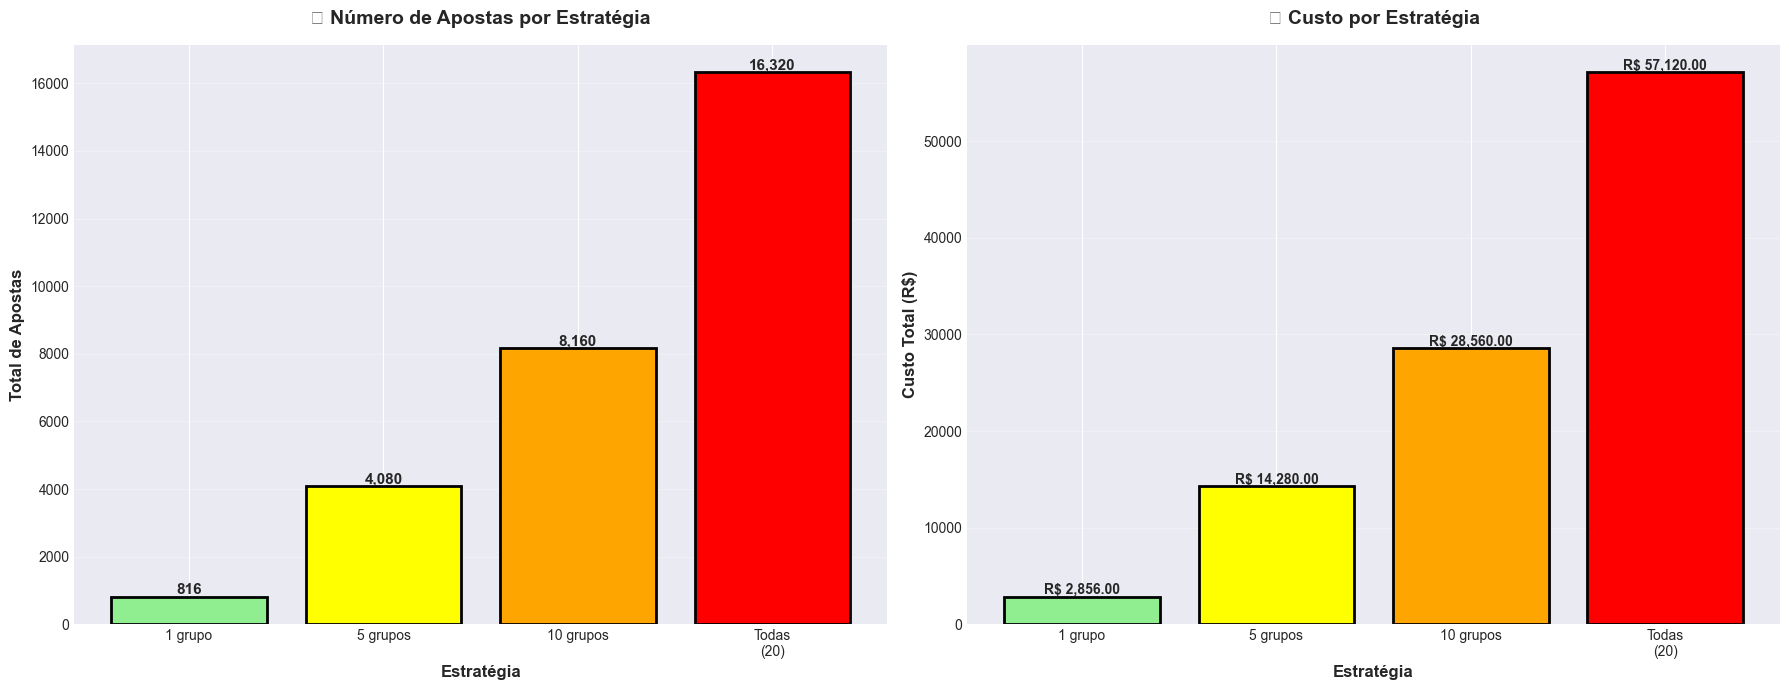


💡 RESUMO FINAL
✅ Total de combinações de 18 números: 20
✅ Cada combinação requer 816 apostas (R$ 2,856.00)
✅ Escolha quantas combinações jogar de acordo com seu orçamento
✅ Quanto mais combinações, maior a cobertura do universo de possibilidades


In [40]:
from itertools import combinations
from math import comb

# Definir os números
pool_base_15 = [1, 2, 3, 4, 5, 8, 10, 13, 15, 19, 20, 21, 22, 23, 25]
complemento_6 = [6, 9, 11, 12, 16, 17]

print("="*120)
print("🎯 COMBINAÇÕES DE 18 NÚMEROS: POOL BASE (15) + COMPLEMENTO (6)")
print("="*120)

print(f"\n📋 POOL BASE ({len(pool_base_15)} números fixos):")
print(f"   {', '.join([f'{n:02d}' for n in pool_base_15])}")

print(f"\n📋 NÚMEROS DO COMPLEMENTO ({len(complemento_6)} números):")
print(f"   {', '.join([f'{n:02d}' for n in complemento_6])}")

print(f"\n📊 TOTAL DE NÚMEROS DISPONÍVEIS: {len(pool_base_15) + len(complemento_6)} números")

# Cálculo principal
print("\n" + "="*120)
print("🔢 CÁLCULO DE COMBINAÇÕES")
print("="*120)

print(f"\n🎲 CENÁRIO: Combinar grupos de 18 números")
print(f"   • Pool base: 15 números (sempre presentes)")
print(f"   • Complemento: 6 números disponíveis")
print(f"   • Objetivo: Formar grupos de 18 números")
print(f"   • Lógica: 15 (fixos) + 3 (escolhidos dos 6) = 18 números por grupo")

print(f"\n💡 CÁLCULO:")
total_combinacoes_18 = comb(6, 3)
print(f"   • Como 15 números são FIXOS, precisamos escolher 3 números dos 6 do complemento")
print(f"   • Fórmula: C(6, 3) = {total_combinacoes_18} combinações")

print(f"\n✅ RESPOSTA:")
print(f"   🎯 São necessárias {total_combinacoes_18} combinações de 18 números!")

# Mostrar todas as combinações
print("\n" + "="*120)
print(f"📋 TODAS AS {total_combinacoes_18} COMBINAÇÕES DE 18 NÚMEROS")
print("="*120)

todas_combos_18 = list(combinations(complemento_6, 3))

print(f"\n{'#':<4} {'3 Números do Complemento':<30} {'Pool Completo de 18 Números':<80}")
print("-"*120)

for i, combo_3 in enumerate(todas_combos_18, 1):
    # Criar o pool completo de 18
    pool_18 = sorted(pool_base_15 + list(combo_3))
    combo_str = ', '.join([f'{n:02d}' for n in combo_3])
    pool_str = ', '.join([f'{n:02d}' for n in pool_18])
    print(f"{i:<4} [{combo_str}]                       {pool_str}")

# Calcular apostas necessárias para cada grupo
print("\n" + "="*120)
print("💰 ANÁLISE DE CUSTOS")
print("="*120)

apostas_por_grupo = comb(18, 15)
print(f"\n📊 Para cada grupo de 18 números:")
print(f"   • Apostas necessárias para fechar: C(18,15) = {apostas_por_grupo:,}")
print(f"   • Custo por grupo: R$ {apostas_por_grupo * 3.5:,.2f}")

print(f"\n📊 Para todas as {total_combinacoes_18} combinações:")
print(f"   • Total de apostas: {total_combinacoes_18} × {apostas_por_grupo:,} = {total_combinacoes_18 * apostas_por_grupo:,}")
print(f"   • Custo total: R$ {total_combinacoes_18 * apostas_por_grupo * 3.5:,.2f}")

# Estratégias diferentes
print("\n" + "="*120)
print("🎯 ESTRATÉGIAS DE JOGO")
print("="*120)

print(f"\n1️⃣ ESTRATÉGIA CONSERVADORA - Jogar 1 grupo de 18:")
print(f"   • Escolher 1 das {total_combinacoes_18} combinações acima")
print(f"   • Apostas: {apostas_por_grupo:,}")
print(f"   • Custo: R$ {apostas_por_grupo * 3.5:,.2f}")

print(f"\n2️⃣ ESTRATÉGIA MODERADA - Jogar 5 grupos de 18:")
print(f"   • Escolher 5 das {total_combinacoes_18} combinações")
print(f"   • Apostas: 5 × {apostas_por_grupo:,} = {5 * apostas_por_grupo:,}")
print(f"   • Custo: R$ {5 * apostas_por_grupo * 3.5:,.2f}")

print(f"\n3️⃣ ESTRATÉGIA AGRESSIVA - Jogar 10 grupos de 18:")
print(f"   • Escolher 10 das {total_combinacoes_18} combinações")
print(f"   • Apostas: 10 × {apostas_por_grupo:,} = {10 * apostas_por_grupo:,}")
print(f"   • Custo: R$ {10 * apostas_por_grupo * 3.5:,.2f}")

print(f"\n4️⃣ ESTRATÉGIA COMPLETA - Jogar TODAS as {total_combinacoes_18} combinações:")
print(f"   • Fechar todas as possibilidades de 18 números")
print(f"   • Apostas: {total_combinacoes_18 * apostas_por_grupo:,}")
print(f"   • Custo: R$ {total_combinacoes_18 * apostas_por_grupo * 3.5:,.2f}")

# Gráfico comparativo
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Número de grupos vs apostas
estrategias = ['1 grupo', '5 grupos', '10 grupos', f'Todas\n({total_combinacoes_18})']
num_grupos = [1, 5, 10, total_combinacoes_18]
apostas_total = [n * apostas_por_grupo for n in num_grupos]

cores = ['lightgreen', 'yellow', 'orange', 'red']
bars1 = ax1.bar(estrategias, apostas_total, color=cores, edgecolor='black', linewidth=2)

for i, (bar, valor) in enumerate(zip(bars1, apostas_total)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{valor:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax1.set_ylabel('Total de Apostas', fontsize=12, fontweight='bold')
ax1.set_xlabel('Estratégia', fontsize=12, fontweight='bold')
ax1.set_title('📊 Número de Apostas por Estratégia', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Custos
custos = [n * apostas_por_grupo * 3.5 for n in num_grupos]

bars2 = ax2.bar(estrategias, custos, color=cores, edgecolor='black', linewidth=2)

for i, (bar, valor) in enumerate(zip(bars2, custos)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'R$ {valor:,.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2.set_ylabel('Custo Total (R$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Estratégia', fontsize=12, fontweight='bold')
ax2.set_title('💰 Custo por Estratégia', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("💡 RESUMO FINAL")
print("="*120)
print(f"✅ Total de combinações de 18 números: {total_combinacoes_18}")
print(f"✅ Cada combinação requer {apostas_por_grupo:,} apostas (R$ {apostas_por_grupo * 3.5:,.2f})")
print(f"✅ Escolha quantas combinações jogar de acordo com seu orçamento")
print(f"✅ Quanto mais combinações, maior a cobertura do universo de possibilidades")
print("="*120)